In [396]:
# ============================================================
# SALES FORECASTING - DATA PREPROCESSING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# ------------------------------------------------------------
# 1. Load the dataset
# ------------------------------------------------------------
df = pd.read_excel("Sales_Forcasting_Dataset_updated.xlsx")

# Remove unwanted columns
columns_to_remove = [
    "Row_ID",
    "Revenue",
    "Product_Name",
    "Store_Location",
    "Holiday_Name",
    #"Is_Weekend"
]

df = df.drop(columns=columns_to_remove)

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Check remaining September–December records
remaining_sep_dec = df[
    df["Date"].dt.month.isin([9, 10, 11, 12])
]

print("September–December records remaining:", len(remaining_sep_dec))
print(df)


September–December records remaining: 0
           Date Product_ID     Category Store_ID  Units_Sold        Price  \
0    2023-01-06       P002  Electronics      S01          54  3763.742294   
1    2023-01-13       P002  Electronics      S01          58  3763.712176   
2    2023-01-28       P002  Electronics      S01          64  2398.777773   
3    2023-02-09       P005         Home      S04          96  1406.019435   
4    2023-02-13       P006      Apparel      S02          45  3337.215178   
...         ...        ...          ...      ...         ...          ...   
1963 2026-08-26       P003    Furniture      S03          10  1903.934919   
1964 2026-08-27       P008   Appliances      S04          95  2791.607918   
1965 2026-08-28       P005         Home      S04          70   677.845387   
1966 2026-08-29       P004   Stationery      S01           3  4962.085887   
1967 2026-08-31       P008   Appliances      S04           1  2482.274651   

      Discount_Percentage  Promotio

In [230]:
# Convert Date
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)
# ============================================================
# Holiday and Date-Based Column Correction
# ============================================================

holiday_map = {
    '2023-01-01': 'New Year',
    '2024-01-01': 'New Year',
    '2025-01-01': 'New Year',
    '2026-01-01': 'New Year',

    '2023-01-26': 'Republic Day',
    '2024-01-26': 'Republic Day',
    '2025-01-26': 'Republic Day',
    '2026-01-26': 'Republic Day',

    '2023-03-08': 'Holi',
    '2024-03-25': 'Holi',
    '2025-03-14': 'Holi',
    '2026-03-03': 'Holi',

    '2023-08-15': 'Independence Day',
    '2024-08-15': 'Independence Day',
    '2025-08-15': 'Independence Day',
    '2026-08-15': 'Independence Day',

    '2023-10-02': 'Gandhi Jayanti',
    '2024-10-02': 'Gandhi Jayanti',
    '2025-10-02': 'Gandhi Jayanti',
    '2026-10-02': 'Gandhi Jayanti',

    '2023-11-12': 'Diwali',
    '2024-11-01': 'Diwali',
    '2025-10-20': 'Diwali',
    '2026-11-08': 'Diwali',

    '2023-12-25': 'Christmas',
    '2024-12-25': 'Christmas',
    '2025-12-25': 'Christmas',
    '2026-12-25': 'Christmas'
}

# Convert holiday dates into datetime
holiday_map = {
    pd.Timestamp(k): v
    for k, v in holiday_map.items()
}

# Assign holiday names based on Date
df['Holiday_Name'] = df['Date'].map(holiday_map)

# Create holiday flag
df['Holiday_Flag'] = df['Holiday_Name'].notna().astype(int)

# Correct date-based columns using Date as the source of truth
df['Day_of_Week'] = df['Date'].dt.day_name()
df['Month'] = df['Date'].dt.month_name()
df['Quarter'] = 'Q' + df['Date'].dt.quarter.astype(str)

# Weekend: Saturday = 5, Sunday = 6
df['Is_Weekend'] = df['Date'].dt.dayofweek.isin([5, 6]).astype(int)

# Correct Season
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df['Season'] = df['Date'].dt.month.apply(get_season)

# Fill non-holiday dates after creating Holiday_Flag
df['Holiday_Name'] = df['Holiday_Name'].fillna('None')
print(df)

           Date Product_ID     Category Store_ID  Units_Sold        Price  \
0    2023-01-06       P002  Electronics      S01          54  3763.742294   
1    2023-01-13       P002  Electronics      S01          58  3763.712176   
2    2023-01-28       P002  Electronics      S01          64  2398.777773   
3    2023-02-09       P005         Home      S04          96  1406.019435   
4    2023-02-13       P006      Apparel      S02          45  3337.215178   
...         ...        ...          ...      ...         ...          ...   
1963 2026-08-26       P003    Furniture      S03          10  1903.934919   
1964 2026-08-27       P008   Appliances      S04          95  2791.607918   
1965 2026-08-28       P005         Home      S04          70   677.845387   
1966 2026-08-29       P004   Stationery      S01           3  4962.085887   
1967 2026-08-31       P008   Appliances      S04           1  2482.274651   

      Discount_Percentage  Promotion_Flag  Stock_Availability Day_of_Week  

In [231]:
# ============================================================
# Verify Date-Based Columns
# ============================================================

print("Day_of_Week mismatches:",
      (df["Day_of_Week"] != df["Date"].dt.day_name()).sum())

print("Month mismatches:",
      (df["Month"] != df["Date"].dt.month_name()).sum())

print("Quarter mismatches:",
      (df["Quarter"] !=
       ("Q" + df["Date"].dt.quarter.astype(str))).sum())

print("Is_Weekend mismatches:",
      (df["Is_Weekend"] !=
       df["Date"].dt.dayofweek.isin([5, 6]).astype(int)).sum())

print("Season mismatches:",
      (df["Season"] !=
       df["Date"].dt.month.apply(get_season)).sum())


# Sort by date
df = df.sort_values("Date").reset_index(drop=True)


print(df.head())


Day_of_Week mismatches: 0
Month mismatches: 0
Quarter mismatches: 0
Is_Weekend mismatches: 0
Season mismatches: 0
        Date Product_ID     Category Store_ID  Units_Sold        Price  \
0 2023-01-06       P002  Electronics      S01          54  3763.742294   
1 2023-01-13       P002  Electronics      S01          58  3763.712176   
2 2023-01-28       P002  Electronics      S01          64  2398.777773   
3 2023-02-09       P005         Home      S04          96  1406.019435   
4 2023-02-13       P006      Apparel      S02          45  3337.215178   

   Discount_Percentage  Promotion_Flag  Stock_Availability Day_of_Week  ...  \
0                    0               0                   1      Friday  ...   
1                    0               0                   1      Friday  ...   
2                    8               1                   1    Saturday  ...   
3                   20               1                   1    Thursday  ...   
4                    6               1        

In [232]:
#EDA process
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1968
Number of columns: 23


In [233]:
print("\n========== COLUMN NAMES ==========")
print(df.columns.tolist())


========== COLUMN NAMES ==========
['Date', 'Product_ID', 'Category', 'Store_ID', 'Units_Sold', 'Price', 'Discount_Percentage', 'Promotion_Flag', 'Stock_Availability', 'Day_of_Week', 'Month', 'Quarter', 'Holiday_Flag', 'Is_Weekend', 'Season', 'Weather', 'Local_Event_Flag', 'Competitor_Price', 'Economic_Indicator', 'Sales_Channel', 'Customer_Segment', 'Marketing_Spend', 'Holiday_Name']


In [234]:
print("\n========== DATA TYPES ==========")
print(df.dtypes)



========== DATA TYPES ==========
Date                   datetime64[us]
Product_ID                        str
Category                          str
Store_ID                          str
Units_Sold                      int64
Price                         float64
Discount_Percentage             int64
Promotion_Flag                  int64
Stock_Availability              int64
Day_of_Week                       str
Month                             str
Quarter                           str
Holiday_Flag                    int64
Is_Weekend                      int64
Season                            str
Weather                           str
Local_Event_Flag                int64
Competitor_Price              float64
Economic_Indicator            float64
Sales_Channel                     str
Customer_Segment                  str
Marketing_Spend               float64
Holiday_Name                      str
dtype: object


In [235]:
print("\n========== DATASET INFO ==========")
df.info()


========== DATASET INFO ==========
<class 'pandas.DataFrame'>
RangeIndex: 1968 entries, 0 to 1967
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 1968 non-null   datetime64[us]
 1   Product_ID           1968 non-null   str           
 2   Category             1968 non-null   str           
 3   Store_ID             1968 non-null   str           
 4   Units_Sold           1968 non-null   int64         
 5   Price                1968 non-null   float64       
 6   Discount_Percentage  1968 non-null   int64         
 7   Promotion_Flag       1968 non-null   int64         
 8   Stock_Availability   1968 non-null   int64         
 9   Day_of_Week          1968 non-null   str           
 10  Month                1968 non-null   str           
 11  Quarter              1968 non-null   str           
 12  Holiday_Flag         1968 non-null   int64         
 13  Is_Weeke

In [236]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

print("\n========== NUMERICAL COLUMNS ==========")
print(numerical_columns)

print("\n========== CATEGORICAL COLUMNS ==========")
print(categorical_columns)



========== NUMERICAL COLUMNS ==========
['Units_Sold', 'Price', 'Discount_Percentage', 'Promotion_Flag', 'Stock_Availability', 'Holiday_Flag', 'Is_Weekend', 'Local_Event_Flag', 'Competitor_Price', 'Economic_Indicator', 'Marketing_Spend']

========== CATEGORICAL COLUMNS ==========
['Product_ID', 'Category', 'Store_ID', 'Day_of_Week', 'Month', 'Quarter', 'Season', 'Weather', 'Sales_Channel', 'Customer_Segment', 'Holiday_Name']


In [237]:
# 3. MISSING VALUE ANALYSIS
# ============================================================

print("\n========== MISSING VALUES ==========")

missing_values = df.isnull().sum()

print(missing_values)
print("\n========== MISSING VALUE PERCENTAGE ==========")

missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)


========== MISSING VALUES ==========
Date                   0
Product_ID             0
Category               0
Store_ID               0
Units_Sold             0
Price                  0
Discount_Percentage    0
Promotion_Flag         0
Stock_Availability     0
Day_of_Week            0
Month                  0
Quarter                0
Holiday_Flag           0
Is_Weekend             0
Season                 0
Weather                0
Local_Event_Flag       0
Competitor_Price       0
Economic_Indicator     0
Sales_Channel          0
Customer_Segment       0
Marketing_Spend        0
Holiday_Name           0
dtype: int64

========== MISSING VALUE PERCENTAGE ==========
Date                   0.0
Product_ID             0.0
Category               0.0
Store_ID               0.0
Units_Sold             0.0
Price                  0.0
Discount_Percentage    0.0
Promotion_Flag         0.0
Stock_Availability     0.0
Day_of_Week            0.0
Month                  0.0
Quarter                0.0
Ho

In [238]:
# ============================================================
# 4. DUPLICATE RECORD ANALYSIS
# ============================================================

duplicate_count = df.duplicated().sum()

print("\n========== DUPLICATES ==========")
print("Number of duplicate rows:", duplicate_count)

print("Duplicate percentage:",
      (duplicate_count / len(df)) * 100)


========== DUPLICATES ==========
Number of duplicate rows: 0
Duplicate percentage: 0.0


In [239]:
# ============================================================
# 5. DESCRIPTIVE STATISTICS
# ============================================================

print("\n========== DESCRIPTIVE STATISTICS ==========")

print(df.describe())

print(df[["Units_Sold", "Price"]].describe())


========== DESCRIPTIVE STATISTICS ==========
                             Date   Units_Sold        Price  \
count                        1968  1968.000000  1968.000000   
mean   2024-12-09 08:42:26.341463    42.686992  2548.380040   
min           2023-01-06 00:00:00     0.000000   201.882929   
25%           2024-05-14 00:00:00    17.750000  1229.665158   
50%           2025-01-22 12:00:00    44.000000  2539.103785   
75%           2025-06-12 00:00:00    65.000000  3750.603058   
max           2026-08-31 00:00:00   119.000000  4995.614847   
std                           NaN    28.999002  1398.667031   

       Discount_Percentage  Promotion_Flag  Stock_Availability  Holiday_Flag  \
count          1968.000000     1968.000000         1968.000000   1968.000000   
mean              7.881606        0.711890            0.790650      0.015752   
min               0.000000        0.000000            0.000000      0.000000   
25%               0.000000        0.000000            1.000000    

In [240]:
# ============================================================
# 6. CATEGORICAL DATA ANALYSIS
# ============================================================

categorical_columns = [
    "Product_ID",
    "Category",
    "Store_ID"
]

for col in categorical_columns:
    print("\n==========", col, "==========")
    print("Number of unique values:", df[col].nunique())
    print(df[col].value_counts())


========== Product_ID ==========
Number of unique values: 8
Product_ID
P008    270
P005    268
P006    261
P007    249
P003    237
P004    230
P001    230
P002    223
Name: count, dtype: int64

========== Category ==========
Number of unique values: 7
Category
Electronics    453
Appliances     270
Home           268
Apparel        261
Sports         249
Furniture      237
Stationery     230
Name: count, dtype: int64

========== Store_ID ==========
Number of unique values: 4
Store_ID
S01    546
S04    494
S02    492
S03    436
Name: count, dtype: int64


In [241]:
    # ============================================================
# CATEGORICAL PERCENTAGE ANALYSIS
# ============================================================

for col in categorical_columns:

    print(f"\n========== {col} PERCENTAGE ==========")

    percentage = (
        df[col]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    print(percentage)


========== Product_ID PERCENTAGE ==========
Product_ID
P008    13.72
P005    13.62
P006    13.26
P007    12.65
P003    12.04
P004    11.69
P001    11.69
P002    11.33
Name: proportion, dtype: float64

========== Category PERCENTAGE ==========
Category
Electronics    23.02
Appliances     13.72
Home           13.62
Apparel        13.26
Sports         12.65
Furniture      12.04
Stationery     11.69
Name: proportion, dtype: float64

========== Store_ID PERCENTAGE ==========
Store_ID
S01    27.74
S04    25.10
S02    25.00
S03    22.15
Name: proportion, dtype: float64


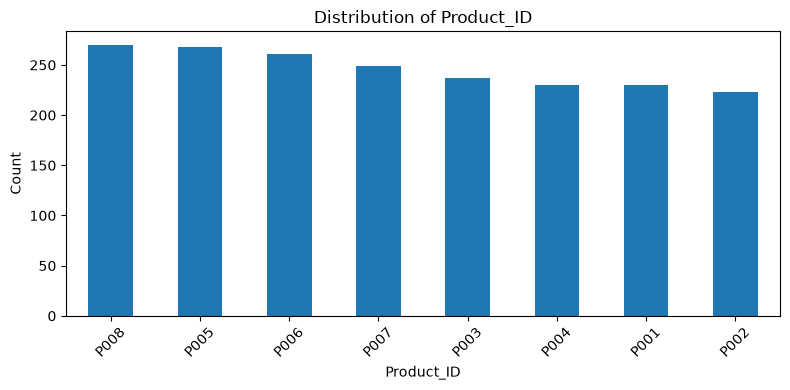

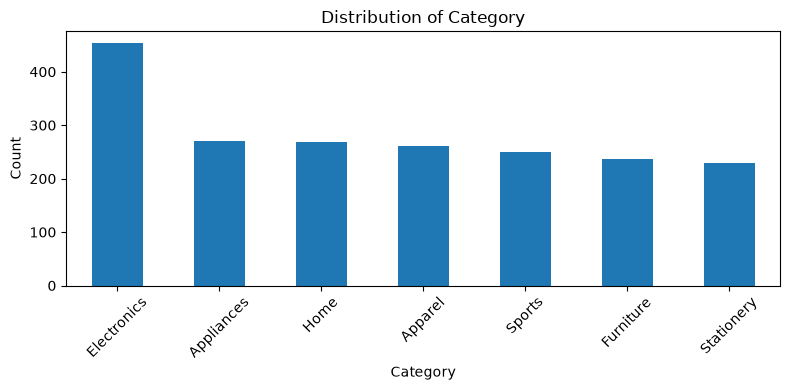

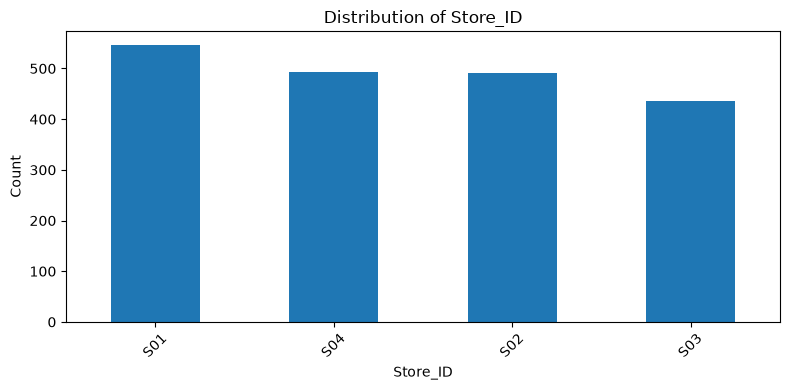

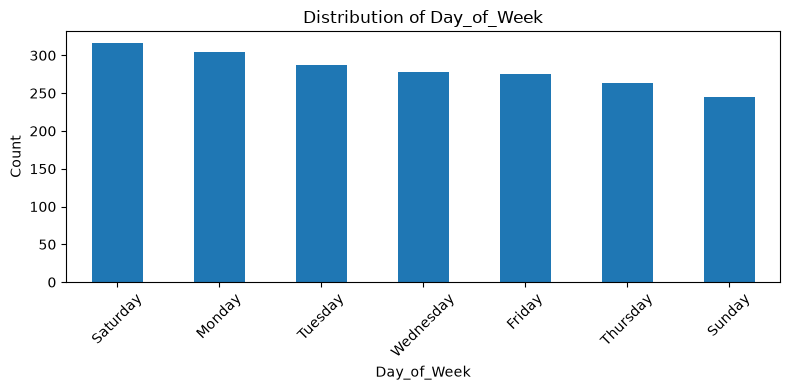

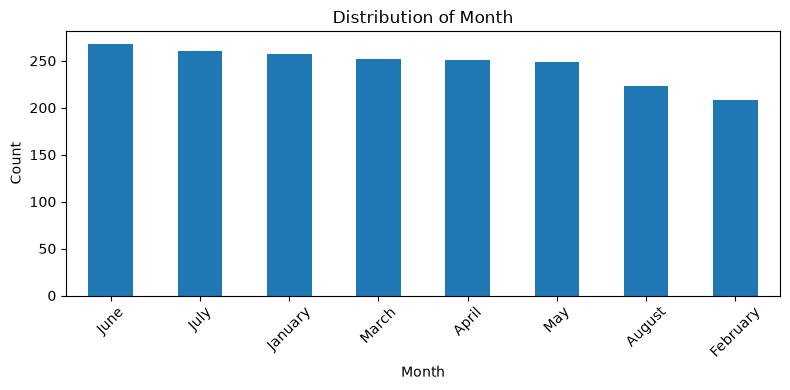

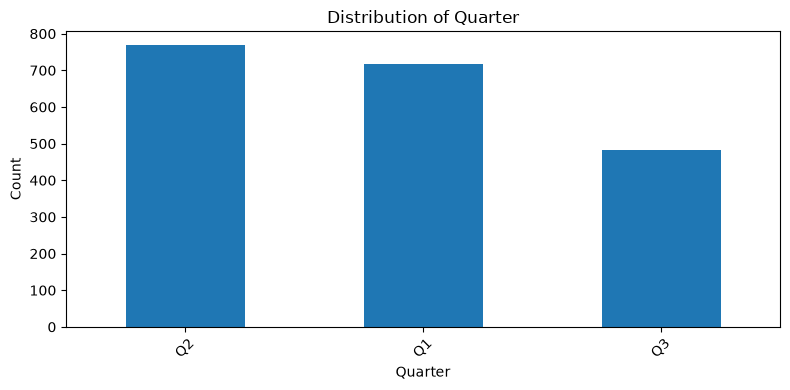

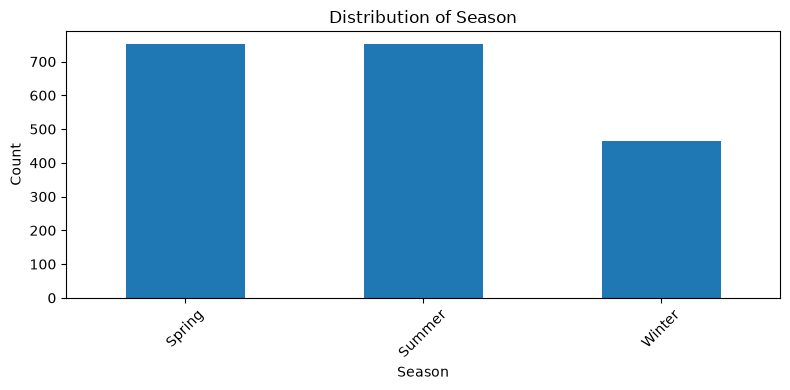

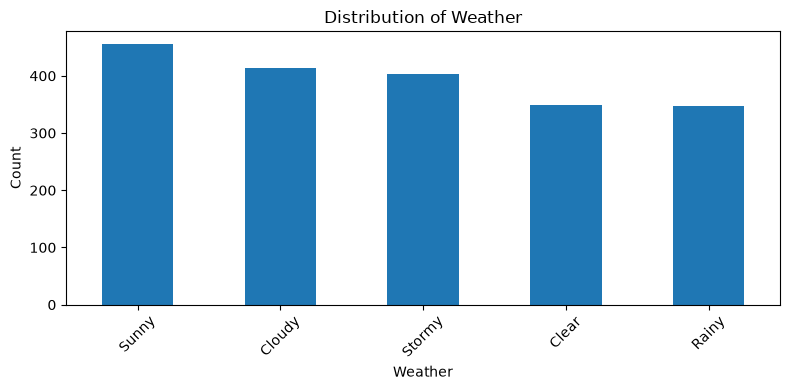

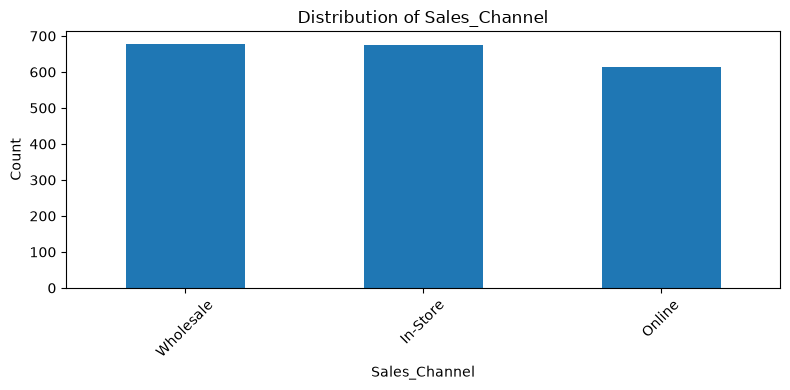

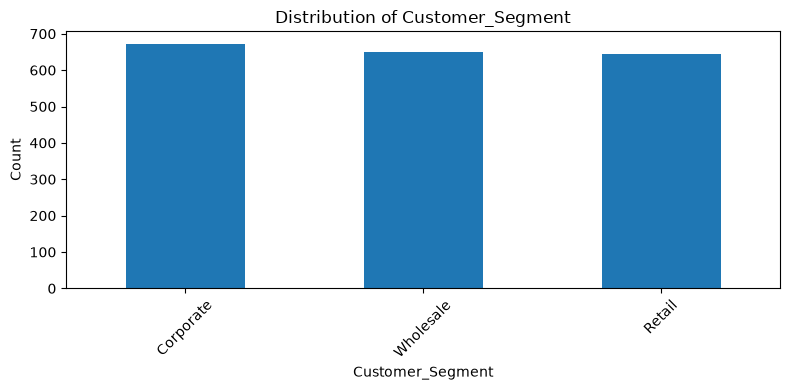

In [242]:
    # ============================================================
# 6. CATEGORICAL VARIABLE VISUALIZATION
# ============================================================
categorical_columns = [
    "Product_ID",
    "Category",
    "Store_ID",
    "Day_of_Week",
    "Month",
    "Quarter",
    "Season",
    "Weather",
    "Sales_Channel",
    "Customer_Segment"
]

for col in categorical_columns:

    plt.figure(figsize=(8, 4))

    df[col].value_counts().plot(kind="bar")

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


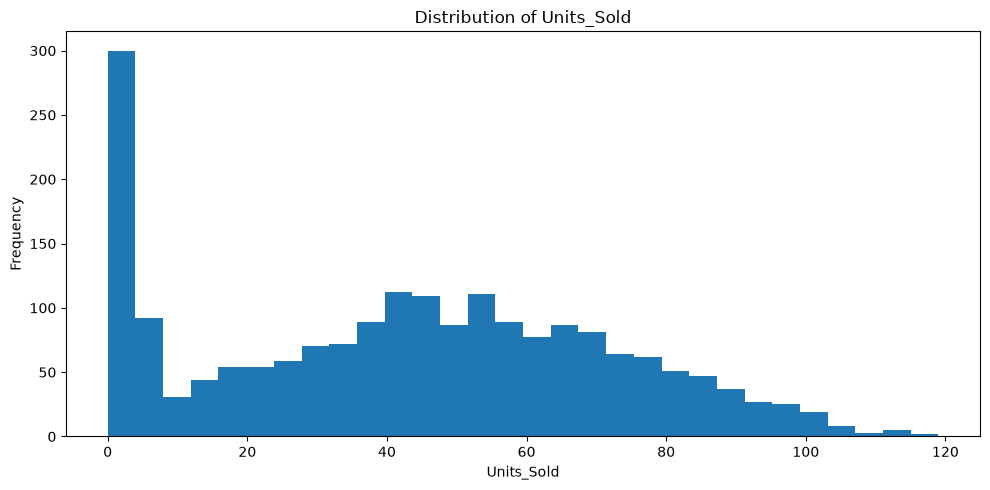

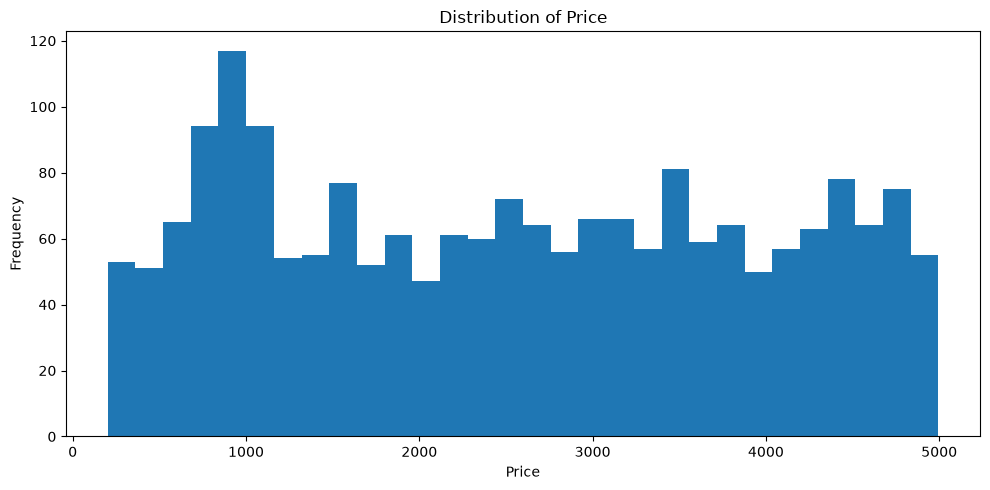

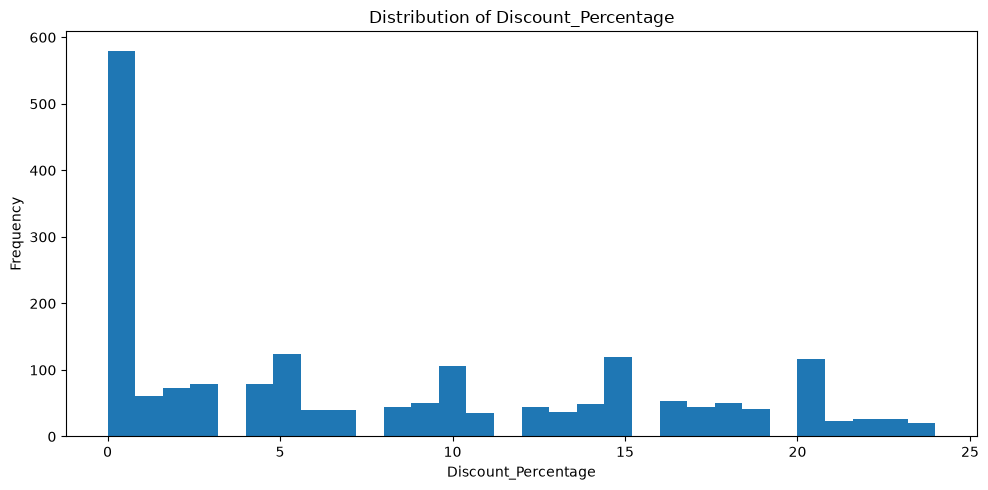

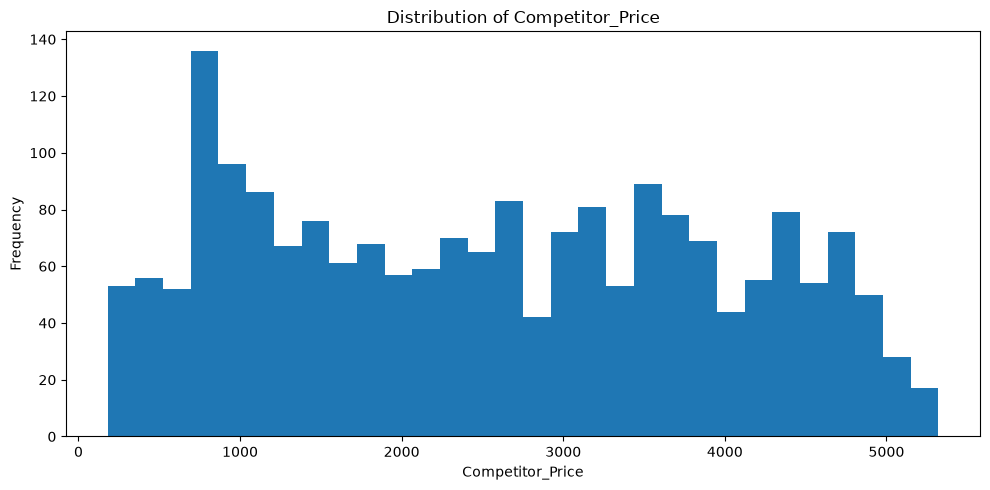

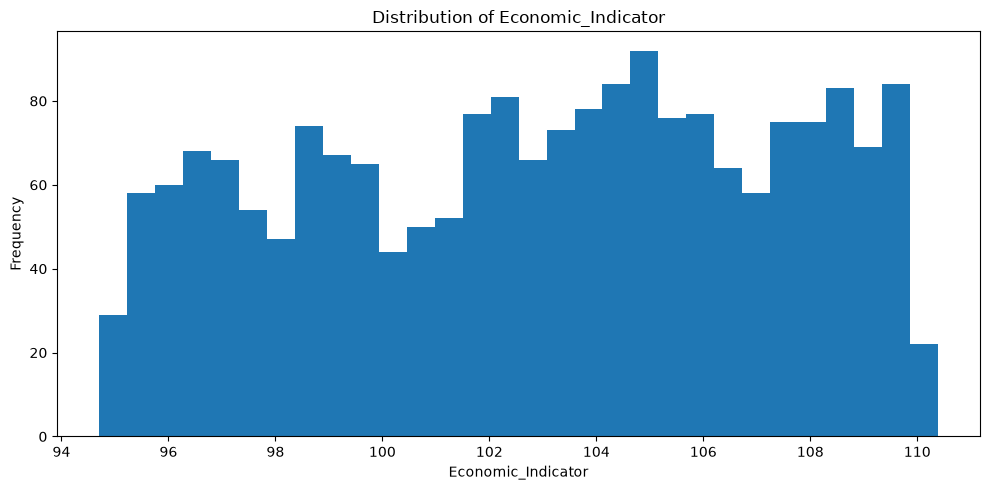

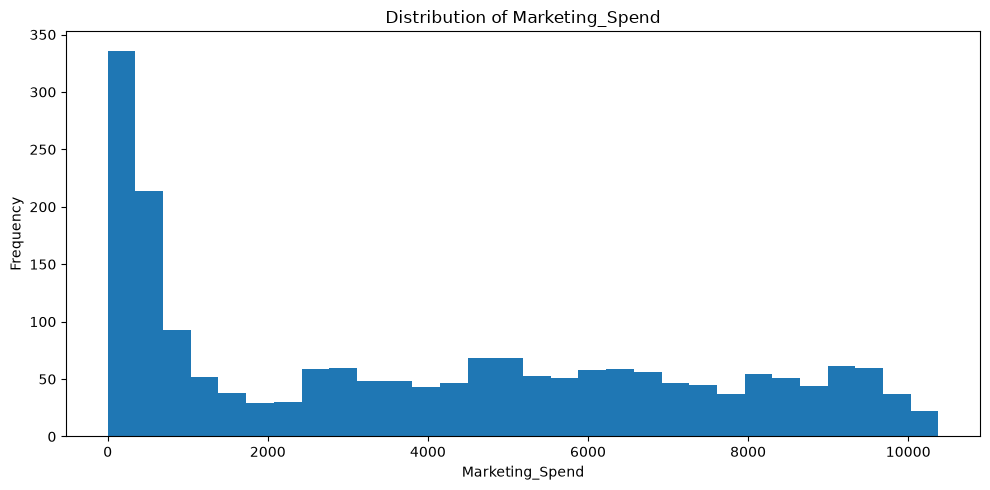

In [243]:
    # ============================================================
# 7. NUMERICAL VARIABLE DISTRIBUTIONS
# ============================================================

numerical_columns = [
    "Units_Sold",
    "Price",
    "Discount_Percentage",
    "Competitor_Price",
    "Economic_Indicator",
    "Marketing_Spend"
]

for col in numerical_columns:

    plt.figure(figsize=(10, 5))

    plt.hist(df[col], bins=30)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

In [244]:

# SKEWNESS
# ============================================================

print("\n========== SKEWNESS ==========")

skewness = df[numerical_columns].skew()

print(skewness)



========== SKEWNESS ==========
Units_Sold             0.101088
Price                  0.069298
Discount_Percentage    0.493601
Competitor_Price       0.106412
Economic_Indicator    -0.139783
Marketing_Spend        0.307895
dtype: float64


In [245]:

# KURTOSIS
# ============================================================

print("\n========== KURTOSIS ==========")

kurtosis = df[numerical_columns].kurt()

print(kurtosis)


========== KURTOSIS ==========
Units_Sold            -0.938604
Price                 -1.266331
Discount_Percentage   -1.155156
Competitor_Price      -1.222428
Economic_Indicator    -1.140434
Marketing_Spend       -1.289247
dtype: float64


               sum       mean  count
Category                            
Electronics  18510  40.860927    453
Home         11925  44.496269    268
Appliances   11883  44.011111    270
Apparel      11055  42.356322    261
Sports       10929  43.891566    249
Furniture     9980  42.109705    237
Stationery    9726  42.286957    230


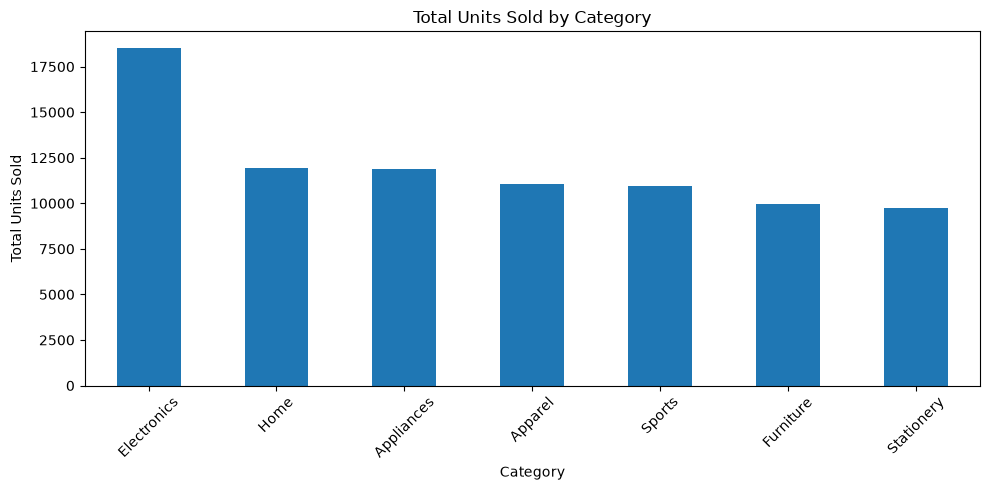

In [246]:
# 8. SALES BY CATEGORY
# ============================================================

category_sales = (
    df.groupby("Category")["Units_Sold"]
      .agg(["sum", "mean", "count"])
      .sort_values("sum", ascending=False)
)
print(category_sales)

plt.figure(figsize=(10, 5))

category_sales["sum"].plot(kind="bar")

plt.title("Total Units Sold by Category")
plt.xlabel("Category")
plt.ylabel("Total Units Sold")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

            sum       mean  count
Store_ID                         
S01       23479  43.001832    546
S04       22041  44.617409    494
S02       20685  42.042683    492
S03       17803  40.832569    436


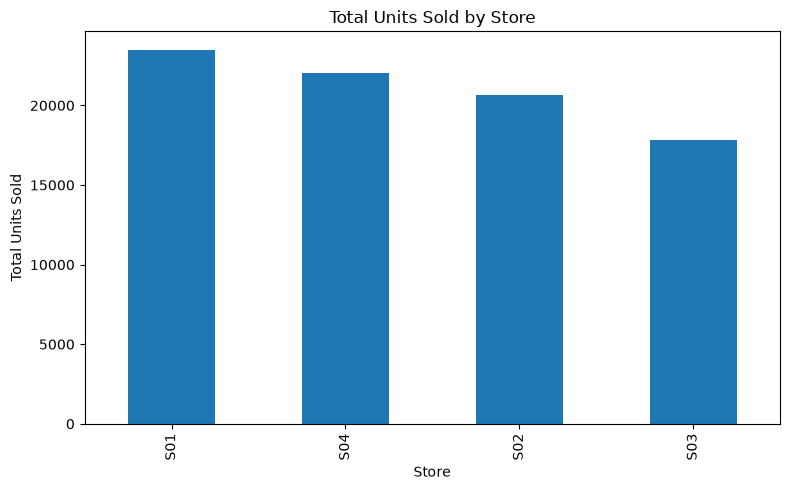

In [247]:
# ============================================================
# 9. SALES BY STORE
# ============================================================

store_sales = (
    df.groupby("Store_ID")["Units_Sold"]
      .agg(["sum", "mean", "count"])
      .sort_values("sum", ascending=False)
)

print(store_sales)

plt.figure(figsize=(8, 5))

store_sales["sum"].plot(kind="bar")

plt.title("Total Units Sold by Store")
plt.xlabel("Store")
plt.ylabel("Total Units Sold")

plt.tight_layout()
plt.show()



In [248]:

# ============================================================
# 10. SALES BY PRODUCT
# ============================================================

product_sales = (
    df.groupby("Product_ID")["Units_Sold"]
      .agg(["sum", "mean", "count"])
      .sort_values("sum", ascending=False)
)

print(product_sales)

print("\nTop 5 Products:")
print(product_sales.head(5))

              sum       mean  count
Product_ID                         
P005        11925  44.496269    268
P008        11883  44.011111    270
P006        11055  42.356322    261
P007        10929  43.891566    249
P003         9980  42.109705    237
P001         9949  43.256522    230
P004         9726  42.286957    230
P002         8561  38.390135    223

Top 5 Products:
              sum       mean  count
Product_ID                         
P005        11925  44.496269    268
P008        11883  44.011111    270
P006        11055  42.356322    261
P007        10929  43.891566    249
P003         9980  42.109705    237


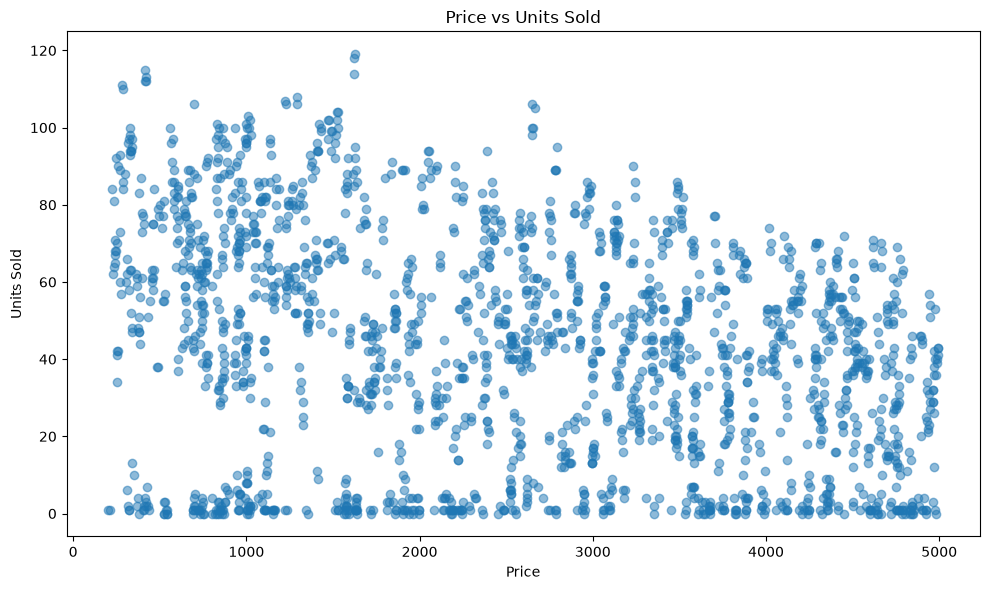

Price vs Units Sold Correlation: -0.29090600300359376


In [249]:
# ============================================================
# 11. PRICE VS UNITS SOLD
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Price"],
    df["Units_Sold"],
    alpha=0.5
)

plt.title("Price vs Units Sold")
plt.xlabel("Price")
plt.ylabel("Units Sold")

plt.tight_layout()
plt.show()

print(
    "Price vs Units Sold Correlation:",
    df["Price"].corr(df["Units_Sold"])
)

Discount_Percentage
0     28.268966
1     33.491803
2     31.205479
3     29.949367
4     32.607595
5     42.298387
6     47.600000
7     51.600000
8     40.136364
9     53.196078
10    47.330189
11    47.600000
12    61.800000
13    45.729730
14    53.183673
15    56.283333
16    54.830189
17    65.577778
18    57.137255
19    54.380952
20    63.612069
21    64.333333
22    58.074074
23    52.888889
24    58.350000
Name: Units_Sold, dtype: float64


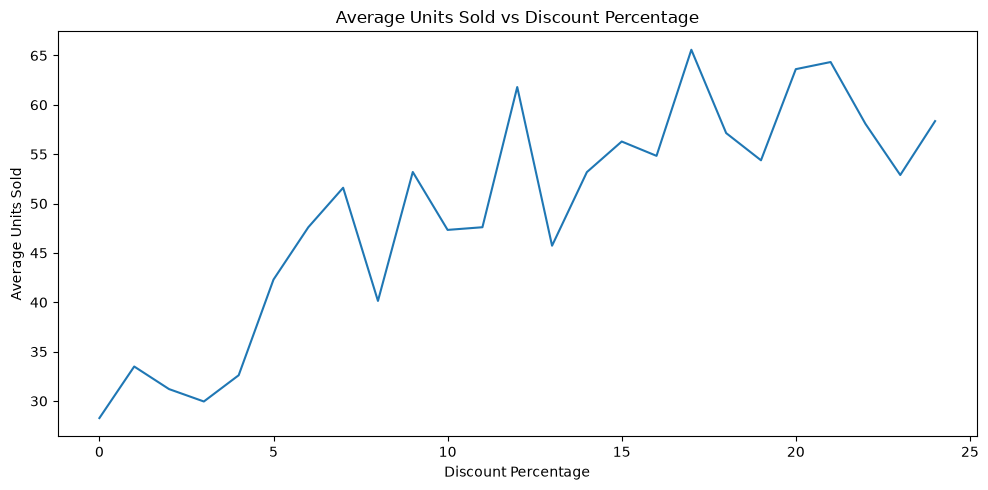

In [250]:
# ============================================================
# 12. DISCOUNT VS UNITS SOLD
# ============================================================

discount_sales = (
    df.groupby("Discount_Percentage")["Units_Sold"]
      .mean()
)

print(discount_sales)

plt.figure(figsize=(10, 5))

discount_sales.plot()

plt.title("Average Units Sold vs Discount Percentage")
plt.xlabel("Discount Percentage")
plt.ylabel("Average Units Sold")

plt.tight_layout()
plt.show()


In [251]:
# ============================================================
# 13. PROMOTION VS SALES
# ============================================================

promotion_sales = (
    df.groupby("Promotion_Flag")["Units_Sold"]
      .agg(["mean", "sum", "count"])
)

print(promotion_sales)

                     mean    sum  count
Promotion_Flag                         
0               25.458554  14435    567
1               49.659529  69573   1401


In [252]:
# ============================================================
# 14. STOCK AVAILABILITY VS SALES
# ============================================================

stock_sales = (
    df.groupby("Stock_Availability")["Units_Sold"]
      .agg(["mean", "sum", "count"])
)

print(stock_sales)


                         mean    sum  count
Stock_Availability                         
0                    3.766990   1552    412
1                   52.992288  82456   1556


In [253]:
# ============================================================
# 15. CORRELATION ANALYSIS
# ============================================================

numerical_columns = [
    "Units_Sold",
    "Price",
    "Discount_Percentage",
    "Promotion_Flag",
    "Stock_Availability",
    "Holiday_Flag",
    "Local_Event_Flag",
    "Competitor_Price",
    "Economic_Indicator",
    "Marketing_Spend"
]

correlation_matrix = df[numerical_columns].corr()
print(correlation_matrix)

                     Units_Sold     Price  Discount_Percentage  \
Units_Sold             1.000000 -0.290906             0.423308   
Price                 -0.290906  1.000000             0.085531   
Discount_Percentage    0.423308  0.085531             1.000000   
Promotion_Flag         0.378047  0.078494             0.600759   
Stock_Availability     0.690787  0.043375             0.049084   
Holiday_Flag          -0.002575 -0.004057            -0.018587   
Local_Event_Flag       0.150343  0.032325             0.043269   
Competitor_Price      -0.292896  0.993215             0.086432   
Economic_Indicator    -0.012031 -0.018536            -0.025521   
Marketing_Spend        0.277235  0.035919             0.416239   

                     Promotion_Flag  Stock_Availability  Holiday_Flag  \
Units_Sold                 0.378047            0.690787     -0.002575   
Price                      0.078494            0.043375     -0.004057   
Discount_Percentage        0.600759            0.04908

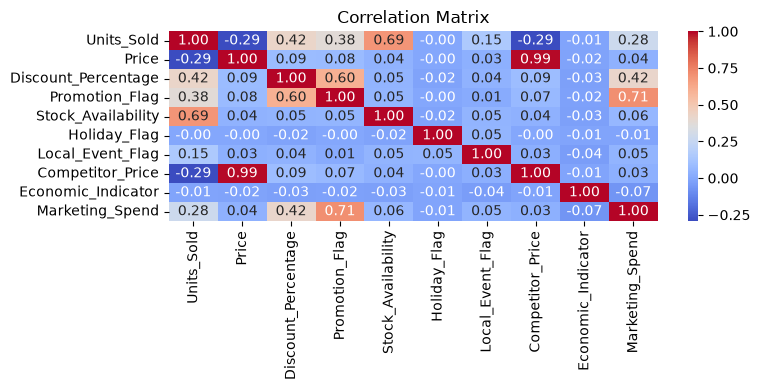

In [254]:
plt.figure(figsize=(8, 4))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

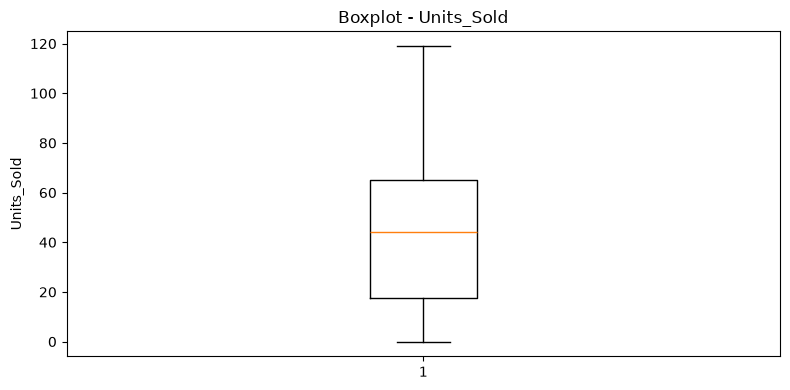

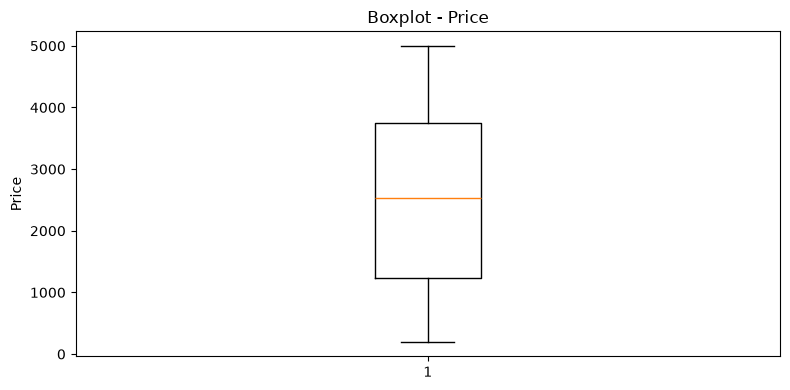

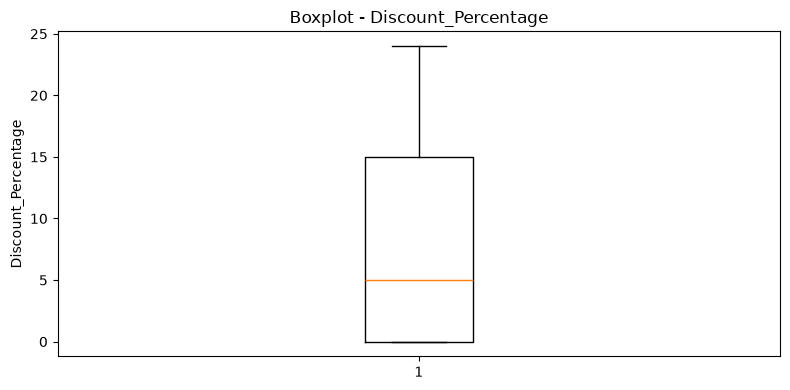

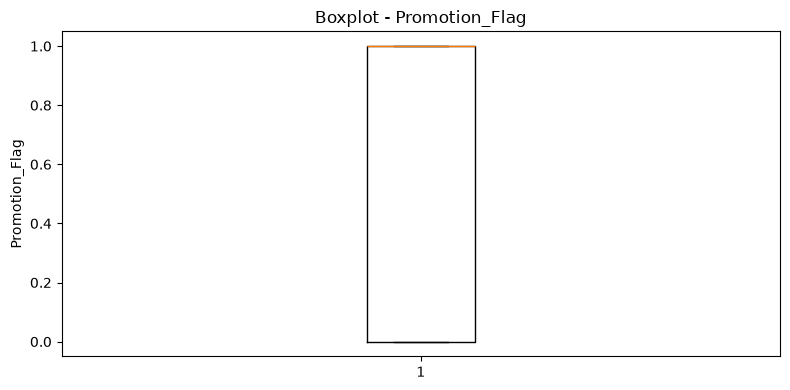

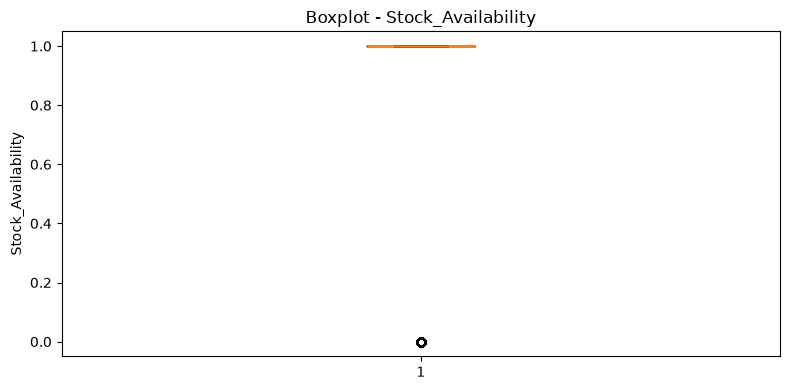

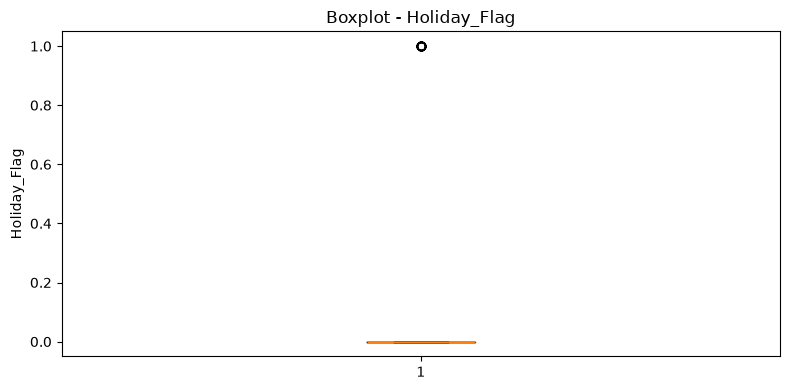

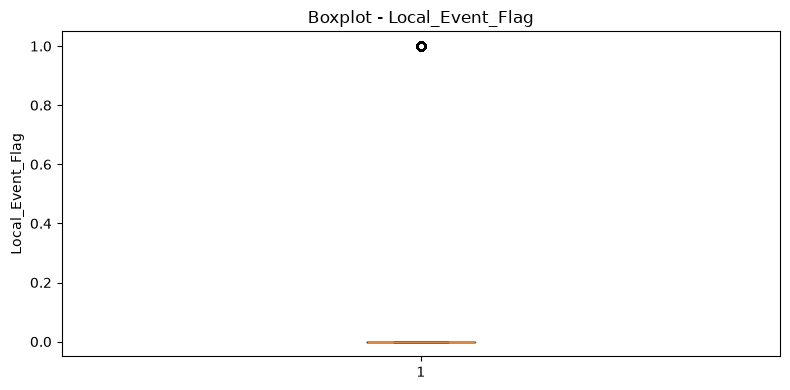

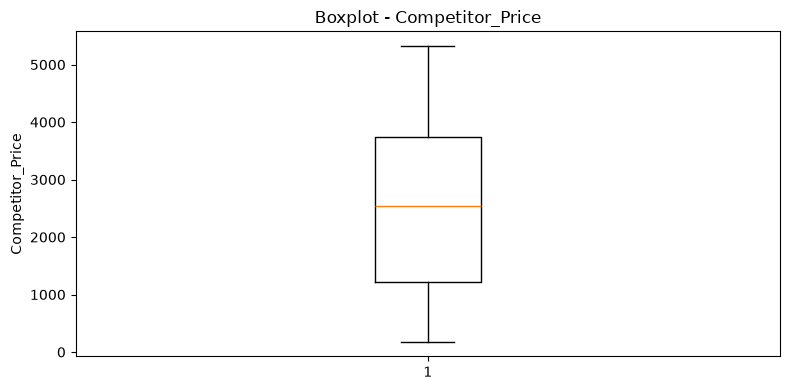

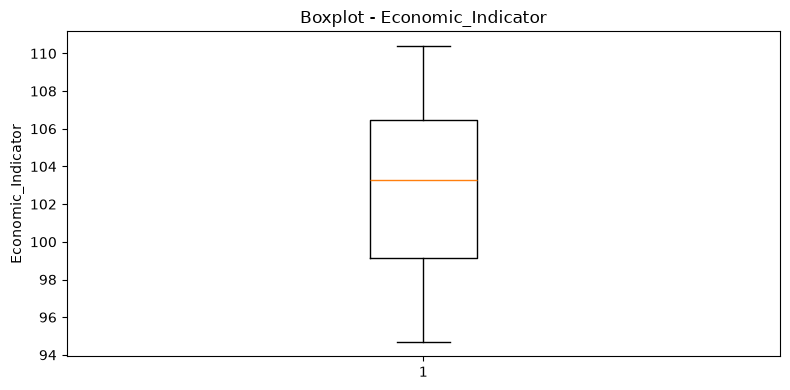

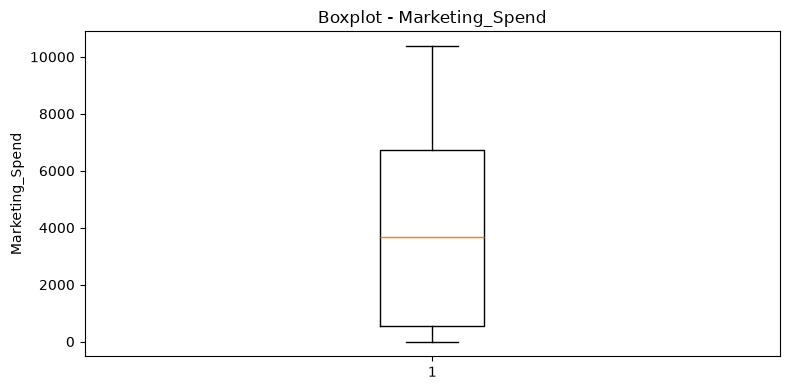

In [255]:
# ============================================================
# OUTLIER ANALYSIS
# ============================================================

for col in numerical_columns:

    plt.figure(figsize=(8, 4))

    plt.boxplot(df[col].dropna())

    plt.title(f"Boxplot - {col}")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()


========== CORRELATION MATRIX ==========
                     Units_Sold     Price  Discount_Percentage  \
Units_Sold             1.000000 -0.290906             0.423308   
Price                 -0.290906  1.000000             0.085531   
Discount_Percentage    0.423308  0.085531             1.000000   
Promotion_Flag         0.378047  0.078494             0.600759   
Stock_Availability     0.690787  0.043375             0.049084   
Holiday_Flag          -0.002575 -0.004057            -0.018587   
Local_Event_Flag       0.150343  0.032325             0.043269   
Competitor_Price      -0.292896  0.993215             0.086432   
Economic_Indicator    -0.012031 -0.018536            -0.025521   
Marketing_Spend        0.277235  0.035919             0.416239   

                     Promotion_Flag  Stock_Availability  Holiday_Flag  \
Units_Sold                 0.378047            0.690787     -0.002575   
Price                      0.078494            0.043375     -0.004057   
Discount_Per

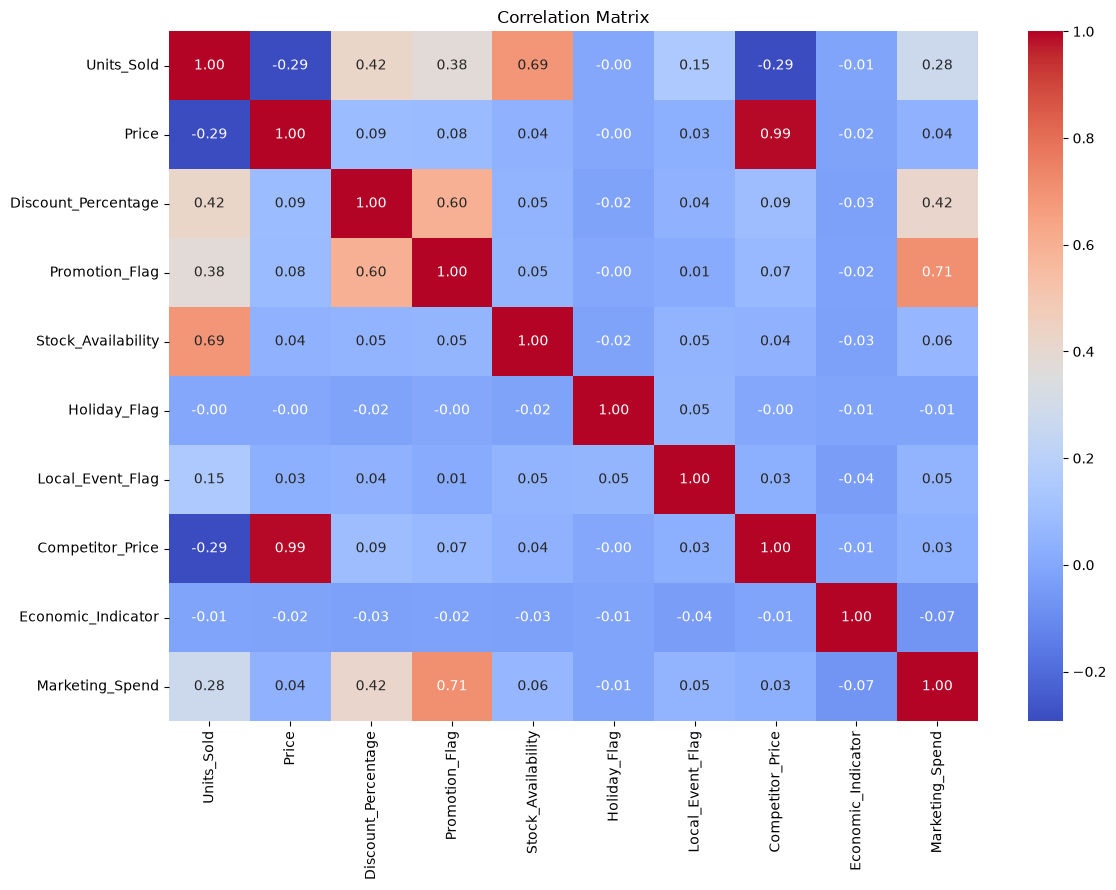

In [256]:
    # ============================================================
# CORRELATION ANALYSIS
# ============================================================

correlation_matrix = df[numerical_columns].corr()

print("\n========== CORRELATION MATRIX ==========")
print(correlation_matrix)

import seaborn as sns

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()


In [257]:

#Business EDA
category_sales = (
    df.groupby("Category")["Units_Sold"]
      .agg(["sum", "mean", "count"])
      .sort_values("sum", ascending=False)
)
print("category_sales:")
print(category_sales)

store_sales = (
    df.groupby("Store_ID")["Units_Sold"]
      .agg(["sum", "mean", "count"])
      .sort_values("sum", ascending=False)
)

print("Store stoles: \n")
print(store_sales)

category_sales:
               sum       mean  count
Category                            
Electronics  18510  40.860927    453
Home         11925  44.496269    268
Appliances   11883  44.011111    270
Apparel      11055  42.356322    261
Sports       10929  43.891566    249
Furniture     9980  42.109705    237
Stationery    9726  42.286957    230
Store stoles: 

            sum       mean  count
Store_ID                         
S01       23479  43.001832    546
S04       22041  44.617409    494
S02       20685  42.042683    492
S03       17803  40.832569    436


In [258]:
product_sales = (
    df.groupby("Product_ID")["Units_Sold"]
      .agg(["sum", "mean", "count"])
      .sort_values("sum", ascending=False)
)

print("product sales:")
print(product_sales)

product sales:
              sum       mean  count
Product_ID                         
P005        11925  44.496269    268
P008        11883  44.011111    270
P006        11055  42.356322    261
P007        10929  43.891566    249
P003         9980  42.109705    237
P001         9949  43.256522    230
P004         9726  42.286957    230
P002         8561  38.390135    223


In [259]:
# ============================================================
# NUMERICAL EDA
# ============================================================

numerical_columns = [
    "Units_Sold",
    "Price",
    "Discount_Percentage",
    "Promotion_Flag",
    "Stock_Availability",
    "Holiday_Flag",
    "Local_Event_Flag",
    "Competitor_Price",
    "Economic_Indicator",
    "Marketing_Spend"
]

print("\n========== NUMERICAL SUMMARY ==========")

print(df[numerical_columns].describe())


========== NUMERICAL SUMMARY ==========
        Units_Sold        Price  Discount_Percentage  Promotion_Flag  \
count  1968.000000  1968.000000          1968.000000     1968.000000   
mean     42.686992  2548.380040             7.881606        0.711890   
std      28.999002  1398.667031             7.539404        0.452998   
min       0.000000   201.882929             0.000000        0.000000   
25%      17.750000  1229.665158             0.000000        0.000000   
50%      44.000000  2539.103785             5.000000        1.000000   
75%      65.000000  3750.603058            15.000000        1.000000   
max     119.000000  4995.614847            24.000000        1.000000   

       Stock_Availability  Holiday_Flag  Local_Event_Flag  Competitor_Price  \
count         1968.000000   1968.000000       1968.000000       1968.000000   
mean             0.790650      0.015752          0.216972       2552.679185   
std              0.406948      0.124546          0.412288       1413.1998

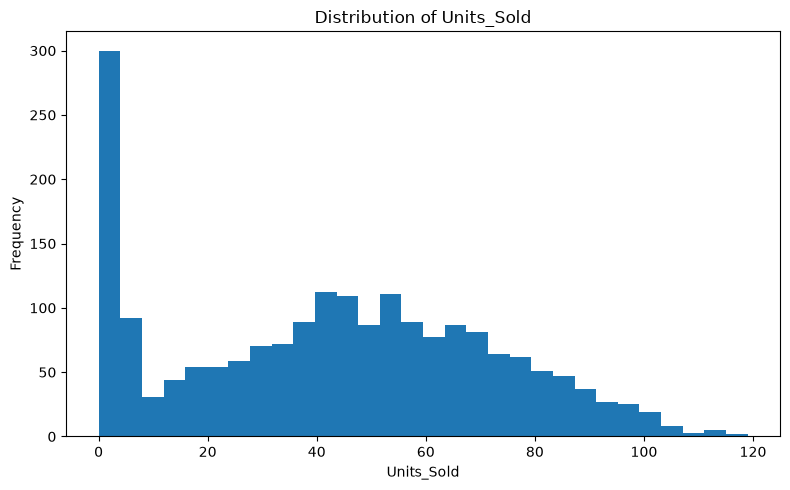

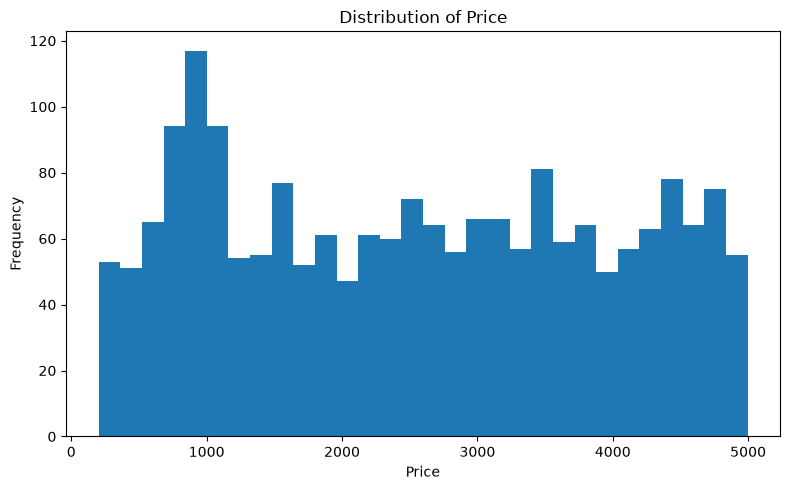

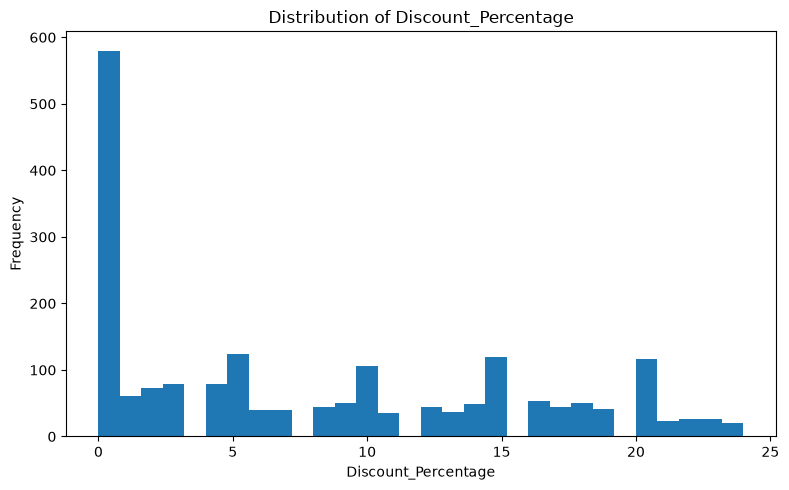

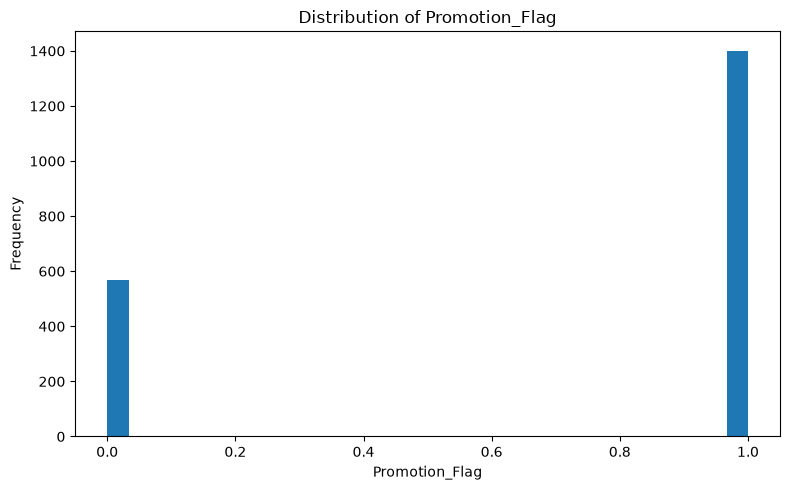

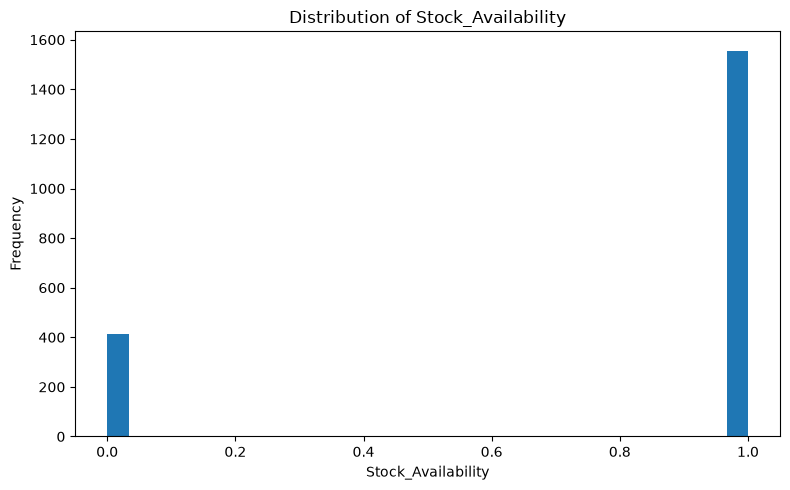

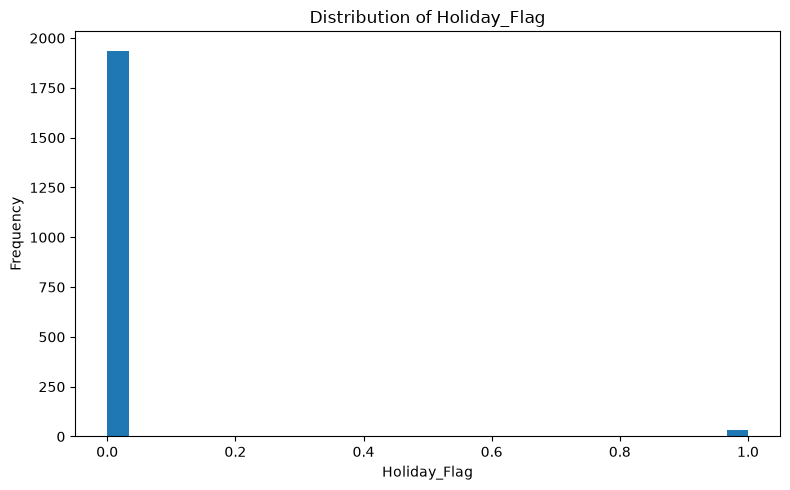

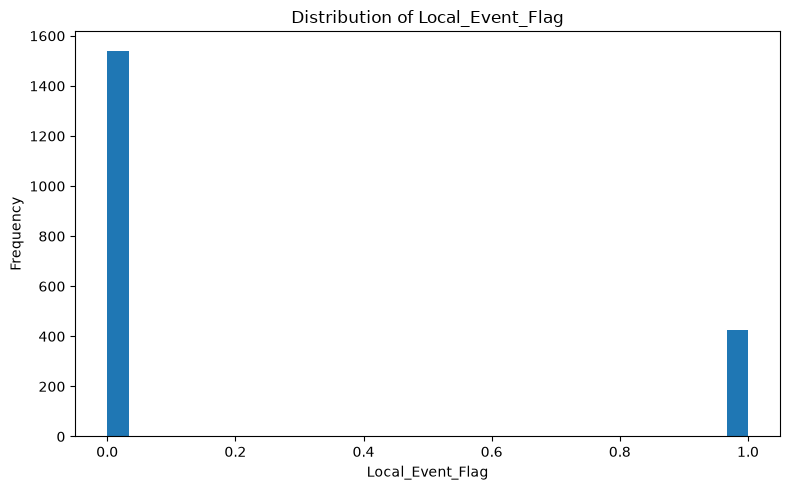

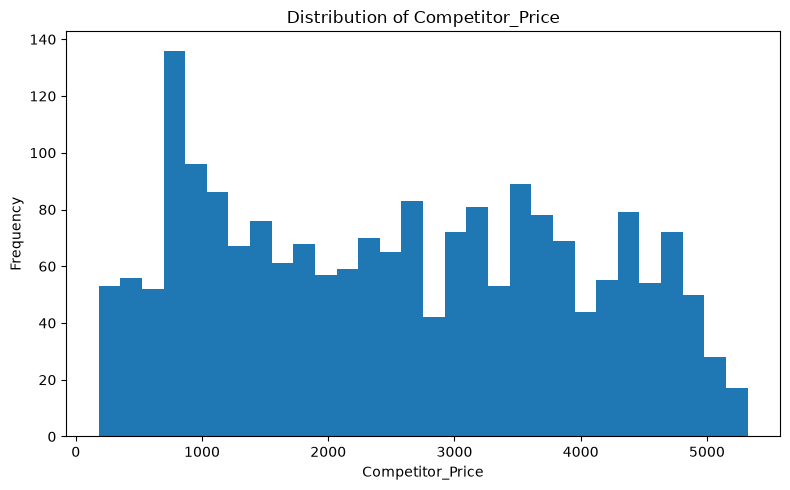

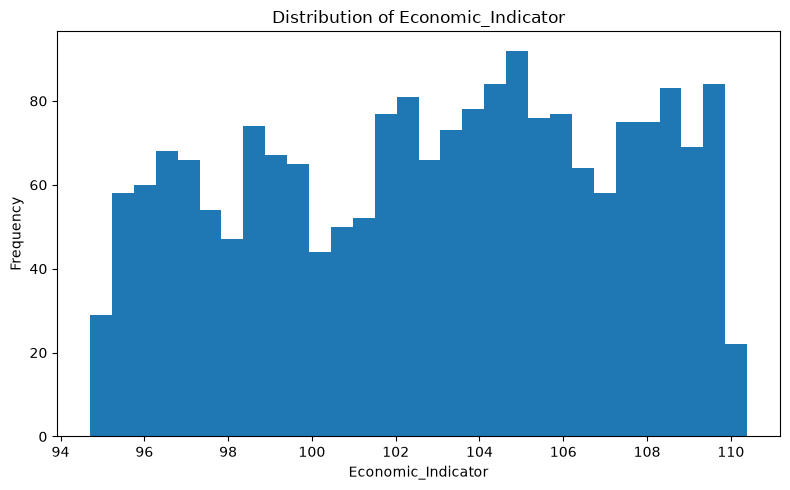

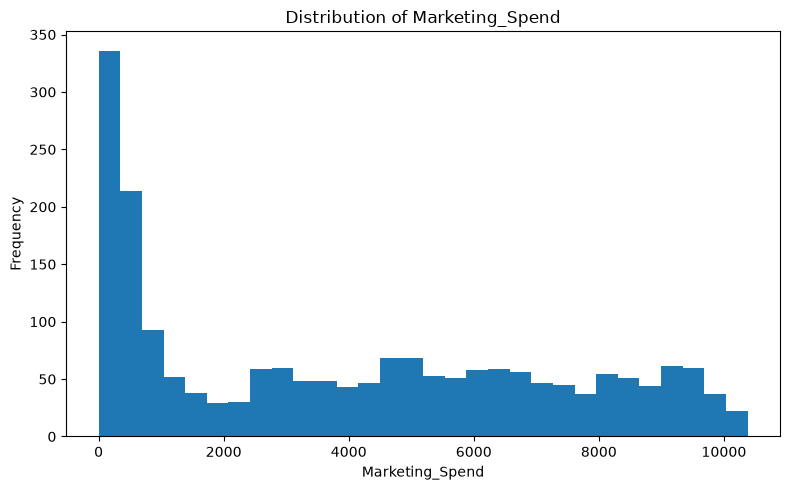

In [260]:
# ============================================================
# NUMERICAL DISTRIBUTION PLOTS
# ============================================================

import matplotlib.pyplot as plt

for col in numerical_columns:

    plt.figure(figsize=(8, 5))

    plt.hist(df[col], bins=30)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()

In [261]:
# ============================================================
# OUTLIER COUNT USING IQR METHOD
# ============================================================

numerical_columns = [
    "Units_Sold",
    "Price",
    "Discount_Percentage",
    "Promotion_Flag",
    "Stock_Availability",
    "Holiday_Flag",
    "Local_Event_Flag",
    "Competitor_Price",
    "Economic_Indicator",
    "Marketing_Spend"
]

outlier_summary = []

for col in numerical_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_summary.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": len(outliers),
        "Outlier_Percentage": (len(outliers) / len(df)) * 100
    })

outlier_df = pd.DataFrame(outlier_summary)

print("\n========== OUTLIER SUMMARY ==========")
print(outlier_df)



========== OUTLIER SUMMARY ==========
                Column           Q1           Q3          IQR  Lower_Bound  \
0           Units_Sold    17.750000    65.000000    47.250000   -53.125000   
1                Price  1229.665158  3750.603058  2520.937900 -2551.741691   
2  Discount_Percentage     0.000000    15.000000    15.000000   -22.500000   
3       Promotion_Flag     0.000000     1.000000     1.000000    -1.500000   
4   Stock_Availability     1.000000     1.000000     0.000000     1.000000   
5         Holiday_Flag     0.000000     0.000000     0.000000     0.000000   
6     Local_Event_Flag     0.000000     0.000000     0.000000     0.000000   
7     Competitor_Price  1224.519677  3741.907849  2517.388171 -2551.562580   
8   Economic_Indicator    99.163158   106.490000     7.326842    88.172894   
9      Marketing_Spend   554.663821  6730.796223  6176.132402 -8709.534782   

    Upper_Bound  Outlier_Count  Outlier_Percentage  
0    135.875000              0            0.00000

In [262]:
# ============================================================
# OUTLIER ANALYSIS & TREATMENT
# ============================================================

print("\n========== OUTLIER ANALYSIS ==========")

# Columns where outlier analysis is meaningful
outlier_columns = [
    "Units_Sold",
    "Price",
    "Discount_Percentage",
    "Competitor_Price",
    "Stock_Availability"
]

for col in outlier_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / len(df)) * 100

    print(f"\nColumn: {col}")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Lower Bound: {lower_bound:.2f}")
    print(f"Upper Bound: {upper_bound:.2f}")
    print(f"Outlier Count: {outlier_count}")
    print(f"Outlier Percentage: {outlier_percentage:.2f}%")



========== OUTLIER ANALYSIS ==========

Column: Units_Sold
Q1: 17.75
Q3: 65.00
IQR: 47.25
Lower Bound: -53.12
Upper Bound: 135.88
Outlier Count: 0
Outlier Percentage: 0.00%

Column: Price
Q1: 1229.67
Q3: 3750.60
IQR: 2520.94
Lower Bound: -2551.74
Upper Bound: 7532.01
Outlier Count: 0
Outlier Percentage: 0.00%

Column: Discount_Percentage
Q1: 0.00
Q3: 15.00
IQR: 15.00
Lower Bound: -22.50
Upper Bound: 37.50
Outlier Count: 0
Outlier Percentage: 0.00%

Column: Competitor_Price
Q1: 1224.52
Q3: 3741.91
IQR: 2517.39
Lower Bound: -2551.56
Upper Bound: 7517.99
Outlier Count: 0
Outlier Percentage: 0.00%

Column: Stock_Availability
Q1: 1.00
Q3: 1.00
IQR: 0.00
Lower Bound: 1.00
Upper Bound: 1.00
Outlier Count: 412
Outlier Percentage: 20.93%


In [263]:
    # ============================================================
# OUTLIER TREATMENT DECISION
# ============================================================

print("""
Outliers were detected using the IQR method.

For sales forecasting, extreme values may represent genuine
business events such as promotions, holidays, seasonal demand,
or high-performing products.

Therefore, outliers will NOT be removed or capped automatically.

Only confirmed data errors will be treated.
""")




Outliers were detected using the IQR method.

For sales forecasting, extreme values may represent genuine
business events such as promotions, holidays, seasonal demand,
or high-performing products.

Therefore, outliers will NOT be removed or capped automatically.

Only confirmed data errors will be treated.



In [264]:
# ============================================================
# CORRELATION ANALYSIS
# ============================================================

numerical_columns = [
    "Units_Sold",
    "Price",
    "Discount_Percentage",
    "Promotion_Flag",
    "Stock_Availability",
    "Holiday_Flag",
    "Local_Event_Flag",
    "Competitor_Price",
    "Economic_Indicator",
    "Marketing_Spend"
]

correlation_matrix = df[numerical_columns].corr()

print("\n========== CORRELATION MATRIX ==========")
print(correlation_matrix["Units_Sold"].sort_values(ascending=False))


========== CORRELATION MATRIX ==========
Units_Sold             1.000000
Stock_Availability     0.690787
Discount_Percentage    0.423308
Promotion_Flag         0.378047
Marketing_Spend        0.277235
Local_Event_Flag       0.150343
Holiday_Flag          -0.002575
Economic_Indicator    -0.012031
Price                 -0.290906
Competitor_Price      -0.292896
Name: Units_Sold, dtype: float64


In [265]:
#1. Category analysis
# ============================================================
# BUSINESS EDA - CATEGORY
# ============================================================

category_analysis = (
    df.groupby("Category")["Units_Sold"]
      .agg(
          Total_Sales="sum",
          Average_Sales="mean",
          Number_of_Records="count"
      )
      .sort_values("Total_Sales", ascending=False)
)

print("\n========== CATEGORY ANALYSIS ==========")
print(category_analysis)


========== CATEGORY ANALYSIS ==========
             Total_Sales  Average_Sales  Number_of_Records
Category                                                  
Electronics        18510      40.860927                453
Home               11925      44.496269                268
Appliances         11883      44.011111                270
Apparel            11055      42.356322                261
Sports             10929      43.891566                249
Furniture           9980      42.109705                237
Stationery          9726      42.286957                230


In [266]:
# ============================================================
# BUSINESS EDA - STORE
# ============================================================

store_analysis = (
    df.groupby("Store_ID")["Units_Sold"]
      .agg(
          Total_Sales="sum",
          Average_Sales="mean",
          Number_of_Records="count"
      )
      .sort_values("Total_Sales", ascending=False)
)

print("\n========== STORE ANALYSIS ==========")
print(store_analysis)


========== STORE ANALYSIS ==========
          Total_Sales  Average_Sales  Number_of_Records
Store_ID                                               
S01             23479      43.001832                546
S04             22041      44.617409                494
S02             20685      42.042683                492
S03             17803      40.832569                436


In [267]:
# ============================================================
# BUSINESS EDA - PRODUCT
# ============================================================

product_analysis = (
    df.groupby("Product_ID")["Units_Sold"]
      .agg(
          Total_Sales="sum",
          Average_Sales="mean",
          Number_of_Records="count"
      )
      .sort_values("Total_Sales", ascending=False)
)

print("\n========== PRODUCT ANALYSIS ==========")
print(product_analysis)



========== PRODUCT ANALYSIS ==========
            Total_Sales  Average_Sales  Number_of_Records
Product_ID                                               
P005              11925      44.496269                268
P008              11883      44.011111                270
P006              11055      42.356322                261
P007              10929      43.891566                249
P003               9980      42.109705                237
P001               9949      43.256522                230
P004               9726      42.286957                230
P002               8561      38.390135                223


In [268]:
# ============================================================
# BUSINESS EDA - PROMOTION
# ============================================================

promotion_analysis = (
    df.groupby("Promotion_Flag")["Units_Sold"]
      .agg(
          Total_Sales="sum",
          Average_Sales="mean",
          Number_of_Records="count"
      )
)

print("\n========== PROMOTION ANALYSIS ==========")
print(promotion_analysis)


========== PROMOTION ANALYSIS ==========
                Total_Sales  Average_Sales  Number_of_Records
Promotion_Flag                                               
0                     14435      25.458554                567
1                     69573      49.659529               1401


In [269]:
# ============================================================
# BUSINESS EDA - STOCK
# ============================================================

stock_analysis = (
    df.groupby("Stock_Availability")["Units_Sold"]
      .agg(
          Total_Sales="sum",
          Average_Sales="mean",
          Number_of_Records="count"
      )
)

print("\n========== STOCK ANALYSIS ==========")
print(stock_analysis)


========== STOCK ANALYSIS ==========
                    Total_Sales  Average_Sales  Number_of_Records
Stock_Availability                                               
0                          1552       3.766990                412
1                         82456      52.992288               1556


In [270]:
# ============================================================
# BUSINESS EDA - SALES CHANNEL
# ============================================================

channel_analysis = (
    df.groupby("Sales_Channel")["Units_Sold"]
      .agg(
          Total_Sales="sum",
          Average_Sales="mean",
          Number_of_Records="count"
      )
      .sort_values("Total_Sales", ascending=False)
)

print("\n========== SALES CHANNEL ANALYSIS ==========")
print(channel_analysis)


========== SALES CHANNEL ANALYSIS ==========
               Total_Sales  Average_Sales  Number_of_Records
Sales_Channel                                               
Wholesale            29991      44.169367                679
In-Store             27093      40.137778                675
Online               26924      43.850163                614


In [271]:
# ============================================================
# BUSINESS EDA - CUSTOMER SEGMENT
# ============================================================

segment_analysis = (
    df.groupby("Customer_Segment")["Units_Sold"]
      .agg(
          Total_Sales="sum",
          Average_Sales="mean",
          Number_of_Records="count"
      )
      .sort_values("Total_Sales", ascending=False)
)

print("\n========== CUSTOMER SEGMENT ANALYSIS ==========")
print(segment_analysis)



========== CUSTOMER SEGMENT ANALYSIS ==========
                  Total_Sales  Average_Sales  Number_of_Records
Customer_Segment                                               
Corporate               29858      44.365527                673
Wholesale               27814      42.790769                650
Retail                  26336      40.831008                645


In [272]:
# ============================================================
# CATEGORICAL vs CATEGORICAL ANALYSIS
# CROSSTAB
# ============================================================

print("\n========== CATEGORY vs STORE ==========")

category_store = pd.crosstab(
    df["Category"],
    df["Store_ID"]
)

print(category_store)
# ============================================================
# CATEGORY vs STORE - PERCENTAGE
# ============================================================

print("\n========== CATEGORY vs STORE (%) ==========")

category_store_percentage = pd.crosstab(
    df["Category"],
    df["Store_ID"],
    normalize="index"
) * 100

print(category_store_percentage.round(2))



========== CATEGORY vs STORE ==========
Store_ID     S01  S02  S03  S04
Category                       
Apparel       67   59   49   86
Appliances    67   65   67   71
Electronics  156  109   86  102
Furniture     95   46   48   48
Home          66   73   56   73
Sports        44   61   75   69
Stationery    51   79   55   45

========== CATEGORY vs STORE (%) ==========
Store_ID       S01    S02    S03    S04
Category                               
Apparel      25.67  22.61  18.77  32.95
Appliances   24.81  24.07  24.81  26.30
Electronics  34.44  24.06  18.98  22.52
Furniture    40.08  19.41  20.25  20.25
Home         24.63  27.24  20.90  27.24
Sports       17.67  24.50  30.12  27.71
Stationery   22.17  34.35  23.91  19.57


In [273]:
# ============================================================
# SALES CHANNEL vs CUSTOMER SEGMENT
# ============================================================

print("\n========== SALES CHANNEL vs CUSTOMER SEGMENT ==========")

channel_customer = pd.crosstab(
    df["Sales_Channel"],
    df["Customer_Segment"]
)

print(channel_customer)


# ============================================================
# SALES CHANNEL vs CUSTOMER SEGMENT - PERCENTAGE
# ============================================================

print("\n========== SALES CHANNEL vs CUSTOMER SEGMENT (%) ==========")

channel_customer_percentage = pd.crosstab(
    df["Sales_Channel"],
    df["Customer_Segment"],
    normalize="index"
) * 100

print(channel_customer_percentage.round(2))


========== SALES CHANNEL vs CUSTOMER SEGMENT ==========
Customer_Segment  Corporate  Retail  Wholesale
Sales_Channel                                 
In-Store                259     173        243
Online                  198     227        189
Wholesale               216     245        218

========== SALES CHANNEL vs CUSTOMER SEGMENT (%) ==========
Customer_Segment  Corporate  Retail  Wholesale
Sales_Channel                                 
In-Store              38.37   25.63      36.00
Online                32.25   36.97      30.78
Wholesale             31.81   36.08      32.11


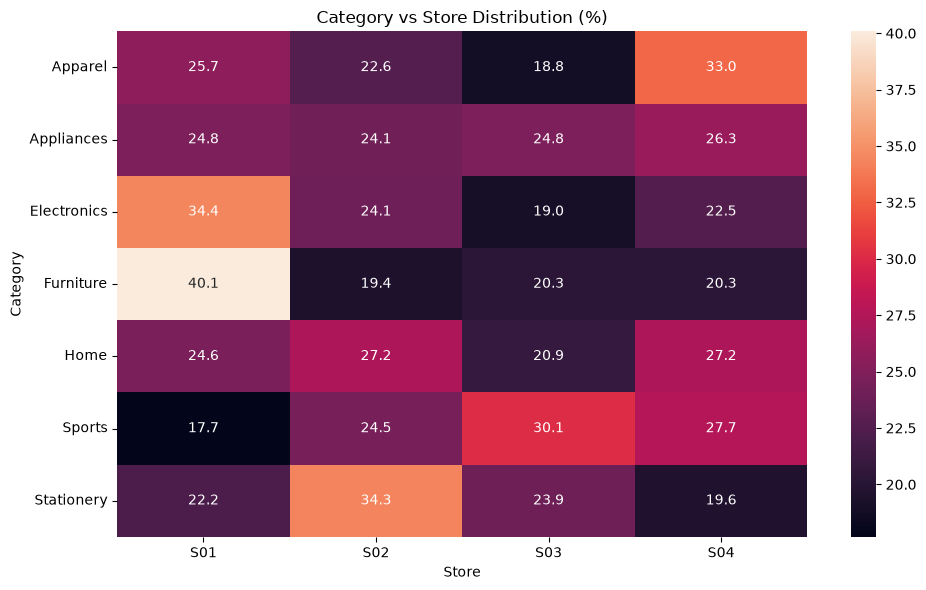

In [274]:
# ============================================================
# CROSSTAB HEATMAP
# ============================================================

plt.figure(figsize=(10, 6))

sns.heatmap(
    category_store_percentage,
    annot=True,
    fmt=".1f"
)

plt.title("Category vs Store Distribution (%)")
plt.xlabel("Store")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [275]:
print("\n========== SALES CHANNEL vs CUSTOMER SEGMENT ==========")

channel_customer = pd.crosstab(
    df["Sales_Channel"],
    df["Customer_Segment"]
)

print(channel_customer)


print("\n========== SALES CHANNEL vs CUSTOMER SEGMENT (%) ==========")

channel_customer_percentage = pd.crosstab(
    df["Sales_Channel"],
    df["Customer_Segment"],
    normalize="index"
).mul(100).round(2)

print(channel_customer_percentage)


========== SALES CHANNEL vs CUSTOMER SEGMENT ==========
Customer_Segment  Corporate  Retail  Wholesale
Sales_Channel                                 
In-Store                259     173        243
Online                  198     227        189
Wholesale               216     245        218

========== SALES CHANNEL vs CUSTOMER SEGMENT (%) ==========
Customer_Segment  Corporate  Retail  Wholesale
Sales_Channel                                 
In-Store              38.37   25.63      36.00
Online                32.25   36.97      30.78
Wholesale             31.81   36.08      32.11


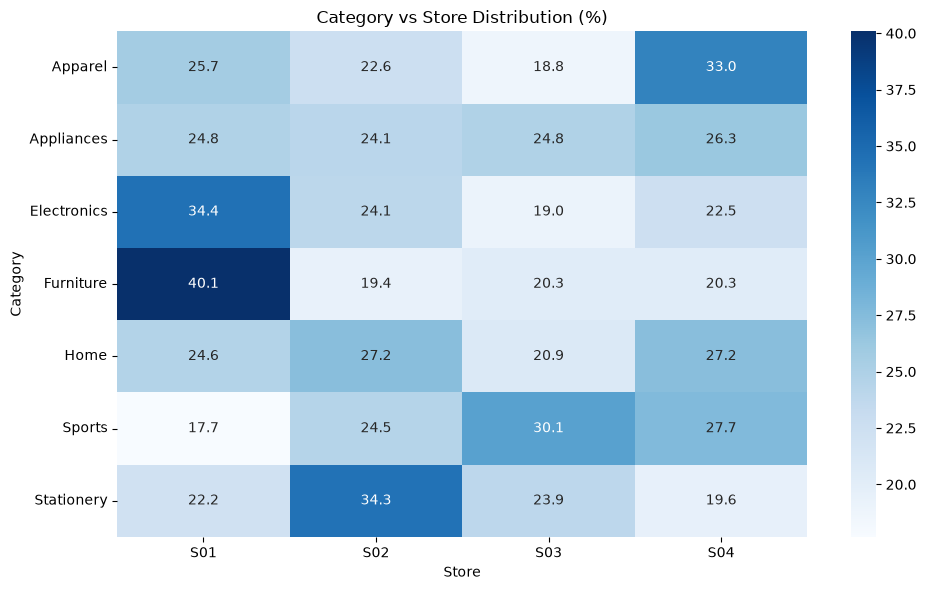

In [276]:

# ============================================================
# CROSSTAB HEATMAP
# ============================================================

plt.figure(figsize=(10, 6))

sns.heatmap(
    category_store_percentage,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Category vs Store Distribution (%)")
plt.xlabel("Store")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

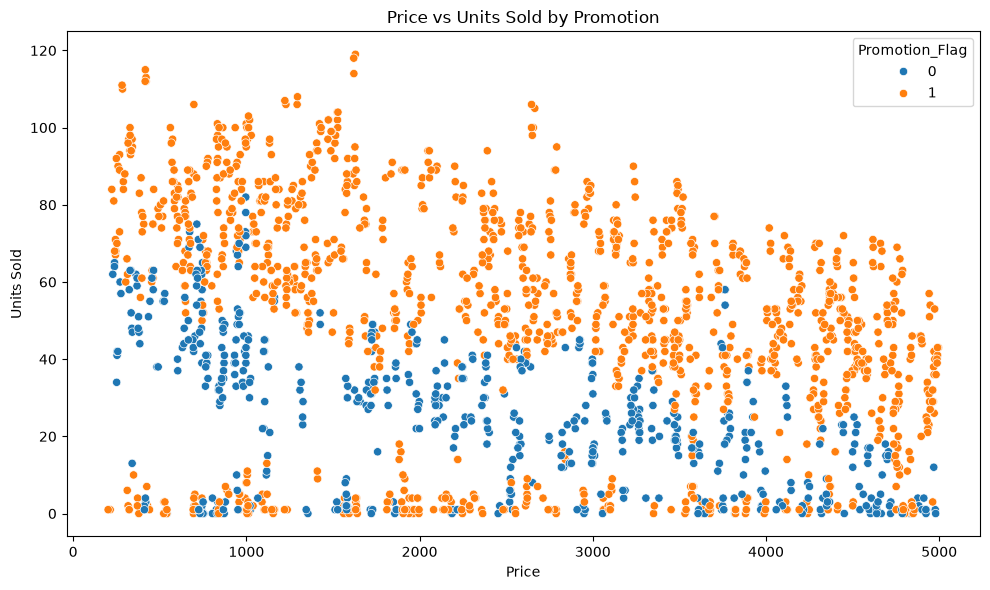

In [277]:
# ============================================================
# MULTIVARIATE EDA
# ============================================================

# 1. Price vs Units Sold by Promotion
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Price",
    y="Units_Sold",
    hue="Promotion_Flag"
)

plt.title("Price vs Units Sold by Promotion")
plt.xlabel("Price")
plt.ylabel("Units Sold")
plt.tight_layout()
plt.show()

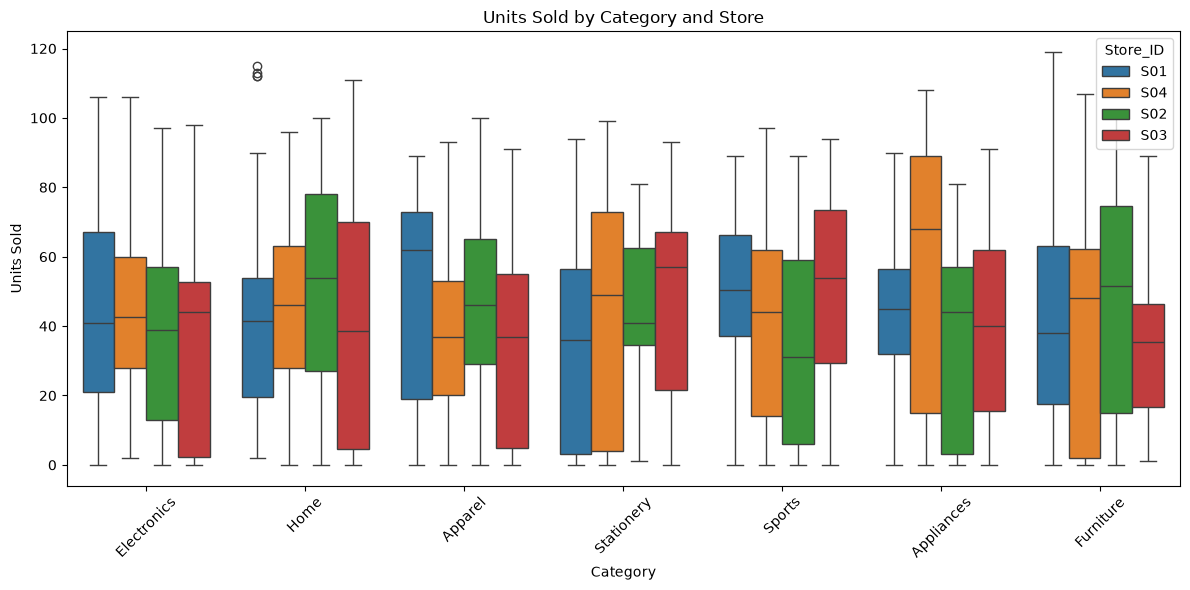

In [278]:
# 2. Category vs Units Sold by Store
# ============================================================

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="Category",
    y="Units_Sold",
    hue="Store_ID"
)

plt.title("Units Sold by Category and Store")
plt.xlabel("Category")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [279]:
# ============================================================
# TIME-SERIES DATA QUALITY CHECK
# ============================================================

print("\n========== VALID DATE DATA ==========")

date_df = df[df["Date"].notna()].copy()

print("Total records:", len(df))
print("Records with valid Date:", len(date_df))
print("Records with missing Date:", df["Date"].isna().sum())

print("\nDate range:")
print(date_df["Date"].min(), "to", date_df["Date"].max())

print("\nNumber of unique dates:",
      date_df["Date"].nunique())

print("\nRecords per date:")
print(date_df["Date"].value_counts().head(20))


========== VALID DATE DATA ==========
Total records: 1968
Records with valid Date: 1968
Records with missing Date: 0

Date range:
2023-01-06 00:00:00 to 2026-08-31 00:00:00

Number of unique dates: 722

Records per date:
Date
2024-06-08    10
2025-02-21    10
2025-03-28    10
2024-07-01     8
2024-07-29     8
2025-01-07     8
2025-02-10     8
2025-04-14     8
2024-04-20     7
2024-05-30     7
2024-06-01     7
2024-06-19     7
2024-06-29     7
2025-01-08     7
2025-04-23     7
2025-04-26     7
2025-05-27     7
2025-07-12     7
2025-07-23     7
2025-08-19     7
Name: count, dtype: int64



========== DAILY SALES ==========
Date
2023-01-06     54
2023-01-13     58
2023-01-28     64
2023-02-09     96
2023-02-13     45
2023-02-14      3
2023-02-16     63
2023-02-22      3
2023-02-27     55
2023-03-02     46
2023-03-07     66
2023-03-17     55
2023-03-18    140
2023-03-23     51
2023-03-24     31
2023-03-26     46
2023-03-27     68
2023-03-28     91
2023-04-02    128
2023-04-03      1
Name: Units_Sold, dtype: int64

Number of days: 722


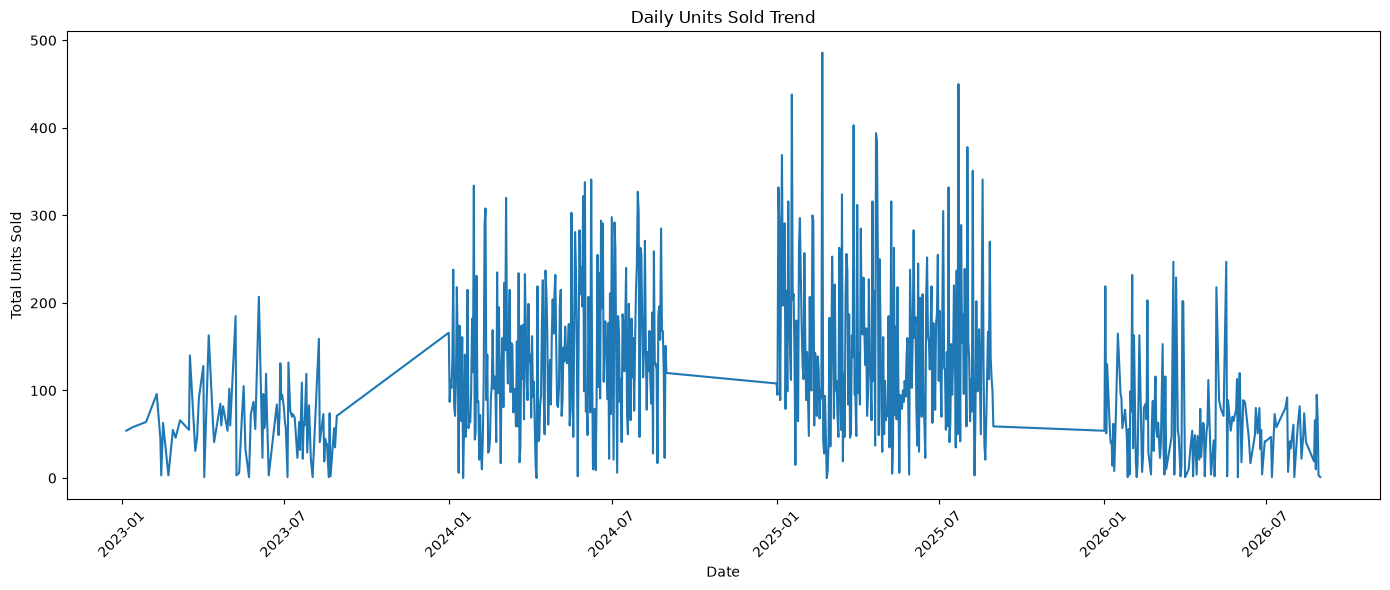

In [280]:
# ============================================================
# DAILY SALES TREND
# ============================================================

daily_sales = (
    date_df.groupby("Date")["Units_Sold"]
           .sum()
           .sort_index()
)

print("\n========== DAILY SALES ==========")
print(daily_sales.head(20))

print("\nNumber of days:", len(daily_sales))

# ============================================================
# DAILY SALES VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    daily_sales.index,
    daily_sales.values
)

plt.title("Daily Units Sold Trend")
plt.xlabel("Date")
plt.ylabel("Total Units Sold")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [281]:
# ============================================================
# TIME-SERIES EDA - YEAR AND MONTH ANALYSIS
# ============================================================

# Use only records having a valid Date
date_df = df[df["Date"].notna()].copy()

# Create Year and Month from the actual Date
date_df["Year"] = date_df["Date"].dt.year
date_df["Month_Num"] = date_df["Date"].dt.month


# ------------------------------------------------------------
# 1. YEARLY SALES
# ------------------------------------------------------------

yearly_sales = (
    date_df.groupby("Year")["Units_Sold"]
           .agg(["sum", "mean", "count"])
           .reset_index()
)

yearly_sales.columns = [
    "Year",
    "Total_Sales",
    "Average_Sales",
    "Number_of_Records"
]

print("\n========== YEARLY SALES ==========")
print(yearly_sales)


========== YEARLY SALES ==========
   Year  Total_Sales  Average_Sales  Number_of_Records
0  2023         5623      45.715447                123
1  2024        33528      44.000000                762
2  2025        35730      42.134434                848
3  2026         9127      38.838298                235


In [282]:
# ------------------------------------------------------------
# 2. MONTHLY SALES
# ------------------------------------------------------------

monthly_sales = (
    date_df.groupby("Month_Num")["Units_Sold"]
           .agg(["sum", "mean", "count"])
           .reset_index()
)

monthly_sales.columns = [
    "Month",
    "Total_Sales",
    "Average_Sales",
    "Number_of_Records"
]

print("\n========== MONTHLY SALES ==========")
print(monthly_sales)



========== MONTHLY SALES ==========
   Month  Total_Sales  Average_Sales  Number_of_Records
0      1        11307      43.996109                257
1      2         8636      41.519231                208
2      3        10878      43.166667                252
3      4        10447      41.621514                251
4      5        10334      41.502008                249
5      6        10909      40.705224                268
6      7        11502      44.238462                260
7      8         9995      44.820628                223


In [283]:

# ------------------------------------------------------------
# 3. YEAR-MONTH SALES
# ------------------------------------------------------------

date_df["Year_Month"] = date_df["Date"].dt.to_period("M")

year_month_sales = (
    date_df.groupby("Year_Month")["Units_Sold"]
           .sum()
           .reset_index()
)

print("\n========== YEAR-MONTH SALES ==========")
print(year_month_sales.head(30))


========== YEAR-MONTH SALES ==========
   Year_Month  Units_Sold
0     2023-01         176
1     2023-02         265
2     2023-03         594
3     2023-04         737
4     2023-05         780
5     2023-06        1164
6     2023-07        1251
7     2023-08         656
8     2024-01        3608
9     2024-02        3142
10    2024-03        4275
11    2024-04        3800
12    2024-05        4849
13    2024-06        4288
14    2024-07        4979
15    2024-08        4587
16    2025-01        5937
17    2025-02        3464
18    2025-03        4363
19    2025-04        5113
20    2025-05        3423
21    2025-06        4538
22    2025-07        4796
23    2025-08        4096
24    2026-01        1586
25    2026-02        1765
26    2026-03        1646
27    2026-04         797
28    2026-05        1282
29    2026-06         919


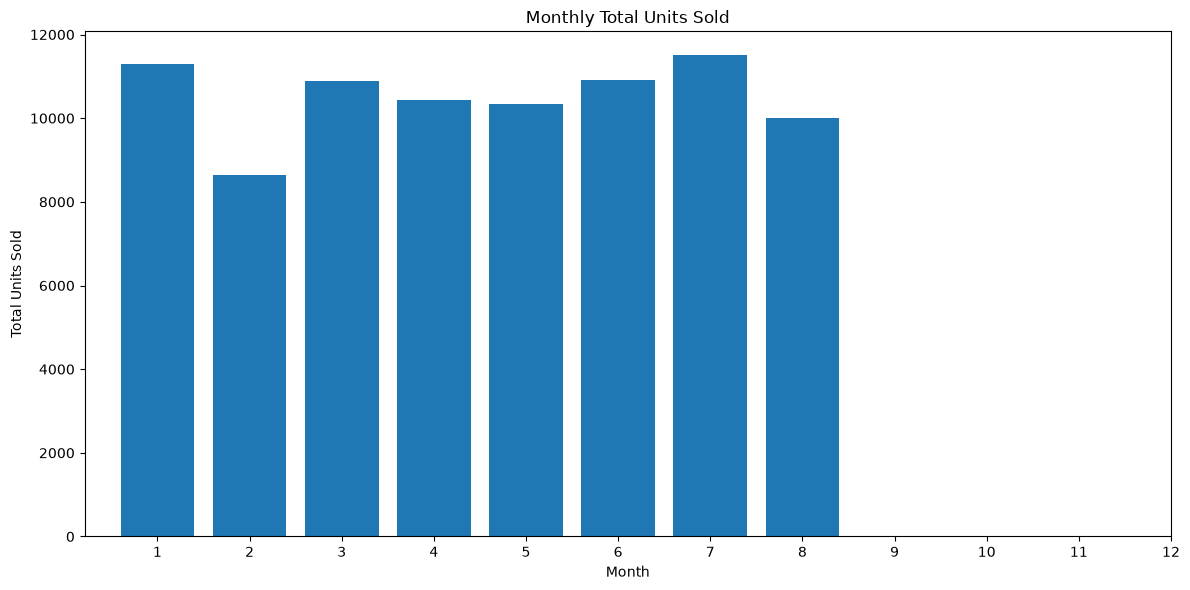

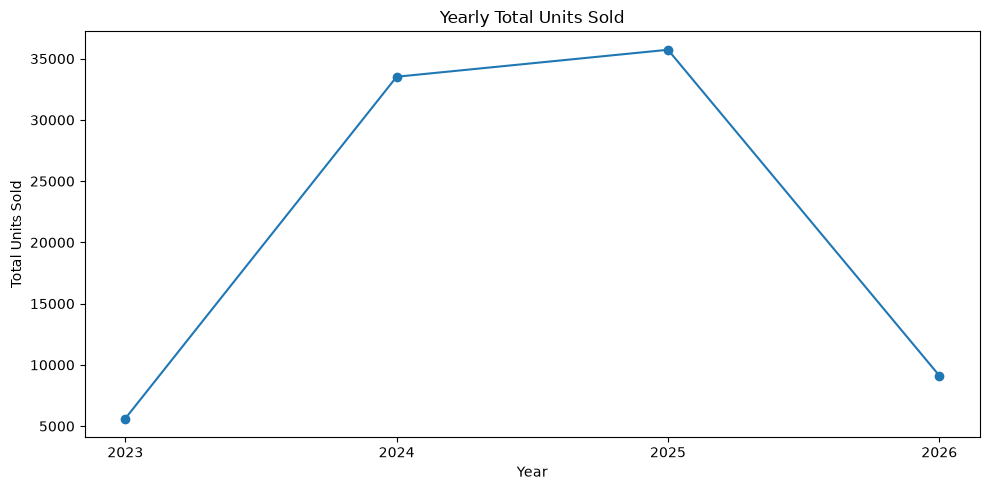

In [284]:
# ============================================================
# MONTHLY SALES TREND
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    monthly_sales["Month"],
    monthly_sales["Total_Sales"]
)

plt.title("Monthly Total Units Sold")
plt.xlabel("Month")
plt.ylabel("Total Units Sold")

plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()



# ============================================================
# YEARLY SALES TREND
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    yearly_sales["Year"],
    yearly_sales["Total_Sales"],
    marker="o"
)

plt.title("Yearly Total Units Sold")
plt.xlabel("Year")
plt.ylabel("Total Units Sold")

plt.xticks(yearly_sales["Year"])

plt.tight_layout()
plt.show()


========== WEEKDAY SALES ==========
     Weekday  Total_Sales  Average_Sales  Number_of_Records
0     Monday        12947      42.588816                304
1    Tuesday        12710      44.285714                287
2  Wednesday        11170      40.179856                278
3   Thursday        10868      41.323194                263
4     Friday        11849      43.087273                275
5   Saturday        14014      44.348101                316
6     Sunday        10450      42.653061                245


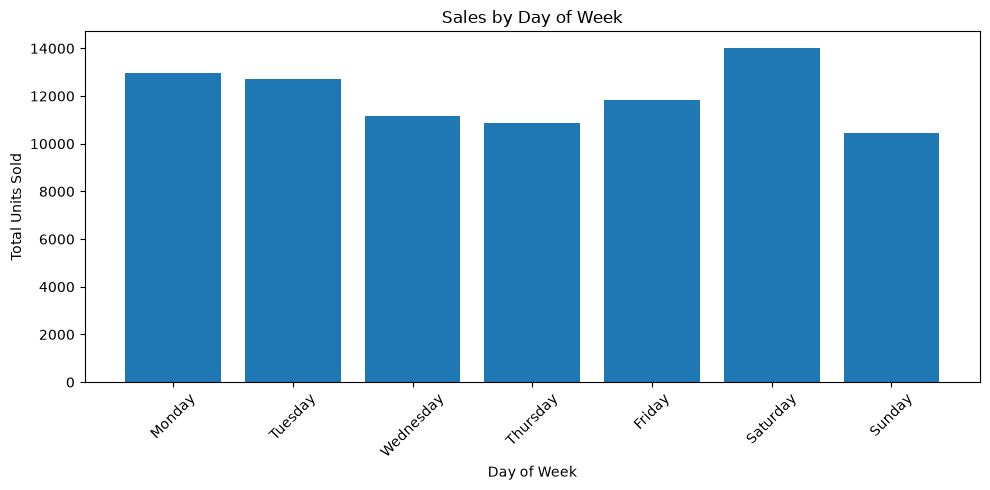

In [285]:
# ============================================================
# WEEKDAY SALES ANALYSIS
# ============================================================

date_df = df[df["Date"].notna()].copy()

# Calculate weekday directly from Date
date_df["Weekday"] = date_df["Date"].dt.day_name()

# Set correct weekday order
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# Group sales by weekday
weekday_sales = (
    date_df.groupby("Weekday")["Units_Sold"]
           .agg(["sum", "mean", "count"])
           .reindex(weekday_order)
           .reset_index()
)

weekday_sales.columns = [
    "Weekday",
    "Total_Sales",
    "Average_Sales",
    "Number_of_Records"
]

print("\n========== WEEKDAY SALES ==========")
print(weekday_sales)

# ============================================================
# WEEKDAY SALES VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    weekday_sales["Weekday"],
    weekday_sales["Total_Sales"]
)

plt.title("Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Total Units Sold")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


========== QUARTERLY SALES ==========
  Quarter  Total_Sales  Average_Sales  Number_of_Records
0      Q1      30821.0      42.986053              717.0
1      Q2      31690.0      41.263021              768.0
2      Q3      21497.0      44.507246              483.0
3      Q4          NaN            NaN                NaN


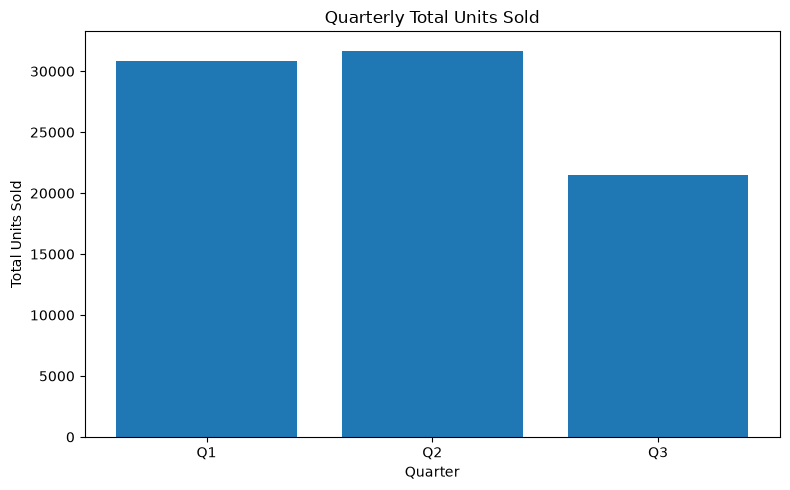

In [286]:
# ============================================================
# QUARTERLY SALES ANALYSIS
# ============================================================

date_df = df[df["Date"].notna()].copy()

# Calculate quarter directly from Date
date_df["Quarter_Correct"] = "Q" + date_df["Date"].dt.quarter.astype(str)

quarter_order = ["Q1", "Q2", "Q3", "Q4"]

quarterly_sales = (
    date_df.groupby("Quarter_Correct")["Units_Sold"]
           .agg(["sum", "mean", "count"])
           .reindex(quarter_order)
           .reset_index()
)

quarterly_sales.columns = [
    "Quarter",
    "Total_Sales",
    "Average_Sales",
    "Number_of_Records"
]

print("\n========== QUARTERLY SALES ==========")
print(quarterly_sales)

# ============================================================
# QUARTERLY SALES VISUALIZATION
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    quarterly_sales["Quarter"],
    quarterly_sales["Total_Sales"]
)

plt.title("Quarterly Total Units Sold")
plt.xlabel("Quarter")
plt.ylabel("Total Units Sold")

plt.tight_layout()
plt.show()


========== SEASON SALES ==========
   Season  Total_Sales  Average_Sales  Number_of_Records
0  Winter      19943.0      42.888172              465.0
1  Spring      31659.0      42.099734              752.0
2  Summer      32406.0      43.150466              751.0
3  Autumn          NaN            NaN                NaN


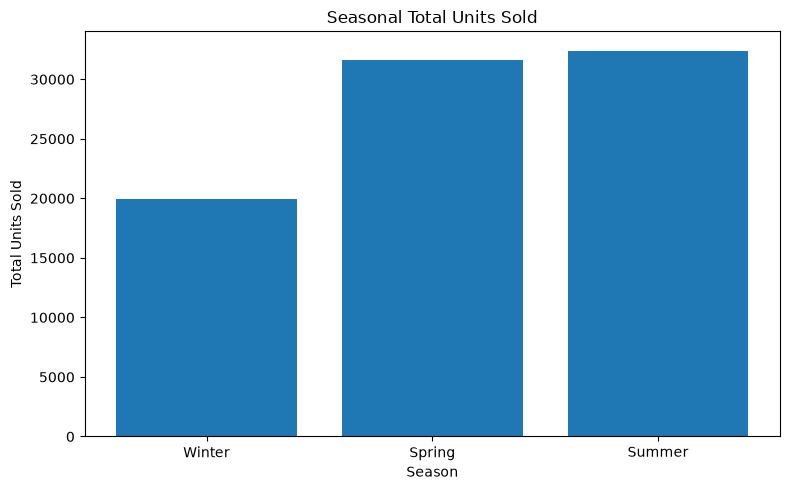

In [287]:
# ============================================================
# SEASON SALES ANALYSIS
# ============================================================

date_df = df[df["Date"].notna()].copy()

# Create season from actual Date
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

date_df["Season_Correct"] = date_df["Date"].dt.month.apply(get_season)

season_order = [
    "Winter",
    "Spring",
    "Summer",
    "Autumn"
]

season_sales = (
    date_df.groupby("Season_Correct")["Units_Sold"]
           .agg(["sum", "mean", "count"])
           .reindex(season_order)
           .reset_index()
)

season_sales.columns = [
    "Season",
    "Total_Sales",
    "Average_Sales",
    "Number_of_Records"
]

print("\n========== SEASON SALES ==========")
print(season_sales)

# ============================================================
# SEASON SALES VISUALIZATION
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    season_sales["Season"],
    season_sales["Total_Sales"]
)

plt.title("Seasonal Total Units Sold")
plt.xlabel("Season")
plt.ylabel("Total Units Sold")

plt.tight_layout()
plt.show()


========== 7-DAY ROLLING AVERAGE ==========
Date
2023-01-06          NaN
2023-01-13          NaN
2023-01-28          NaN
2023-02-09          NaN
2023-02-13          NaN
2023-02-14          NaN
2023-02-16    54.714286
2023-02-22    47.428571
2023-02-27    47.000000
2023-03-02    44.428571
2023-03-07    40.142857
2023-03-17    41.571429
2023-03-18    61.142857
2023-03-23    59.428571
2023-03-24    63.428571
Name: Units_Sold, dtype: float64


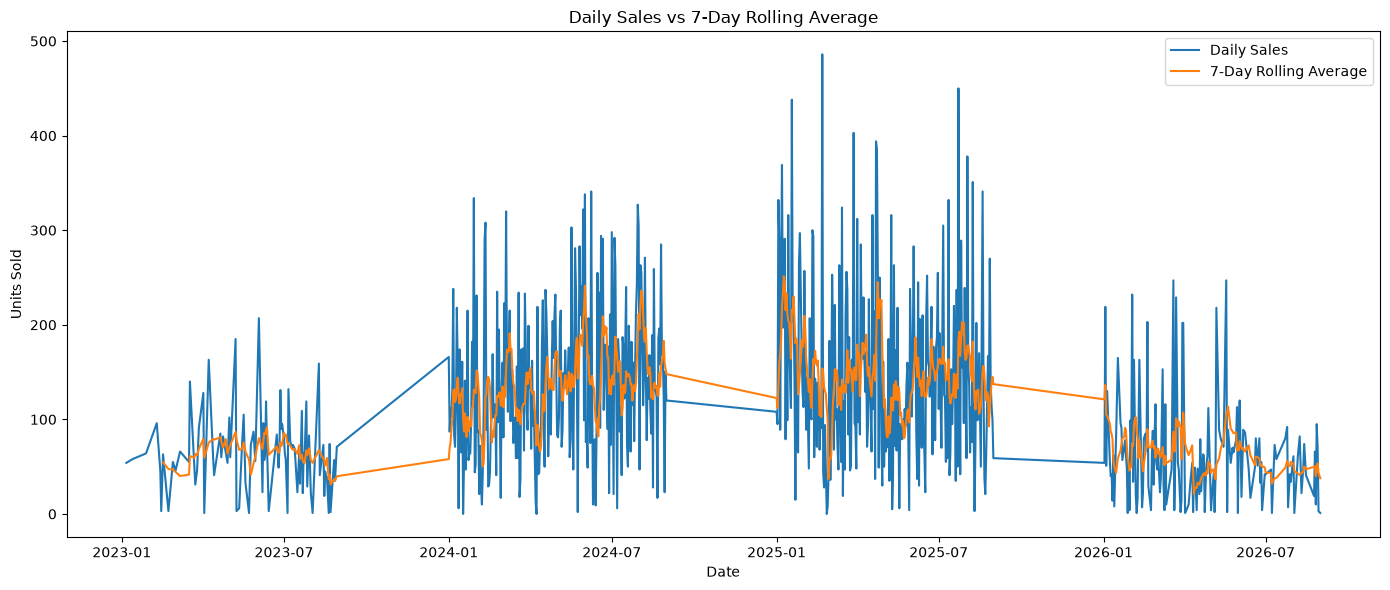

In [288]:
# ============================================================
# ROLLING AVERAGE ANALYSIS
# ============================================================

date_df = df[df["Date"].notna()].copy()

# Aggregate sales by date
daily_sales = (
    date_df.groupby("Date")["Units_Sold"]
           .sum()
           .sort_index()
)

# Create 7-day rolling average
rolling_7 = daily_sales.rolling(window=7).mean()

print("\n========== 7-DAY ROLLING AVERAGE ==========")
print(rolling_7.head(15))
# ============================================================
# DAILY SALES VS 7-DAY ROLLING AVERAGE
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    daily_sales.index,
    daily_sales.values,
    label="Daily Sales"
)

plt.plot(
    rolling_7.index,
    rolling_7.values,
    label="7-Day Rolling Average"
)

plt.title("Daily Sales vs 7-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()

plt.tight_layout()
plt.show()



========== MONTHLY SALES TREND ==========
   Year_Month  Total_Sales  Average_Sales  Number_of_Records
0     2023-01          176      58.666667                  3
1     2023-02          265      44.166667                  6
2     2023-03          594      54.000000                 11
3     2023-04          737      61.416667                 12
4     2023-05          780      43.333333                 18
5     2023-06         1164      52.909091                 22
6     2023-07         1251      37.909091                 33
7     2023-08          656      36.444444                 18
8     2024-01         3608      46.857143                 77
9     2024-02         3142      44.253521                 71
10    2024-03         4275      49.137931                 87
11    2024-04         3800      41.304348                 92
12    2024-05         4849      44.898148                108
13    2024-06         4288      38.285714                112
14    2024-07         4979      45.263636 

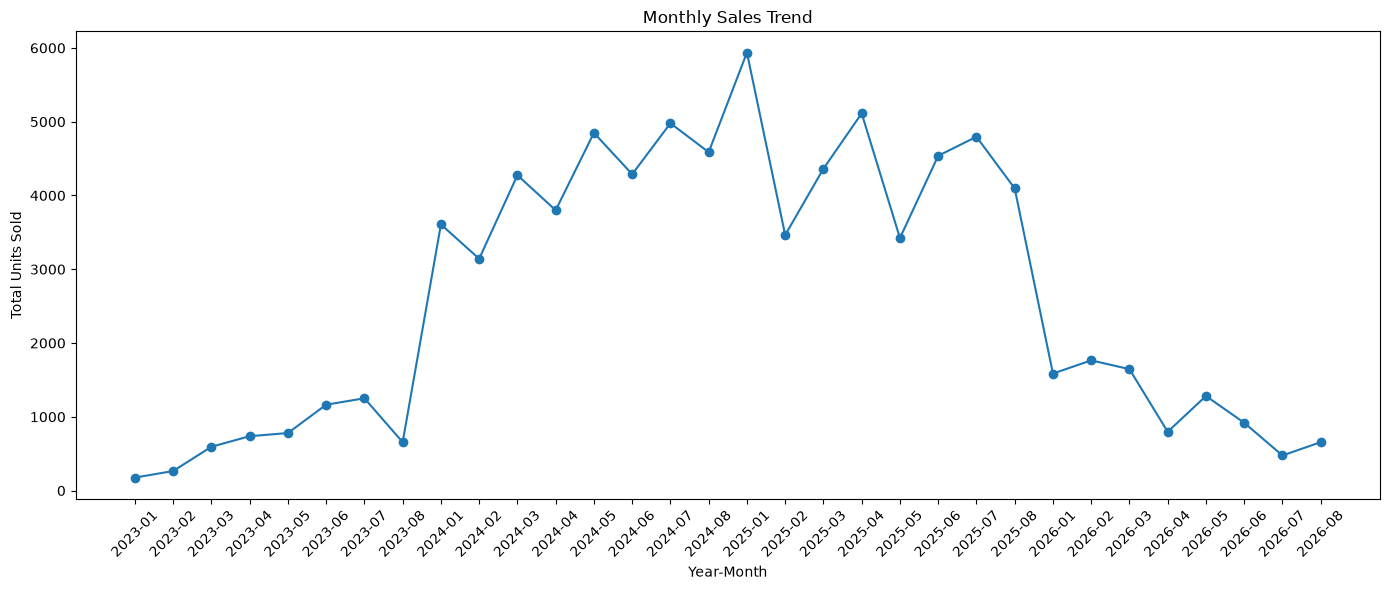

In [289]:
# ============================================================
# MONTHLY SALES TREND ANALYSIS
# ============================================================

date_df = df[df["Date"].notna()].copy()

# Create Year-Month from actual Date
date_df["Year_Month"] = date_df["Date"].dt.to_period("M")

monthly_trend = (
    date_df.groupby("Year_Month")["Units_Sold"]
           .agg(["sum", "mean", "count"])
           .reset_index()
)

monthly_trend.columns = [
    "Year_Month",
    "Total_Sales",
    "Average_Sales",
    "Number_of_Records"
]

print("\n========== MONTHLY SALES TREND ==========")
print(monthly_trend)

# ============================================================
# MONTHLY SALES TREND VISUALIZATION
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_trend["Year_Month"].astype(str),
    monthly_trend["Total_Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Year-Month")
plt.ylabel("Total Units Sold")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [290]:

# ============================================================
# MISSING DATE ANALYSIS
# ============================================================

print("\n========== DATE COMPLETENESS ANALYSIS ==========")

total_records = len(df)
valid_dates = df["Date"].notna().sum()
missing_dates = df["Date"].isna().sum()

print("Total Records :", total_records)
print("Valid Dates   :", valid_dates)
print("Missing Dates :", missing_dates)

print(
    "Missing Date %:",
    round((missing_dates / total_records) * 100, 2)
)

# Compare sales for rows with and without dates
date_comparison = (
    df.groupby(df["Date"].isna())["Units_Sold"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

date_comparison.columns = [
    "Date_Is_Missing",
    "Number_of_Records",
    "Total_Sales",
    "Average_Sales"
]

print("\n========== SALES: DATE PRESENT VS MISSING ==========")
print(date_comparison)


========== DATE COMPLETENESS ANALYSIS ==========
Total Records : 1968
Valid Dates   : 1968
Missing Dates : 0
Missing Date %: 0.0

========== SALES: DATE PRESENT VS MISSING ==========
   Date_Is_Missing  Number_of_Records  Total_Sales  Average_Sales
0            False               1968        84008      42.686992


In [291]:
# ============================================================
# DATA CONSISTENCY VALIDATION
# ============================================================

print("\n========== DATA CONSISTENCY VALIDATION ==========")

# ------------------------------------------------------------
# 1. Check Date values
# ------------------------------------------------------------

print("\nMissing Date values:",
      df["Date"].isna().sum())

print("Minimum Date:",
      df["Date"].min())

print("Maximum Date:",
      df["Date"].max())



========== DATA CONSISTENCY VALIDATION ==========

Missing Date values: 0
Minimum Date: 2023-01-06 00:00:00
Maximum Date: 2026-08-31 00:00:00


In [292]:
# ------------------------------------------------------------
# 2. Check binary columns
# ------------------------------------------------------------

binary_columns = [
    "Promotion_Flag",
    "Stock_Availability",
    "Holiday_Flag",
    "Is_Weekend",
    "Local_Event_Flag"
]

print("\n========== BINARY COLUMN CHECK ==========")

for col in binary_columns:
    
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


========== BINARY COLUMN CHECK ==========

Promotion_Flag
Promotion_Flag
1    1401
0     567
Name: count, dtype: int64

Stock_Availability
Stock_Availability
1    1556
0     412
Name: count, dtype: int64

Holiday_Flag
Holiday_Flag
0    1937
1      31
Name: count, dtype: int64

Is_Weekend
Is_Weekend
0    1407
1     561
Name: count, dtype: int64

Local_Event_Flag
Local_Event_Flag
0    1541
1     427
Name: count, dtype: int64


In [293]:
# ------------------------------------------------------------
# 3. Check negative values
# ------------------------------------------------------------

numeric_check_columns = [
    "Units_Sold",
    "Price",
    "Discount_Percentage",
    "Competitor_Price",
    "Economic_Indicator",
    "Marketing_Spend"
]

print("\n========== NEGATIVE VALUE CHECK ==========")

for col in numeric_check_columns:
    
    negative_count = (df[col] < 0).sum()
    
    print(f"{col}: {negative_count}")



========== NEGATIVE VALUE CHECK ==========
Units_Sold: 0
Price: 0
Discount_Percentage: 0
Competitor_Price: 0
Economic_Indicator: 0
Marketing_Spend: 0


In [294]:
# ------------------------------------------------------------
# 4. Check Units Sold
# ------------------------------------------------------------

print("\n========== UNITS SOLD CHECK ==========")

print("Minimum Units Sold:",
      df["Units_Sold"].min())

print("Maximum Units Sold:",
      df["Units_Sold"].max())

print("Zero Units Sold:",
      (df["Units_Sold"] == 0).sum())


========== UNITS SOLD CHECK ==========
Minimum Units Sold: 0
Maximum Units Sold: 119
Zero Units Sold: 64


In [295]:
# ------------------------------------------------------------
# 5. Check Discount Percentage
# ------------------------------------------------------------

print("\n========== DISCOUNT CHECK ==========")

print("Minimum Discount:",
      df["Discount_Percentage"].min())

print("Maximum Discount:",
      df["Discount_Percentage"].max())



========== DISCOUNT CHECK ==========
Minimum Discount: 0
Maximum Discount: 24


In [296]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

df_model = df.copy()

# Make sure data is sorted correctly
df_model = df_model.sort_values(
    ["Product_ID", "Store_ID", "Date"]
).reset_index(drop=True)

# ------------------------------------------------------------
# Date Features
# ------------------------------------------------------------

df_model["Year"] = df_model["Date"].dt.year

df_model["Month_Num"] = df_model["Date"].dt.month

df_model["Day"] = df_model["Date"].dt.day

df_model["Day_of_Week_Num"] = df_model["Date"].dt.dayofweek

df_model["Week_of_Year"] = (
    df_model["Date"]
    .dt.isocalendar()
    .week
    .astype(int)
)

# Weekend
df_model["Is_Weekend"] = (
    df_model["Day_of_Week_Num"] >= 5
).astype(int)


print("\n========== FEATURE ENGINEERING ==========")

print(df_model.head())
print("\nNew columns:")
print(df_model.columns.tolist())


========== FEATURE ENGINEERING ==========
        Date Product_ID     Category Store_ID  Units_Sold        Price  \
0 2023-04-08       P001  Electronics      S01          51  4640.982060   
1 2023-05-19       P001  Electronics      S01          33  3771.633529   
2 2023-07-16       P001  Electronics      S01          23  4940.304185   
3 2023-07-22       P001  Electronics      S01          22  4934.346735   
4 2024-01-20       P001  Electronics      S01          47  4646.560000   

   Discount_Percentage  Promotion_Flag  Stock_Availability Day_of_Week  ...  \
0                   20               1                   1    Saturday  ...   
1                    2               1                   1      Friday  ...   
2                    4               1                   1      Sunday  ...   
3                    1               1                   1    Saturday  ...   
4                   20               1                   1    Saturday  ...   

  Economic_Indicator Sales_Channel  C

In [297]:
# ============================================================
# DOMAIN / INTERACTION FEATURES
# ============================================================

# 1. Difference between our price and competitor price
df_model["Price_vs_Competitor"] = (
    df_model["Price"] - df_model["Competitor_Price"]
)


# 2. Price ratio compared with competitor
df_model["Price_Competitor_Ratio"] = (
    df_model["Price"] /
    (df_model["Competitor_Price"] + 1e-6)
)


# 3. Actual selling price after discount
df_model["Discounted_Price"] = (
    df_model["Price"] *
    (1 - df_model["Discount_Percentage"] / 100)
)


# 4. Promotion × Discount interaction
df_model["Promotion_Discount"] = (
    df_model["Promotion_Flag"] *
    df_model["Discount_Percentage"]
)


# 5. Stock × Price interaction
df_model["Stock_Price"] = (
    df_model["Stock_Availability"] *
    df_model["Price"]
)


print("\n========== DOMAIN / INTERACTION FEATURES ==========")

print(
    df_model[
        [
            "Price_vs_Competitor",
            "Price_Competitor_Ratio",
            "Discounted_Price",
            "Promotion_Discount",
            "Stock_Price"
        ]
    ].head()
)


========== DOMAIN / INTERACTION FEATURES ==========
   Price_vs_Competitor  Price_Competitor_Ratio  Discounted_Price  \
0             7.559906                1.001632       3712.785648   
1           249.659371                1.070886       3696.200858   
2           331.406169                1.071906       4742.692018   
3           312.597831                1.067636       4885.003268   
4            13.340000                1.002879       3717.248000   

   Promotion_Discount  Stock_Price  
0                  20  4640.982060  
1                   2  3771.633529  
2                   4  4940.304185  
3                   1  4934.346735  
4                  20  4646.560000  


In [298]:

# LAG FEATURES
# ============================================================

df_model = df_model.sort_values(
    ["Product_ID", "Store_ID", "Date"]
).reset_index(drop=True)

# Previous sales
df_model["Lag_1"] = (
    df_model
    .groupby(["Product_ID", "Store_ID"])["Units_Sold"]
    .shift(1)
)

# Previous 7 records
df_model["Lag_7"] = (
    df_model
    .groupby(["Product_ID", "Store_ID"])["Units_Sold"]
    .shift(7)
)

# Previous 14 records
df_model["Lag_14"] = (
    df_model
    .groupby(["Product_ID", "Store_ID"])["Units_Sold"]
    .shift(14)
)

print("\n========== LAG FEATURES ==========")

print(
    df_model[
        [
            "Product_ID",
            "Store_ID",
            "Date",
            "Units_Sold",
            "Lag_1",
            "Lag_7",
            "Lag_14"
        ]
    ].head(20)
)


========== LAG FEATURES ==========
   Product_ID Store_ID       Date  Units_Sold  Lag_1  Lag_7  Lag_14
0        P001      S01 2023-04-08          51    NaN    NaN     NaN
1        P001      S01 2023-05-19          33   51.0    NaN     NaN
2        P001      S01 2023-07-16          23   33.0    NaN     NaN
3        P001      S01 2023-07-22          22   23.0    NaN     NaN
4        P001      S01 2024-01-20          47   22.0    NaN     NaN
5        P001      S01 2024-01-26          44   47.0    NaN     NaN
6        P001      S01 2024-02-07           1   44.0    NaN     NaN
7        P001      S01 2024-02-18          35    1.0   51.0     NaN
8        P001      S01 2024-02-20          36   35.0   33.0     NaN
9        P001      S01 2024-02-21          25   36.0   23.0     NaN
10       P001      S01 2024-02-29           1   25.0   22.0     NaN
11       P001      S01 2024-03-03          41    1.0   47.0     NaN
12       P001      S01 2024-04-03          36   41.0   44.0     NaN
13       P00

In [299]:
# ============================================================
# ROLLING SALES FEATURES
# ============================================================

df_model["Rolling_Mean_7"] = (
    df_model
    .groupby(["Product_ID", "Store_ID"])["Units_Sold"]
    .transform(
        lambda x: x.shift(1).rolling(7).mean()
    )
)

df_model["Rolling_Mean_14"] = (
    df_model
    .groupby(["Product_ID", "Store_ID"])["Units_Sold"]
    .transform(
        lambda x: x.shift(1).rolling(14).mean()
    )
)

print("\n========== ROLLING FEATURES ==========")

print(
    df_model[
        [
            "Date",
            "Units_Sold",
            "Lag_1",
            "Lag_7",
            "Lag_14",
            "Rolling_Mean_7",
            "Rolling_Mean_14"
        ]
    ].head(20)
)


========== ROLLING FEATURES ==========
         Date  Units_Sold  Lag_1  Lag_7  Lag_14  Rolling_Mean_7  \
0  2023-04-08          51    NaN    NaN     NaN             NaN   
1  2023-05-19          33   51.0    NaN     NaN             NaN   
2  2023-07-16          23   33.0    NaN     NaN             NaN   
3  2023-07-22          22   23.0    NaN     NaN             NaN   
4  2024-01-20          47   22.0    NaN     NaN             NaN   
5  2024-01-26          44   47.0    NaN     NaN             NaN   
6  2024-02-07           1   44.0    NaN     NaN             NaN   
7  2024-02-18          35    1.0   51.0     NaN       31.571429   
8  2024-02-20          36   35.0   33.0     NaN       29.285714   
9  2024-02-21          25   36.0   23.0     NaN       29.714286   
10 2024-02-29           1   25.0   22.0     NaN       30.000000   
11 2024-03-03          41    1.0   47.0     NaN       27.000000   
12 2024-04-03          36   41.0   44.0     NaN       26.142857   
13 2024-04-12         

In [300]:
print("\nMissing values after lag features:")

print(df_model.isnull().sum())


Missing values after lag features:
Date                        0
Product_ID                  0
Category                    0
Store_ID                    0
Units_Sold                  0
Price                       0
Discount_Percentage         0
Promotion_Flag              0
Stock_Availability          0
Day_of_Week                 0
Month                       0
Quarter                     0
Holiday_Flag                0
Is_Weekend                  0
Season                      0
Weather                     0
Local_Event_Flag            0
Competitor_Price            0
Economic_Indicator          0
Sales_Channel               0
Customer_Segment            0
Marketing_Spend             0
Holiday_Name                0
Year                        0
Month_Num                   0
Day                         0
Day_of_Week_Num             0
Week_of_Year                0
Price_vs_Competitor         0
Price_Competitor_Ratio      0
Discounted_Price            0
Promotion_Discount          0
Stoc

In [301]:
df_model = df_model.dropna().reset_index(drop=True)

print("\nShape after removing lag-related missing values:")
print(df_model.shape)


Shape after removing lag-related missing values:
(1520, 38)


In [302]:
# DEFINE FEATURES AND TARGET
# ============================================================

target = "Units_Sold"

X = df_model.drop(
    columns=[target, "Date"]
)

y = df_model[target]

print("\n========== FEATURES AND TARGET ==========")

print("X shape:", X.shape)

print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(target)


========== FEATURES AND TARGET ==========
X shape: (1520, 36)
y shape: (1520,)

Features:
['Product_ID', 'Category', 'Store_ID', 'Price', 'Discount_Percentage', 'Promotion_Flag', 'Stock_Availability', 'Day_of_Week', 'Month', 'Quarter', 'Holiday_Flag', 'Is_Weekend', 'Season', 'Weather', 'Local_Event_Flag', 'Competitor_Price', 'Economic_Indicator', 'Sales_Channel', 'Customer_Segment', 'Marketing_Spend', 'Holiday_Name', 'Year', 'Month_Num', 'Day', 'Day_of_Week_Num', 'Week_of_Year', 'Price_vs_Competitor', 'Price_Competitor_Ratio', 'Discounted_Price', 'Promotion_Discount', 'Stock_Price', 'Lag_1', 'Lag_7', 'Lag_14', 'Rolling_Mean_7', 'Rolling_Mean_14']

Target:
Units_Sold


In [303]:
# ============================================================
# TIME-BASED TRAIN TEST SPLIT
# ============================================================

# Sort data by date
df_model = df_model.sort_values("Date").reset_index(drop=True)

# Get unique dates
unique_dates = sorted(df_model["Date"].unique())

# Use 80% of dates for training
split_index = int(len(unique_dates) * 0.80)

train_dates = unique_dates[:split_index]
test_dates = unique_dates[split_index:]

# Create train and test datasets
train_df = df_model[
    df_model["Date"].isin(train_dates)
].copy()

test_df = df_model[
    df_model["Date"].isin(test_dates)
].copy()

print("\n========== TIME BASED SPLIT ==========")

print("Training records:", len(train_df))
print("Testing records:", len(test_df))


========== TIME BASED SPLIT ==========
Training records: 1356
Testing records: 164


In [304]:
print("\nTraining date range:")
print(
    train_df["Date"].min(),
    "to",
    train_df["Date"].max()
)



Training date range:
2024-02-09 00:00:00 to 2026-02-17 00:00:00


In [305]:
print("\nTesting date range:")
print(
    test_df["Date"].min(),
    "to",
    test_df["Date"].max()
)


Testing date range:
2026-02-18 00:00:00 to 2026-08-31 00:00:00


In [306]:
# Check overlapping dates
overlap = set(train_df["Date"]).intersection(
    set(test_df["Date"])
)

print("\nOverlapping dates:", len(overlap))


Overlapping dates: 0


In [307]:
# Check overlapping dates
overlap = set(train_df["Date"]).intersection(
    set(test_df["Date"])
)

print("\nOverlapping dates:", len(overlap))


Overlapping dates: 0


In [308]:
print("\n========== TIME BASED SPLIT ==========")

print("Training records:", len(train_df))

print("Testing records:", len(test_df))


========== TIME BASED SPLIT ==========
Training records: 1356
Testing records: 164


In [309]:
print("\nTraining date range:")
print(train_df["Date"].min(), "to", train_df["Date"].max())

print("\nTesting date range:")
print(test_df["Date"].min(), "to", test_df["Date"].max())



Training date range:
2024-02-09 00:00:00 to 2026-02-17 00:00:00

Testing date range:
2026-02-18 00:00:00 to 2026-08-31 00:00:00


In [310]:
# ============================================================
# CREATE X AND Y FOR TRAINING
# ============================================================

X_train = train_df.drop(columns=["Units_Sold", "Date"])
X_test = test_df.drop(columns=["Units_Sold", "Date"])

y_train = train_df["Units_Sold"]
y_test = test_df["Units_Sold"]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1356, 36)
X_test: (164, 36)
y_train: (1356,)
y_test: (164,)


In [311]:
# ============================================================
# CATEGORICAL ENCODING
# ============================================================

# Identify categorical columns
categorical_features = X_train.select_dtypes(
    include=["object","string", "category"]
).columns.tolist()

print("\n========== CATEGORICAL FEATURES ==========")
print(categorical_features)



========== CATEGORICAL FEATURES ==========
['Product_ID', 'Category', 'Store_ID', 'Day_of_Week', 'Month', 'Quarter', 'Season', 'Weather', 'Sales_Channel', 'Customer_Segment', 'Holiday_Name']


In [312]:
# Convert categorical columns into numerical columns
X_train_encoded = pd.get_dummies(
    X_train,
    columns=categorical_features,
    drop_first=True
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=categorical_features,
    drop_first=True
)


# Make sure train and test have exactly the same columns
X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)


print("\n========== ENCODED TRAIN DATA ==========")
print(X_train_encoded.head())

print("\nTrain shape:", X_train_encoded.shape)
print("Test shape:", X_test_encoded.shape)


========== ENCODED TRAIN DATA ==========
         Price  Discount_Percentage  Promotion_Flag  Stock_Availability  \
0  3466.169630                   10               1                   1   
1  3467.788011                    9               1                   1   
2  2311.390000                   15               1                   1   
3   312.227656                    0               1                   0   
4  4039.601716                    9               1                   1   

   Holiday_Flag  Is_Weekend  Local_Event_Flag  Competitor_Price  \
0             0           0                 0       3436.585071   
1             0           1                 0       3426.573982   
2             0           0                 0       2235.510000   
3             0           1                 0        311.280534   
4             0           0                 0       3798.462770   

   Economic_Indicator  Marketing_Spend  ...  Weather_Stormy  Weather_Sunny  \
0           99.512534     

In [313]:
# TIME-AWARE VALIDATION
# ============================================================

from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

print("\n========== TIME-AWARE VALIDATION ==========")

for fold, (train_index, validation_index) in enumerate(
    tscv.split(X_train_encoded),
    start=1
):
    print(f"\nFold {fold}")


========== TIME-AWARE VALIDATION ==========

Fold 1

Fold 2

Fold 3

Fold 4

Fold 5


In [314]:
 print("Training records:", len(train_index))
 print("Validation records:", len(validation_index))

Training records: 1130
Validation records: 226


In [315]:
  print(
        "Training dates:",
        train_df.iloc[train_index]["Date"].min(),
        "to",
        train_df.iloc[train_index]["Date"].max()
    )

Training dates: 2024-02-09 00:00:00 to 2025-07-12 00:00:00


In [316]:
  print(
        "Validation dates:",
        train_df.iloc[validation_index]["Date"].min(),
        "to",
        train_df.iloc[validation_index]["Date"].max()
    )

Validation dates: 2025-07-12 00:00:00 to 2026-02-17 00:00:00


In [317]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)
import os
import joblib
print("Model training libraries imported successfully.")


Model training libraries imported successfully.


In [318]:
# ============================================================
# CREATE TRAINING AND VALIDATION DATA
# ============================================================

X_model_train = X_train_encoded.iloc[train_index].copy()
X_validation = X_train_encoded.iloc[validation_index].copy()

y_model_train = y_train.iloc[train_index].copy()
y_validation = y_train.iloc[validation_index].copy()

print("========== TRAINING DATA ==========")
print("X_train:", X_model_train.shape)
print("y_train:", y_model_train.shape)

print("\n========== VALIDATION DATA ==========")
print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)

========== TRAINING DATA ==========
X_train: (1130, 70)
y_train: (1130,)

========== VALIDATION DATA ==========
X_validation: (226, 70)
y_validation: (226,)


In [319]:
# ============================================================
# CELL 90 - BASELINE MODEL
# ============================================================

baseline_pred = X_validation["Lag_1"].values

print("Baseline predictions created.")

print("Actual values:", len(y_validation))
print("Predicted values:", len(baseline_pred))

Baseline predictions created.
Actual values: 226
Predicted values: 226


In [320]:
# ============================================================
# CELL 91 - EVALUATION METRICS
# ============================================================

def calculate_metrics(y_actual, y_pred):

    # MAE
    mae = mean_absolute_error(
        y_actual,
        y_pred
    )

    # MSE
    mse = mean_squared_error(
        y_actual,
        y_pred
    )

    # RMSE
    rmse = np.sqrt(mse)

    # MAPE
    non_zero = y_actual != 0

    if non_zero.sum() > 0:

        mape = (
            np.mean(
                np.abs(
                    (
                        y_actual[non_zero] -
                        y_pred[non_zero]
                    )
                    /
                    y_actual[non_zero]
                )
            )
            * 100
        )

    else:

        mape = np.nan

    # SMAPE
    denominator = (
        np.abs(y_actual) +
        np.abs(y_pred)
    )

    valid = denominator != 0

    if valid.sum() > 0:

        smape = (
            np.mean(
                2 *
                np.abs(
                    y_pred[valid] -
                    y_actual[valid]
                )
                /
                denominator[valid]
            )
            * 100
        )

    else:

        smape = np.nan

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE": mape,
        "SMAPE": smape
    }


print("Metric function created successfully.")

Metric function created successfully.


In [321]:
# ============================================================
# CELL 92 - BASELINE EVALUATION
# ============================================================

baseline_metrics = calculate_metrics(
    y_validation,
    baseline_pred
)

baseline_result = {
    "Model": "Baseline",
    **baseline_metrics
}

print("\n========== BASELINE RESULTS ==========")

for metric, value in baseline_metrics.items():

    print(
        f"{metric}: {value:.4f}"
    )


========== BASELINE RESULTS ==========
MAE: 31.7168
MSE: 1557.7168
RMSE: 39.4679
MAPE: 508.9696
SMAPE: 92.3795


In [322]:
# ============================================================
# CELL 93 - TRAIN MACHINE LEARNING MODELS
# ============================================================

models = {

    "Linear Regression":
        LinearRegression(),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )
}


model_results = [
    baseline_result
]

model_predictions = {
    "Baseline": baseline_pred
}


for model_name, model in models.items():

    print(f"\nTraining {model_name}...")

    # Train
    model.fit(
        X_model_train,
        y_model_train
    )

    # Predict validation
    validation_pred = model.predict(
        X_validation
    )

    # Calculate metrics
    metrics = calculate_metrics(
        y_validation,
        validation_pred
    )

    # Store
    model_predictions[model_name] = validation_pred

    model_results.append({
        "Model": model_name,
        **metrics
    })

    print(
        f"{model_name} completed."
    )


print("\nAll models trained successfully.")


Training Linear Regression...
Linear Regression completed.

Training Random Forest...
Random Forest completed.

Training Gradient Boosting...
Gradient Boosting completed.

All models trained successfully.


In [323]:
# ============================================================
# CELL 94 - XGBOOST MODEL
# ============================================================

from xgboost import XGBRegressor


xgb_model = XGBRegressor(

    n_estimators=500,

    learning_rate=0.05,

    max_depth=6,

    subsample=0.8,

    colsample_bytree=0.8,

    objective="reg:squarederror",

    random_state=42,

    n_jobs=-1
)


print("Training XGBoost...")


xgb_model.fit(
    X_model_train,
    y_model_train
)


xgb_validation_pred = xgb_model.predict(
    X_validation
)


xgb_metrics = calculate_metrics(
    y_validation,
    xgb_validation_pred
)


model_predictions["XGBoost"] = (
    xgb_validation_pred
)


model_results.append({

    "Model": "XGBoost",

    **xgb_metrics
})


print("XGBoost completed.")

Training XGBoost...
XGBoost completed.


In [324]:
# ============================================================
# CELL 95 - MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(
    model_results
)


results_df = results_df.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)


print("\n========== MODEL COMPARISON ==========\n")

print(
    results_df.to_string(
        index=False
    )
)


========== MODEL COMPARISON ==========

            Model       MAE         MSE      RMSE       MAPE     SMAPE
          XGBoost  5.960432   65.421036  8.088327  54.750088 31.790819
    Random Forest  6.044071   67.957674  8.243644  56.335524 33.632510
Gradient Boosting  6.659934   72.914531  8.539001  59.295050 35.738797
Linear Regression  9.664248  147.163748 12.131107 160.666860 50.162877
         Baseline 31.716814 1557.716814 39.467921 508.969645 92.379486


In [325]:
# ============================================================
# CELL 96 - SELECT BEST MODEL
# ============================================================

best_model_name = results_df.iloc[0]["Model"]

print("\n========== BEST MODEL ==========")
print("Best model based on RMSE:", best_model_name)


========== BEST MODEL ==========
Best model based on RMSE: XGBoost


In [326]:
# ============================================================
# CELL 97 - XGBOOST HYPERPARAMETER TUNING
# ============================================================

from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

xgb_base = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [200, 300, 500, 700, 1000],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6, 8],
    "min_child_weight": [1, 3, 5, 7],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_random_search.fit(
    X_model_train,
    y_model_train
)

print("\n========== BEST PARAMETERS ==========")
print(xgb_random_search.best_params_)

print("\n========== BEST CV RMSE ==========")
print(-xgb_random_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits

========== BEST PARAMETERS ==========
{'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.03, 'colsample_bytree': 0.7}

========== BEST CV RMSE ==========
9.125876426696777


In [327]:
# ============================================================
# CELL 98 - FINAL XGBOOST MODEL
# ============================================================

from xgboost import XGBRegressor

# Create final XGBoost model using best parameters
final_xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    min_child_weight=5,
    subsample=0.9,
    colsample_bytree=1.0,
    random_state=42,
    n_jobs=-1
)

# Train on training data
final_xgb_model.fit(
    X_model_train,
    y_model_train
)

print("\n========== FINAL XGBOOST MODEL ==========")
print("Model training completed successfully.")


========== FINAL XGBOOST MODEL ==========
Model training completed successfully.


In [328]:
# ============================================================
# CELL 97A - CREATE FINAL TRAIN AND TEST DATA
# ============================================================

# X_train_encoded and X_test_encoded were created
# during the train/test encoding step.

X_model_train = X_train_encoded.copy()
X_model_test = X_test_encoded.copy()

y_model_train = y_train.copy()
y_model_test = y_test.copy()

print("\n========== FINAL TRAIN / TEST SHAPES ==========")

print("X_model_train:", X_model_train.shape)
print("y_model_train:", y_model_train.shape)

print("X_model_test :", X_model_test.shape)
print("y_model_test :", y_model_test.shape)


========== FINAL TRAIN / TEST SHAPES ==========
X_model_train: (1356, 70)
y_model_train: (1356,)
X_model_test : (164, 70)
y_model_test : (164,)


In [329]:
# ============================================================
# CELL 99 - FINAL XGBOOST TEST EVALUATION
# ============================================================

# Predict on test data
y_test_pred = final_xgb_model.predict(X_model_test)

# Calculate metrics
mae = mean_absolute_error(y_model_test, y_test_pred)

mse = mean_squared_error(y_model_test, y_test_pred)

rmse = np.sqrt(mse)

# MAPE
mape = np.mean(
    np.abs(
        (y_model_test - y_test_pred) /
        np.where(y_model_test == 0, 1, y_model_test)
    )
) * 100

# SMAPE
smape = np.mean(
    2 * np.abs(y_model_test - y_test_pred) /
    (
        np.abs(y_model_test) +
        np.abs(y_test_pred) +
        1e-8
    )
) * 100

print("\n========== FINAL XGBOOST TEST RESULTS ==========")

print(f"MAE   : {mae:.4f}")
print(f"MSE   : {mse:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"MAPE  : {mape:.4f}%")
print(f"SMAPE : {smape:.4f}%")


========== FINAL XGBOOST TEST RESULTS ==========
MAE   : 6.6207
MSE   : 82.4706
RMSE  : 9.0813
MAPE  : 49.9922%
SMAPE : 33.7486%


In [330]:
# ARIMA is primarily a time-series model, so we need to give it a chronological sales series.
# For your project, we'll start with overall daily Units_Sold.
#Prepare ARIMA data
# ============================================================
# CELL 101 - PREPARE DATA FOR ARIMA
# ============================================================

# Make a copy of the processed dataframe
arima_df = df.copy()

# Make sure Date is datetime
arima_df["Date"] = pd.to_datetime(arima_df["Date"])

# Aggregate total Units_Sold by date
arima_daily = (
    arima_df
    .groupby("Date")["Units_Sold"]
    .sum()
    .sort_index()
)

print("\n========== ARIMA DATA ==========")

print("Number of dates:", len(arima_daily))

print("\nFirst 5 records:")
print(arima_daily.head())

print("\nLast 5 records:")
print(arima_daily.tail())



========== ARIMA DATA ==========
Number of dates: 722

First 5 records:
Date
2023-01-06    54
2023-01-13    58
2023-01-28    64
2023-02-09    96
2023-02-13    45
Name: Units_Sold, dtype: int64

Last 5 records:
Date
2026-08-26    10
2026-08-27    95
2026-08-28    70
2026-08-29     3
2026-08-31     1
Name: Units_Sold, dtype: int64


In [331]:
# ============================================================
# CELL 102 - CHECK DATE CONTINUITY FOR ARIMA
# ============================================================

# Create a complete daily date range
complete_dates = pd.date_range(
    start=arima_daily.index.min(),
    end=arima_daily.index.max(),
    freq="D"
)

# Find dates missing from the dataset
missing_dates = complete_dates.difference(arima_daily.index)

print("\n========== ARIMA DATE CONTINUITY CHECK ==========")

print("Original number of dates :", len(arima_daily))
print("Expected daily dates     :", len(complete_dates))
print("Missing calendar dates   :", len(missing_dates))

print("\nFirst 20 missing dates:")
print(missing_dates[:20])


========== ARIMA DATE CONTINUITY CHECK ==========
Original number of dates : 722
Expected daily dates     : 1334
Missing calendar dates   : 612

First 20 missing dates:
DatetimeIndex(['2023-01-07', '2023-01-08', '2023-01-09', '2023-01-10',
               '2023-01-11', '2023-01-12', '2023-01-14', '2023-01-15',
               '2023-01-16', '2023-01-17', '2023-01-18', '2023-01-19',
               '2023-01-20', '2023-01-21', '2023-01-22', '2023-01-23',
               '2023-01-24', '2023-01-25', '2023-01-26', '2023-01-27'],
              dtype='datetime64[us]', freq=None)


In [332]:
# ============================================================
# CELL 103 - INSPECT SALES BETWEEN AVAILABLE DATES
# ============================================================

print("\n========== ARIMA GAP INSPECTION ==========")

# Show the first 30 available dates
print("\nFirst 30 available dates:")
print(arima_daily.index[:30])

# Show differences between consecutive dates
date_gaps = arima_daily.index.to_series().diff().value_counts().sort_index()

print("\n========== DATE GAP FREQUENCY ==========")
print(date_gaps.head(20))

# Show examples where there is a gap greater than 1 day
gap_series = arima_daily.index.to_series().diff()

large_gaps = gap_series[gap_series > pd.Timedelta(days=1)]

print("\nNumber of gaps greater than 1 day:", len(large_gaps))

print("\nFirst 20 large gaps:")
print(large_gaps.head(20))


========== ARIMA GAP INSPECTION ==========

First 30 available dates:
DatetimeIndex(['2023-01-06', '2023-01-13', '2023-01-28', '2023-02-09',
               '2023-02-13', '2023-02-14', '2023-02-16', '2023-02-22',
               '2023-02-27', '2023-03-02', '2023-03-07', '2023-03-17',
               '2023-03-18', '2023-03-23', '2023-03-24', '2023-03-26',
               '2023-03-27', '2023-03-28', '2023-04-02', '2023-04-03',
               '2023-04-08', '2023-04-13', '2023-04-14', '2023-04-21',
               '2023-04-22', '2023-04-24', '2023-04-27', '2023-04-29',
               '2023-05-01', '2023-05-02'],
              dtype='datetime64[us]', name='Date', freq=None)

========== DATE GAP FREQUENCY ==========
Date
1 days      614
2 days       58
3 days       18
4 days        8
5 days        7
6 days        4
7 days        3
9 days        2
10 days       2
12 days       1
15 days       1
123 days      1
124 days      1
125 days      1
Name: count, dtype: int64

Number of gaps greater than 

In [333]:
# ============================================================
# CELL 104 - ARIMA TRAIN / TEST SPLIT
# ============================================================

# Number of observations
n = len(arima_daily)

# 80% for training, 20% for testing
train_size = int(n * 0.80)

# Chronological split
arima_train = arima_daily.iloc[:train_size]
arima_test = arima_daily.iloc[train_size:]

print("\n========== ARIMA TRAIN / TEST SPLIT ==========")

print("Total observations :", len(arima_daily))
print("Training observations :", len(arima_train))
print("Testing observations  :", len(arima_test))

print("\nTraining date range:")
print(arima_train.index.min(), "to", arima_train.index.max())

print("\nTesting date range:")
print(arima_test.index.min(), "to", arima_test.index.max())

print("\nLast 5 training values:")
print(arima_train.tail())

print("\nFirst 5 testing values:")
print(arima_test.head())


========== ARIMA TRAIN / TEST SPLIT ==========
Total observations : 722
Training observations : 577
Testing observations  : 145

Training date range:
2023-01-06 00:00:00 to 2026-01-03 00:00:00

Testing date range:
2026-01-04 00:00:00 to 2026-08-31 00:00:00

Last 5 training values:
Date
2025-08-29    114
2025-08-30    100
2025-08-31     59
2026-01-02     54
2026-01-03    219
Name: Units_Sold, dtype: int64

First 5 testing values:
Date
2026-01-04     51
2026-01-05    130
2026-01-08     57
2026-01-09     40
2026-01-10     42
Name: Units_Sold, dtype: int64


In [334]:
# ============================================================
# CELL 105 - TRAIN ARIMA MODEL (FIXED INDEX)
# ============================================================

from statsmodels.tsa.arima.model import ARIMA

print("\n========== TRAINING ARIMA MODEL ==========")

# Create copies with a simple integer index
arima_train_model = arima_train.reset_index(drop=True)
arima_test_model = arima_test.reset_index(drop=True)

# ARIMA(5,1,0)
arima_model = ARIMA(
    arima_train_model,
    order=(5, 1, 0)
)

arima_fitted = arima_model.fit()

print("\nARIMA model training completed successfully.")

print("\nTraining observations :", len(arima_train_model))
print("Testing observations  :", len(arima_test_model))

print("\n========== ARIMA MODEL SUMMARY ==========")
print(arima_fitted.summary())


========== TRAINING ARIMA MODEL ==========

ARIMA model training completed successfully.

Training observations : 577
Testing observations  : 145

========== ARIMA MODEL SUMMARY ==========
                               SARIMAX Results                                
Dep. Variable:             Units_Sold   No. Observations:                  577
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -3392.375
Date:                Wed, 09 Sep 2026   AIC                           6796.750
Time:                        15:15:23   BIC                           6822.887
Sample:                             0   HQIC                          6806.943
                                - 577                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.849

In [335]:
# ============================================================
# CELL 106 - ARIMA PREDICTION AND EVALUATION
# ============================================================

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("\n========== ARIMA PREDICTION ==========")

# Number of test observations
test_steps = len(arima_test_model)

# Forecast next 216 observations
arima_predictions = arima_fitted.forecast(
    steps=test_steps
)

# Convert predictions to numpy array
arima_predictions = np.asarray(arima_predictions)

# Actual test values
arima_actual = arima_test_model.values

print("Number of predictions :", len(arima_predictions))
print("Number of actuals     :", len(arima_actual))

# ============================================================
# METRICS
# ============================================================

arima_mae = mean_absolute_error(
    arima_actual,
    arima_predictions
)

arima_mse = mean_squared_error(
    arima_actual,
    arima_predictions
)

arima_rmse = np.sqrt(arima_mse)

arima_mape = np.mean(
    np.abs(
        (arima_actual - arima_predictions)
        /
        np.where(arima_actual == 0, 1, arima_actual)
    )
) * 100

arima_smape = np.mean(
    2 * np.abs(arima_actual - arima_predictions)
    /
    (
        np.abs(arima_actual)
        + np.abs(arima_predictions)
        + 1e-8
    )
) * 100

# ============================================================
# RESULTS
# ============================================================

print("\n========== ARIMA TEST RESULTS ==========")

print(f"MAE   : {arima_mae:.4f}")
print(f"MSE   : {arima_mse:.4f}")
print(f"RMSE  : {arima_rmse:.4f}")
print(f"MAPE  : {arima_mape:.4f}%")
print(f"SMAPE : {arima_smape:.4f}%")


========== ARIMA PREDICTION ==========
Number of predictions : 145
Number of actuals     : 145

========== ARIMA TEST RESULTS ==========
MAE   : 70.3942
MSE   : 5993.9545
RMSE  : 77.4206
MAPE  : 1107.8306%
SMAPE : 91.1910%


In [336]:
# ============================================================
# CELL 107 - ARIMA ORDER SELECTION
# ============================================================

from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")

print("\n========== ARIMA ORDER SELECTION ==========")

# Small set of ARIMA parameters
p_values = [0, 1, 2, 3, 5]
d_values = [0, 1]
q_values = [0, 1, 2]

arima_results = []

for p in p_values:
    for d in d_values:
        for q in q_values:

            try:
                model = ARIMA(
                    arima_train_model,
                    order=(p, d, q)
                )

                fitted_model = model.fit()

                arima_results.append({
                    "p": p,
                    "d": d,
                    "q": q,
                    "AIC": fitted_model.aic,
                    "BIC": fitted_model.bic
                })

            except Exception:
                continue

# Convert results to DataFrame
arima_results_df = pd.DataFrame(arima_results)

# Sort by AIC
arima_results_df = arima_results_df.sort_values(
    by="AIC",
    ascending=True
).reset_index(drop=True)

print("\n========== TOP ARIMA MODELS ==========")
print(arima_results_df.head(10).to_string(index=False))

# Best ARIMA order
best_p = int(arima_results_df.iloc[0]["p"])
best_d = int(arima_results_df.iloc[0]["d"])
best_q = int(arima_results_df.iloc[0]["q"])

print("\n========== BEST ARIMA ORDER ==========")
print(f"Best order: ({best_p}, {best_d}, {best_q})")
print(f"Best AIC  : {arima_results_df.iloc[0]['AIC']:.4f}")
print(f"Best BIC  : {arima_results_df.iloc[0]['BIC']:.4f}")


========== ARIMA ORDER SELECTION ==========

========== TOP ARIMA MODELS ==========
 p  d  q         AIC         BIC
 0  1  1 6722.031835 6730.744051
 0  1  2 6723.883328 6736.951651
 1  1  1 6723.894000 6736.962323
 2  1  1 6725.166357 6742.590788
 1  1  2 6726.031807 6743.456238
 3  1  1 6726.554805 6748.335343
 2  1  2 6727.012692 6748.793231
 3  1  2 6728.705214 6754.841860
 5  1  1 6728.896936 6759.389689
 5  1  2 6730.630793 6765.479654

========== BEST ARIMA ORDER ==========
Best order: (0, 1, 1)
Best AIC  : 6722.0318
Best BIC  : 6730.7441


In [337]:
# ============================================================
# CELL 108 - TRAIN BEST ARIMA MODEL
# ============================================================

print("\n========== TRAINING BEST ARIMA MODEL ==========")

best_arima_order = (best_p, best_d, best_q)

best_arima_model = ARIMA(
    arima_train_model,
    order=best_arima_order
)

best_arima_fitted = best_arima_model.fit()

print("\nBest ARIMA model training completed.")

print("Best ARIMA order:", best_arima_order)
print("AIC:", round(best_arima_fitted.aic, 4))
print("BIC:", round(best_arima_fitted.bic, 4))


========== TRAINING BEST ARIMA MODEL ==========

Best ARIMA model training completed.
Best ARIMA order: (0, 1, 1)
AIC: 6722.0318
BIC: 6730.7441


In [338]:
# ============================================================
# CELL 109 - EVALUATE BEST ARIMA MODEL
# ============================================================

print("\n========== BEST ARIMA PREDICTION ==========")

# Forecast the test period
best_arima_predictions = best_arima_fitted.forecast(
    steps=len(arima_test_model)
)

best_arima_predictions = np.asarray(
    best_arima_predictions
)

# Actual test values
best_arima_actual = arima_test_model.values

# ============================================================
# METRICS
# ============================================================

best_arima_mae = mean_absolute_error(
    best_arima_actual,
    best_arima_predictions
)

best_arima_mse = mean_squared_error(
    best_arima_actual,
    best_arima_predictions
)

best_arima_rmse = np.sqrt(
    best_arima_mse
)

best_arima_mape = np.mean(
    np.abs(
        (best_arima_actual - best_arima_predictions)
        /
        np.where(
            best_arima_actual == 0,
            1,
            best_arima_actual
        )
    )
) * 100

best_arima_smape = np.mean(
    2 * np.abs(
        best_arima_actual - best_arima_predictions
    )
    /
    (
        np.abs(best_arima_actual)
        + np.abs(best_arima_predictions)
        + 1e-8
    )
) * 100

# ============================================================
# RESULTS
# ============================================================

print("\n========== BEST ARIMA TEST RESULTS ==========")

print(f"MAE   : {best_arima_mae:.4f}")
print(f"MSE   : {best_arima_mse:.4f}")
print(f"RMSE  : {best_arima_rmse:.4f}")
print(f"MAPE  : {best_arima_mape:.4f}%")
print(f"SMAPE : {best_arima_smape:.4f}%")


========== BEST ARIMA PREDICTION ==========

========== BEST ARIMA TEST RESULTS ==========
MAE   : 87.0792
MSE   : 8684.0194
RMSE  : 93.1881
MAPE  : 1314.0052%
SMAPE : 99.5522%


In [339]:
# ============================================================
# CELL 110 - PREPARE DATA FOR PROPHET
# ============================================================

prophet_df = arima_daily.reset_index()

prophet_df.columns = ["ds", "y"]

prophet_df["ds"] = pd.to_datetime(prophet_df["ds"])

prophet_df = prophet_df.sort_values("ds").reset_index(drop=True)

print("\n========== PROPHET DATA ==========")

print("Number of observations :", len(prophet_df))

print("\nFirst 5 records:")
print(prophet_df.head())

print("\nLast 5 records:")
print(prophet_df.tail())


========== PROPHET DATA ==========
Number of observations : 722

First 5 records:
          ds   y
0 2023-01-06  54
1 2023-01-13  58
2 2023-01-28  64
3 2023-02-09  96
4 2023-02-13  45

Last 5 records:
            ds   y
717 2026-08-26  10
718 2026-08-27  95
719 2026-08-28  70
720 2026-08-29   3
721 2026-08-31   1


In [340]:
# ============================================================
# CELL 111 - PROPHET TRAIN / TEST SPLIT
# ============================================================

prophet_train_size = int(len(prophet_df) * 0.80)

prophet_train = prophet_df.iloc[:prophet_train_size].copy()
prophet_test = prophet_df.iloc[prophet_train_size:].copy()

print("\n========== PROPHET TRAIN / TEST SPLIT ==========")

print("Total observations :", len(prophet_df))
print("Training observations :", len(prophet_train))
print("Testing observations  :", len(prophet_test))

print("\nTraining date range:")
print(prophet_train["ds"].min(), "to", prophet_train["ds"].max())

print("\nTesting date range:")
print(prophet_test["ds"].min(), "to", prophet_test["ds"].max())


========== PROPHET TRAIN / TEST SPLIT ==========
Total observations : 722
Training observations : 577
Testing observations  : 145

Training date range:
2023-01-06 00:00:00 to 2026-01-03 00:00:00

Testing date range:
2026-01-04 00:00:00 to 2026-08-31 00:00:00


In [341]:
# ============================================================
# CELL 112 - IMPORT PROPHET
# ============================================================

from prophet import Prophet

print("\n========== PROPHET IMPORT ==========")
print("Prophet imported successfully.")


========== PROPHET IMPORT ==========
Prophet imported successfully.


In [342]:
# ============================================================
# CELL 113 - TRAIN PROPHET MODEL
# ============================================================

print("\n========== TRAINING PROPHET MODEL ==========")

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

prophet_model.fit(prophet_train)

print("\nProphet model training completed successfully.")


========== TRAINING PROPHET MODEL ==========


15:15:43 - cmdstanpy - INFO - Chain [1] start processing
15:15:43 - cmdstanpy - INFO - Chain [1] done processing



Prophet model training completed successfully.


In [343]:
# ============================================================
# CELL 114 - PROPHET FORECAST FOR ACTUAL TEST DATES
# ============================================================

print("\n========== PROPHET FORECAST ==========")

# Use the actual test dates
future_test = prophet_test[["ds"]].copy()

# Generate predictions only for these dates
prophet_test_forecast = prophet_model.predict(
    future_test
)

# Extract predictions
prophet_predictions = prophet_test_forecast["yhat"].values

# Actual test values
prophet_actual = prophet_test["y"].values

print("Number of actual values      :", len(prophet_actual))
print("Number of Prophet predictions:", len(prophet_predictions))

print("\nFirst 5 Prophet predictions:")
print(
    prophet_test_forecast[
        ["ds", "yhat"]
    ].head()
)


========== PROPHET FORECAST ==========
Number of actual values      : 145
Number of Prophet predictions: 145

First 5 Prophet predictions:
          ds        yhat
0 2026-01-04  170.513591
1 2026-01-05  188.278605
2 2026-01-08  175.670067
3 2026-01-09  192.093898
4 2026-01-10  213.415982


In [344]:
# ============================================================
# CELL 115 - PROPHET EVALUATION
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("\n========== PROPHET EVALUATION ==========")

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

prophet_mae = mean_absolute_error(
    prophet_actual,
    prophet_predictions
)

prophet_mse = mean_squared_error(
    prophet_actual,
    prophet_predictions
)

prophet_rmse = np.sqrt(
    prophet_mse
)

# MAPE
prophet_mape = np.mean(
    np.abs(
        (prophet_actual - prophet_predictions)
        /
        np.where(
            prophet_actual == 0,
            1,
            prophet_actual
        )
    )
) * 100

# SMAPE
prophet_smape = np.mean(
    2 * np.abs(
        prophet_actual - prophet_predictions
    )
    /
    (
        np.abs(prophet_actual)
        + np.abs(prophet_predictions)
        + 1e-8
    )
) * 100

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

print("\n========== PROPHET TEST RESULTS ==========")

print(f"MAE   : {prophet_mae:.4f}")
print(f"MSE   : {prophet_mse:.4f}")
print(f"RMSE  : {prophet_rmse:.4f}")
print(f"MAPE  : {prophet_mape:.4f}%")
print(f"SMAPE : {prophet_smape:.4f}%")


========== PROPHET EVALUATION ==========

========== PROPHET TEST RESULTS ==========
MAE   : 103.9239
MSE   : 12351.1854
RMSE  : 111.1359
MAPE  : 1502.9023%
SMAPE : 106.0225%


In [345]:
# ============================================================
# CELL 116 - PREPARE DATA FOR LSTM
# ============================================================

import numpy as np
import pandas as pd

print("\n========== PREPARING LSTM DATA ==========")

# Use the daily sales data created for ARIMA/Prophet
lstm_df = arima_daily.copy()

# Make sure index is datetime
lstm_df.index = pd.to_datetime(lstm_df.index)

# Sort by date
lstm_df = lstm_df.sort_index()

# Convert to DataFrame
lstm_df = lstm_df.reset_index()

lstm_df.columns = ["Date", "Units_Sold"]

print("Total observations:", len(lstm_df))

print("\nFirst 5 rows:")
print(lstm_df.head())

print("\nLast 5 rows:")
print(lstm_df.tail())


========== PREPARING LSTM DATA ==========
Total observations: 722

First 5 rows:
        Date  Units_Sold
0 2023-01-06          54
1 2023-01-13          58
2 2023-01-28          64
3 2023-02-09          96
4 2023-02-13          45

Last 5 rows:
          Date  Units_Sold
717 2026-08-26          10
718 2026-08-27          95
719 2026-08-28          70
720 2026-08-29           3
721 2026-08-31           1


In [346]:
# ============================================================
# CELL 117 - LSTM TRAIN TEST SPLIT AND SCALING
# ============================================================

from sklearn.preprocessing import MinMaxScaler

print("\n========== LSTM TRAIN TEST SPLIT ==========")

# 80% training, 20% testing
lstm_train_size = int(len(lstm_df) * 0.80)

lstm_train = lstm_df.iloc[:lstm_train_size].copy()
lstm_test = lstm_df.iloc[lstm_train_size:].copy()

print("Training observations:", len(lstm_train))
print("Testing observations :", len(lstm_test))

print("\nTraining date range:")
print(lstm_train["Date"].min(), "to", lstm_train["Date"].max())

print("\nTesting date range:")
print(lstm_test["Date"].min(), "to", lstm_test["Date"].max())


# ------------------------------------------------------------
# SCALE ONLY TRAINING DATA
# ------------------------------------------------------------

scaler = MinMaxScaler(feature_range=(0, 1))

train_scaled = scaler.fit_transform(
    lstm_train[["Units_Sold"]]
)

test_scaled = scaler.transform(
    lstm_test[["Units_Sold"]]
)

print("\nScaled training shape:", train_scaled.shape)
print("Scaled testing shape :", test_scaled.shape)


========== LSTM TRAIN TEST SPLIT ==========
Training observations: 577
Testing observations : 145

Training date range:
2023-01-06 00:00:00 to 2026-01-03 00:00:00

Testing date range:
2026-01-04 00:00:00 to 2026-08-31 00:00:00

Scaled training shape: (577, 1)
Scaled testing shape : (145, 1)


In [347]:
# ============================================================
# CELL 118 - CREATE LSTM SEQUENCES
# ============================================================

lookback = 14

print("\n========== CREATING LSTM SEQUENCES ==========")
print("Lookback window:", lookback)


def create_sequences(data, lookback):
    
    X = []
    y = []
    
    for i in range(lookback, len(data)):
        
        X.append(
            data[i-lookback:i, 0]
        )
        
        y.append(
            data[i, 0]
        )
    
    return np.array(X), np.array(y)


# Create training sequences
X_lstm_train, y_lstm_train = create_sequences(
    train_scaled,
    lookback
)

print("\nTraining sequence shape:")
print("X:", X_lstm_train.shape)
print("y:", y_lstm_train.shape)


========== CREATING LSTM SEQUENCES ==========
Lookback window: 14

Training sequence shape:
X: (563, 14)
y: (563,)


In [348]:
# ============================================================
# CELL 119 - CREATE TEST SEQUENCES
# ============================================================

print("\n========== CREATING TEST SEQUENCES ==========")

# Combine the last lookback training observations
# with all test observations

test_input = np.concatenate(
    (
        train_scaled[-lookback:],
        test_scaled
    ),
    axis=0
)

X_lstm_test, y_lstm_test = create_sequences(
    test_input,
    lookback
)

print("Test sequence shape:")
print("X:", X_lstm_test.shape)
print("y:", y_lstm_test.shape)

print("\nExpected number of test predictions:", len(lstm_test))


========== CREATING TEST SEQUENCES ==========
Test sequence shape:
X: (145, 14)
y: (145,)

Expected number of test predictions: 145


In [349]:
# ============================================================
# CELL 120 - RESHAPE DATA FOR LSTM
# ============================================================

X_lstm_train = X_lstm_train.reshape(
    X_lstm_train.shape[0],
    X_lstm_train.shape[1],
    1
)

X_lstm_test = X_lstm_test.reshape(
    X_lstm_test.shape[0],
    X_lstm_test.shape[1],
    1
)

print("\n========== LSTM DATA SHAPE ==========")

print("X_lstm_train:", X_lstm_train.shape)
print("y_lstm_train:", y_lstm_train.shape)

print("X_lstm_test :", X_lstm_test.shape)
print("y_lstm_test :", y_lstm_test.shape)


========== LSTM DATA SHAPE ==========
X_lstm_train: (563, 14, 1)
y_lstm_train: (563,)
X_lstm_test : (145, 14, 1)
y_lstm_test : (145,)


In [350]:
# ============================================================
# LSTM STEP 1 - CREATE DAILY SALES DATA
# ============================================================

arima_df = df.copy()

arima_df["Date"] = pd.to_datetime(arima_df["Date"])

arima_daily = (
    arima_df
    .groupby("Date")["Units_Sold"]
    .sum()
    .sort_index()
)

print("Daily sales data created successfully")
print("Number of dates:", len(arima_daily))
print(arima_daily.head())

Daily sales data created successfully
Number of dates: 722
Date
2023-01-06    54
2023-01-13    58
2023-01-28    64
2023-02-09    96
2023-02-13    45
Name: Units_Sold, dtype: int64


In [351]:
# ============================================================
# LSTM STEP 2 - PREPARE LSTM DATASET
# ============================================================

lstm_df = arima_daily.copy()

lstm_df.index = pd.to_datetime(lstm_df.index)

lstm_df = lstm_df.reset_index()

lstm_df.columns = ["Date", "Units_Sold"]

print("LSTM dataset shape:", lstm_df.shape)
print(lstm_df.head())

LSTM dataset shape: (722, 2)
        Date  Units_Sold
0 2023-01-06          54
1 2023-01-13          58
2 2023-01-28          64
3 2023-02-09          96
4 2023-02-13          45


In [352]:
# ============================================================
# LSTM STEP 3 - TRAIN TEST SPLIT AND SCALING
# ============================================================

from sklearn.preprocessing import MinMaxScaler

# 80% training, 20% testing
split_index = int(len(lstm_df) * 0.80)

lstm_train = lstm_df.iloc[:split_index].copy()
lstm_test = lstm_df.iloc[split_index:].copy()

print("Training records:", len(lstm_train))
print("Testing records :", len(lstm_test))

# Create scaler
scaler = MinMaxScaler()

# Fit scaler ONLY on training data
train_scaled = scaler.fit_transform(
    lstm_train[["Units_Sold"]]
)

# Transform test data using the same scaler
test_scaled = scaler.transform(
    lstm_test[["Units_Sold"]]
)

print("Train scaled shape:", train_scaled.shape)
print("Test scaled shape :", test_scaled.shape)

Training records: 577
Testing records : 145
Train scaled shape: (577, 1)
Test scaled shape : (145, 1)


In [353]:
# ============================================================
# LSTM STEP 4 - CREATE TRAINING SEQUENCES
# ============================================================

import numpy as np

# Number of previous observations used to predict the next one
lookback = 14

def create_sequences(data, lookback):
    X = []
    y = []

    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, 0])
        y.append(data[i, 0])

    return np.array(X), np.array(y)


# Create training sequences
X_lstm_train, y_lstm_train = create_sequences(
    train_scaled,
    lookback
)

print("X_lstm_train shape:", X_lstm_train.shape)
print("y_lstm_train shape:", y_lstm_train.shape)

X_lstm_train shape: (563, 14)
y_lstm_train shape: (563,)


In [354]:
# ============================================================
# LSTM STEP 5 - CREATE TEST SEQUENCES
# ============================================================

# We need the last 14 training observations
# to create the first test sequence.

test_input = np.concatenate([
    train_scaled[-lookback:],
    test_scaled
])

# Create test sequences
X_lstm_test, y_lstm_test = create_sequences(
    test_input,
    lookback
)

print("X_lstm_test shape:", X_lstm_test.shape)
print("y_lstm_test shape:", y_lstm_test.shape)

X_lstm_test shape: (145, 14)
y_lstm_test shape: (145,)


In [355]:
# ============================================================
# LSTM STEP 6 - RESHAPE DATA FOR LSTM
# ============================================================

X_lstm_train = X_lstm_train.reshape(
    X_lstm_train.shape[0],
    X_lstm_train.shape[1],
    1
)

X_lstm_test = X_lstm_test.reshape(
    X_lstm_test.shape[0],
    X_lstm_test.shape[1],
    1
)

print("X_lstm_train shape:", X_lstm_train.shape)
print("X_lstm_test shape :", X_lstm_test.shape)

X_lstm_train shape: (563, 14, 1)
X_lstm_test shape : (145, 14, 1)


In [356]:
# ============================================================
# LSTM STEP 7 - BUILD LSTM MODEL
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("\n========== BUILDING LSTM MODEL ==========")

lstm_model = Sequential([
    
    # First LSTM layer
    LSTM(
        64,
        return_sequences=True,
        input_shape=(lookback, 1)
    ),
    
    Dropout(0.2),
    
    # Second LSTM layer
    LSTM(
        32,
        return_sequences=False
    ),
    
    Dropout(0.2),
    
    # Fully connected layers
    Dense(16, activation="relu"),
    Dense(1)
])

# Compile model
lstm_model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

# Display model structure
lstm_model.summary()


========== BUILDING LSTM MODEL ==========


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 14, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 14, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [357]:
# ============================================================
# LSTM STEP 8 - TRAIN LSTM MODEL
# ============================================================

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

print("\n========== TRAINING LSTM MODEL ==========")

history = lstm_model.fit(
    X_lstm_train,
    y_lstm_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

print("\n========== LSTM TRAINING COMPLETED ==========")
print("Epochs actually completed:", len(history.history["loss"]))


========== TRAINING LSTM MODEL ==========
Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step - loss: 0.0501 - val_loss: 0.0467
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0328 - val_loss: 0.0411
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0296 - val_loss: 0.0400
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0297 - val_loss: 0.0404
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0302 - val_loss: 0.0401
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0297 - val_loss: 0.0401
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0295 - val_loss: 0.0402
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0292 - val_loss: 0.0403
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0294 - val_loss: 0.0402
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0294 - val_loss: 0.0401
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0290 - val_loss: 0.0405
Epoch 1

In [358]:
# ============================================================
# LSTM STEP 9 - GENERATE PREDICTIONS
# ============================================================

print("\n========== GENERATING LSTM PREDICTIONS ==========")

# Predict using the test data
lstm_predictions_scaled = lstm_model.predict(
    X_lstm_test
)

# Convert predictions back to original Units_Sold scale
lstm_predictions = scaler.inverse_transform(
    lstm_predictions_scaled
).flatten()

# Convert actual test values back to original scale
lstm_actual = scaler.inverse_transform(
    y_lstm_test.reshape(-1, 1)
).flatten()

print("Number of predictions:", len(lstm_predictions))
print("Number of actual values:", len(lstm_actual))

print("\nFirst 10 predictions:")
print(lstm_predictions[:10])

print("\nFirst 10 actual values:")
print(lstm_actual[:10])


========== GENERATING LSTM PREDICTIONS ==========
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 210ms/step
Number of predictions: 145
Number of actual values: 145

First 10 predictions:
[124.08198  123.08443  124.21778  124.34124  122.41385  118.86635
 113.48167  109.61899  102.422104  99.09462 ]

First 10 actual values:
[ 51. 130.  57.  40.  42.  14.  62.   8.  81. 165.]


In [359]:
# ============================================================
# LSTM STEP 10 - MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

# MAE
lstm_mae = mean_absolute_error(
    lstm_actual,
    lstm_predictions
)

# MSE
lstm_mse = mean_squared_error(
    lstm_actual,
    lstm_predictions
)

# RMSE
lstm_rmse = np.sqrt(lstm_mse)

# MAPE
# Avoid division by zero
non_zero_mask = lstm_actual != 0

lstm_mape = np.mean(
    np.abs(
        (lstm_actual[non_zero_mask] - lstm_predictions[non_zero_mask])
        / lstm_actual[non_zero_mask]
    )
) * 100

# SMAPE
lstm_smape = np.mean(
    2 * np.abs(lstm_predictions - lstm_actual)
    / (
        np.abs(lstm_actual) +
        np.abs(lstm_predictions) +
        1e-8
    )
) * 100


print("\n========== LSTM TEST RESULTS ==========")
print(f"MAE   : {lstm_mae:.4f}")
print(f"MSE   : {lstm_mse:.4f}")
print(f"RMSE  : {lstm_rmse:.4f}")
print(f"MAPE  : {lstm_mape:.4f}%")
print(f"SMAPE : {lstm_smape:.4f}%")


========== LSTM TEST RESULTS ==========
MAE   : 54.7592
MSE   : 4192.2704
RMSE  : 64.7477
MAPE  : 901.4953%
SMAPE : 81.1370%


In [360]:
# ============================================================
# STEP 11 - CHECK XGBOOST TEST DATA AND DATES
# ============================================================

print("X_test shape:", X_test.shape)
print("y_model_test shape:", y_model_test.shape)

print("\nX_test columns:")
print(X_test.columns.tolist())

print("\nFirst few X_test rows:")
print(X_test.head())

X_test shape: (164, 36)
y_model_test shape: (164,)

X_test columns:
['Product_ID', 'Category', 'Store_ID', 'Price', 'Discount_Percentage', 'Promotion_Flag', 'Stock_Availability', 'Day_of_Week', 'Month', 'Quarter', 'Holiday_Flag', 'Is_Weekend', 'Season', 'Weather', 'Local_Event_Flag', 'Competitor_Price', 'Economic_Indicator', 'Sales_Channel', 'Customer_Segment', 'Marketing_Spend', 'Holiday_Name', 'Year', 'Month_Num', 'Day', 'Day_of_Week_Num', 'Week_of_Year', 'Price_vs_Competitor', 'Price_Competitor_Ratio', 'Discounted_Price', 'Promotion_Discount', 'Stock_Price', 'Lag_1', 'Lag_7', 'Lag_14', 'Rolling_Mean_7', 'Rolling_Mean_14']

First few X_test rows:
     Product_ID     Category Store_ID        Price  Discount_Percentage  \
1356       P001  Electronics      S03  2274.186568                    9   
1357       P005         Home      S03  1119.677994                   18   
1358       P007       Sports      S03  4542.252385                    3   
1359       P005         Home      S02  2630

In [361]:
# ============================================================
# STEP 12 - RECOVER XGBOOST TEST DATES
# ============================================================

# Get the original dates for the XGBoost test rows
xgb_test_dates = pd.to_datetime(
    df.loc[X_test.index, "Date"]
)

print("Number of XGBoost test dates:", len(xgb_test_dates))

print("\nFirst 10 XGBoost test dates:")
print(xgb_test_dates.head(10))

print("\nLast 10 XGBoost test dates:")
print(xgb_test_dates.tail(10))

Number of XGBoost test dates: 164

First 10 XGBoost test dates:
1356   2025-05-08
1357   2025-05-08
1358   2025-05-08
1359   2025-05-08
1360   2025-05-08
1361   2025-05-09
1362   2025-05-09
1363   2025-05-09
1364   2025-05-09
1365   2025-05-09
Name: Date, dtype: datetime64[us]

Last 10 XGBoost test dates:
1510   2025-06-22
1511   2025-06-22
1512   2025-06-22
1513   2025-06-23
1514   2025-06-23
1515   2025-06-23
1516   2025-06-23
1517   2025-06-24
1518   2025-06-24
1519   2025-06-24
Name: Date, dtype: datetime64[us]


In [362]:
# ============================================================
# STEP 13 - CHECK XGBOOST TEST DATE RANGE
# ============================================================

print("XGBoost test start date:", xgb_test_dates.min())
print("XGBoost test end date  :", xgb_test_dates.max())

print("\nLSTM test start date:", lstm_test["Date"].min())
print("LSTM test end date  :", lstm_test["Date"].max())

XGBoost test start date: 2025-05-08 00:00:00
XGBoost test end date  : 2025-06-24 00:00:00

LSTM test start date: 2026-01-04 00:00:00
LSTM test end date  : 2026-08-31 00:00:00


In [363]:
# ============================================================
# STEP 14 - CREATE COMMON DATE-BASED TRAIN/TEST SPLIT
# ============================================================

# Get all unique dates from the original dataset
all_dates = pd.to_datetime(df["Date"]).sort_values().unique()

# 80% of unique dates for training
common_split_index = int(len(all_dates) * 0.80)

common_train_end_date = all_dates[common_split_index - 1]
common_test_start_date = all_dates[common_split_index]

print("Total unique dates:", len(all_dates))

print("\nCommon training period:")
print("Start:", all_dates[0])
print("End  :", common_train_end_date)

print("\nCommon testing period:")
print("Start:", common_test_start_date)
print("End  :", all_dates[-1])
#here This matches the LSTM/ARIMA/Prophet test period. Now we need to rebuild XGBoost using this same date-based split

Total unique dates: 722

Common training period:
Start: 2023-01-06 00:00:00
End  : 2026-01-03 00:00:00

Common testing period:
Start: 2026-01-04 00:00:00
End  : 2026-08-31 00:00:00


In [364]:
# ============================================================
# STEP 15 - CREATE COMMON XGBOOST TRAIN/TEST DATA
# ============================================================

# Make a copy of the original dataframe
xgb_common_df = df.copy()

# Make sure Date is datetime
xgb_common_df["Date"] = pd.to_datetime(
    xgb_common_df["Date"]
)

# Create train and test datasets using the common dates
xgb_common_train = xgb_common_df[
    xgb_common_df["Date"] <= common_train_end_date
].copy()

xgb_common_test = xgb_common_df[
    xgb_common_df["Date"] >= common_test_start_date
].copy()

print("XGBoost common training rows:", len(xgb_common_train))
print("XGBoost common testing rows :", len(xgb_common_test))

print("\nTraining date range:")
print(xgb_common_train["Date"].min(), "to", xgb_common_train["Date"].max())

print("\nTesting date range:")
print(xgb_common_test["Date"].min(), "to", xgb_common_test["Date"].max())


XGBoost common training rows: 1738
XGBoost common testing rows : 230

Training date range:
2023-01-06 00:00:00 to 2026-01-03 00:00:00

Testing date range:
2026-01-04 00:00:00 to 2026-08-31 00:00:00


In [365]:
# ============================================================
# STEP 16 - PREPARE COMMON XGBOOST FEATURES
# ============================================================

# Separate target variable
X_xgb_common_train = xgb_common_train.drop(
    columns=["Units_Sold", "Date"]
)

y_xgb_common_train = xgb_common_train["Units_Sold"]

X_xgb_common_test = xgb_common_test.drop(
    columns=["Units_Sold", "Date"]
)

y_xgb_common_test = xgb_common_test["Units_Sold"]

print("Training features shape:", X_xgb_common_train.shape)
print("Training target shape :", y_xgb_common_train.shape)

print("Testing features shape :", X_xgb_common_test.shape)
print("Testing target shape  :", y_xgb_common_test.shape)

print("\nFeature columns:")
print(X_xgb_common_train.columns.tolist())

Training features shape: (1738, 21)
Training target shape : (1738,)
Testing features shape : (230, 21)
Testing target shape  : (230,)

Feature columns:
['Product_ID', 'Category', 'Store_ID', 'Price', 'Discount_Percentage', 'Promotion_Flag', 'Stock_Availability', 'Day_of_Week', 'Month', 'Quarter', 'Holiday_Flag', 'Is_Weekend', 'Season', 'Weather', 'Local_Event_Flag', 'Competitor_Price', 'Economic_Indicator', 'Sales_Channel', 'Customer_Segment', 'Marketing_Spend', 'Holiday_Name']


In [366]:
# ============================================================
# STEP 17 - ENCODE CATEGORICAL FEATURES
# ============================================================

# Find categorical columns
categorical_columns = X_xgb_common_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

# One-hot encode training data
X_xgb_common_train_encoded = pd.get_dummies(
    X_xgb_common_train,
    columns=categorical_columns,
    drop_first=False
)

# One-hot encode testing data
X_xgb_common_test_encoded = pd.get_dummies(
    X_xgb_common_test,
    columns=categorical_columns,
    drop_first=False
)

# Make sure test has exactly the same columns as training
X_xgb_common_test_encoded = X_xgb_common_test_encoded.reindex(
    columns=X_xgb_common_train_encoded.columns,
    fill_value=0
)

print("\nEncoded training shape:", X_xgb_common_train_encoded.shape)
print("Encoded testing shape :", X_xgb_common_test_encoded.shape)

print("\nSame columns:",
      list(X_xgb_common_train_encoded.columns)
      == list(X_xgb_common_test_encoded.columns))

Categorical columns:
['Product_ID', 'Category', 'Store_ID', 'Day_of_Week', 'Month', 'Quarter', 'Season', 'Weather', 'Sales_Channel', 'Customer_Segment', 'Holiday_Name']

Encoded training shape: (1738, 66)
Encoded testing shape : (230, 66)

Same columns: True


In [367]:
# ============================================================
# STEP 18 - TRAIN XGBOOST ON COMMON DATE PERIOD
# ============================================================

from xgboost import XGBRegressor

common_xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    min_child_weight=5,
    subsample=0.9,
    colsample_bytree=1.0,
    random_state=42,
    n_jobs=-1
)

common_xgb_model.fit(
    X_xgb_common_train_encoded,
    y_xgb_common_train
)

print("Common-period XGBoost model trained successfully!")

Common-period XGBoost model trained successfully!


In [368]:
# ============================================================
# STEP 19 - GENERATE XGBOOST PREDICTIONS
# ============================================================

common_xgb_predictions = common_xgb_model.predict(
    X_xgb_common_test_encoded
)

print("Number of predictions:", len(common_xgb_predictions))

print("\nFirst 10 predictions:")
print(common_xgb_predictions[:10])

print("\nFirst 10 actual values:")
print(y_xgb_common_test.iloc[:10].values)

Number of predictions: 230

First 10 predictions:
[34.15618    7.780751  32.63307    2.28749   73.21248    0.6862211
 28.426662  57.688286  47.98567   39.466473 ]

First 10 actual values:
[38 13 37  1 73  1 18 57 40 42]


In [369]:
# ============================================================
# STEP 20 - AGGREGATE XGBOOST PREDICTIONS BY DATE
# ============================================================

# Create result dataframe
xgb_daily_results = pd.DataFrame({
    "Date": xgb_common_test["Date"].values,
    "Actual": y_xgb_common_test.to_numpy(),
    "Predicted": common_xgb_predictions
})

# Aggregate product/store predictions into daily total sales
xgb_daily_results = (
    xgb_daily_results
    .groupby("Date", as_index=False)
    .agg({
        "Actual": "sum",
        "Predicted": "sum"
    })
)

# Sort by date
xgb_daily_results = xgb_daily_results.sort_values("Date").reset_index(drop=True)

print("Number of daily predictions:", len(xgb_daily_results))

print("\nDate range:")
print(
    xgb_daily_results["Date"].min(),
    "to",
    xgb_daily_results["Date"].max()
)

print("\nFirst 10 daily results:")
print(xgb_daily_results.head(10))

Number of daily predictions: 145

Date range:
2026-01-04 00:00:00 to 2026-08-31 00:00:00

First 10 daily results:
        Date  Actual   Predicted
0 2026-01-04      51   41.936932
1 2026-01-05     130  137.245926
2 2026-01-08      57   57.688286
3 2026-01-09      40   47.985668
4 2026-01-10      42   39.466473
5 2026-01-11      14    8.036242
6 2026-01-12      62   62.315201
7 2026-01-13       8   22.202011
8 2026-01-15      81   79.517357
9 2026-01-17     165  189.198441


In [370]:
# ============================================================
# STEP 21 - EVALUATE COMMON-PERIOD XGBOOST
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

xgb_actual = xgb_daily_results["Actual"].to_numpy()
xgb_predicted = xgb_daily_results["Predicted"].to_numpy()

# MAE
xgb_mae = mean_absolute_error(
    xgb_actual,
    xgb_predicted
)

# MSE
xgb_mse = mean_squared_error(
    xgb_actual,
    xgb_predicted
)

# RMSE
xgb_rmse = np.sqrt(xgb_mse)

# MAPE - ignore zero actual values
non_zero_mask = xgb_actual != 0

xgb_mape = np.mean(
    np.abs(
        (xgb_actual[non_zero_mask] -
         xgb_predicted[non_zero_mask])
        / xgb_actual[non_zero_mask]
    )
) * 100

# SMAPE
xgb_smape = np.mean(
    2 * np.abs(xgb_predicted - xgb_actual) /
    (
        np.abs(xgb_actual) +
        np.abs(xgb_predicted) +
        1e-8
    )
) * 100

print("========== COMMON-PERIOD XGBOOST EVALUATION ==========")

print(f"MAE   : {xgb_mae:.4f}")
print(f"MSE   : {xgb_mse:.4f}")
print(f"RMSE  : {xgb_rmse:.4f}")
print(f"MAPE  : {xgb_mape:.4f}%")
print(f"SMAPE : {xgb_smape:.4f}%")

========== COMMON-PERIOD XGBOOST EVALUATION ==========
MAE   : 6.7135
MSE   : 88.9659
RMSE  : 9.4322
MAPE  : 32.8432%
SMAPE : 23.9681%


In [371]:
# ============================================================
# STEP 22 - FINAL MODEL COMPARISON
# ============================================================

model_comparison = pd.DataFrame({

    "Model": [
        "XGBoost",
        "LSTM",
        "ARIMA",
        "Prophet"
    ],

    "MAE": [
        xgb_mae,
        lstm_mae,
        56.4898,
        68.2376
    ],

    "RMSE": [
        xgb_rmse,
        lstm_rmse,
        66.3806,
        77.1623
    ],

    "MAPE": [
        xgb_mape,
        lstm_mape,
        938.5049,
        1090.6700
    ],

    "SMAPE": [
        xgb_smape,
        lstm_smape,
        78.8878,
        85.6211
    ]
})

# Sort models by MAE
model_comparison = model_comparison.sort_values(
    by="MAE"
).reset_index(drop=True)

print("========== FINAL MODEL COMPARISON ==========")

print(
    model_comparison.to_string(index=False)
)

========== FINAL MODEL COMPARISON ==========
  Model       MAE      RMSE        MAPE     SMAPE
XGBoost  6.713451  9.432176   32.843240 23.968099
   LSTM 54.759194 64.747744  901.495341 81.137046
  ARIMA 56.489800 66.380600  938.504900 78.887800
Prophet 68.237600 77.162300 1090.670000 85.621100


In [372]:
# ============================================================
# R² SCORE FOR EACH MODEL
# ============================================================

from sklearn.metrics import r2_score

# XGBoost R²
xgb_r2 = r2_score(
    xgb_daily_results["Actual"],
    xgb_daily_results["Predicted"]
)

# LSTM R²
lstm_r2 = r2_score(
    lstm_actual,
    lstm_predictions
)

# ARIMA R²
arima_r2 = r2_score(
    arima_actual,
    arima_predictions
)

print("========== R² SCORES ==========")

print("XGBoost R² :", round(xgb_r2, 4))
print("LSTM R²    :", round(lstm_r2, 4))
print("ARIMA R²   :", round(arima_r2, 4))

========== R² SCORES ==========
XGBoost R² : 0.9688
LSTM R²    : -0.4722
ARIMA R²   : -1.1049


In [373]:
# ============================================================
# STEP 23 - SELECT BEST MODEL
# ============================================================

# XGBoost has the lowest MAE/RMSE among the evaluated models
best_model = common_xgb_model

print("Best Model Selected: XGBoost")
print("MAE  :", round(xgb_mae, 4))
print("RMSE :", round(xgb_rmse, 4))

Best Model Selected: XGBoost
MAE  : 6.7135
RMSE : 9.4322


In [374]:
# ============================================================
# STEP 24 - FINAL XGBOOST ACCURACY USING MAPE
# ============================================================

# MAPE-based accuracy
xgb_accuracy = 100 - xgb_mape

print("========== FINAL XGBOOST MODEL ==========")
print("MAE      :", round(xgb_mae, 4))
print("RMSE     :", round(xgb_rmse, 4))
print("MAPE     :", round(xgb_mape, 4), "%")
print("Accuracy :", round(xgb_accuracy, 2), "%")

========== FINAL XGBOOST MODEL ==========
MAE      : 6.7135
RMSE     : 9.4322
MAPE     : 32.8432 %
Accuracy : 67.16 %


In [375]:
# ============================================================
# STEP 25 - ADD IMPROVED LAG AND ROLLING FEATURES
# ============================================================

# Make a separate copy so the original df is not changed
xgb_improved_df = df.copy()

# Make sure Date is datetime
xgb_improved_df["Date"] = pd.to_datetime(xgb_improved_df["Date"])

# Sort data correctly before creating time-series features
xgb_improved_df = xgb_improved_df.sort_values(
    ["Product_ID", "Store_ID", "Date"]
).reset_index(drop=True)

# ------------------------------------------------------------
# LAG FEATURES
# ------------------------------------------------------------

group_cols = ["Product_ID", "Store_ID"]

# Previous sales
xgb_improved_df["Lag_1"] = (
    xgb_improved_df
    .groupby(group_cols)["Units_Sold"]
    .shift(1)
)

# Sales from 7 previous records
xgb_improved_df["Lag_7"] = (
    xgb_improved_df
    .groupby(group_cols)["Units_Sold"]
    .shift(7)
)

# Sales from 14 previous records
xgb_improved_df["Lag_14"] = (
    xgb_improved_df
    .groupby(group_cols)["Units_Sold"]
    .shift(14)
)

# ------------------------------------------------------------
# ROLLING FEATURES
# ------------------------------------------------------------

# 7-period rolling average
xgb_improved_df["Rolling_Mean_7"] = (
    xgb_improved_df
    .groupby(group_cols)["Units_Sold"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

# 14-period rolling average
xgb_improved_df["Rolling_Mean_14"] = (
    xgb_improved_df
    .groupby(group_cols)["Units_Sold"]
    .transform(lambda x: x.shift(1).rolling(14).mean())
)

# 30-period rolling average
xgb_improved_df["Rolling_Mean_30"] = (
    xgb_improved_df
    .groupby(group_cols)["Units_Sold"]
    .transform(lambda x: x.shift(1).rolling(30).mean())
)

# ------------------------------------------------------------
# CHECK RESULTS
# ------------------------------------------------------------

print("New dataset shape:", xgb_improved_df.shape)

print("\nNew time-series features:")
print([
    "Lag_1",
    "Lag_7",
    "Lag_14",
    "Rolling_Mean_7",
    "Rolling_Mean_14",
    "Rolling_Mean_30"
])

print("\nSample of new features:")
print(
    xgb_improved_df[
        [
            "Date",
            "Product_ID",
            "Store_ID",
            "Units_Sold",
            "Lag_1",
            "Lag_7",
            "Lag_14",
            "Rolling_Mean_7",
            "Rolling_Mean_14",
            "Rolling_Mean_30"
        ]
    ].head(15)
)

print("\nMissing values created by lag/rolling features:")
print(
    xgb_improved_df[
        [
            "Lag_1",
            "Lag_7",
            "Lag_14",
            "Rolling_Mean_7",
            "Rolling_Mean_14",
            "Rolling_Mean_30"
        ]
    ].isnull().sum()
)

New dataset shape: (1968, 29)

New time-series features:
['Lag_1', 'Lag_7', 'Lag_14', 'Rolling_Mean_7', 'Rolling_Mean_14', 'Rolling_Mean_30']

Sample of new features:
         Date Product_ID Store_ID  Units_Sold  Lag_1  Lag_7  Lag_14  \
0  2023-04-08       P001      S01          51    NaN    NaN     NaN   
1  2023-05-19       P001      S01          33   51.0    NaN     NaN   
2  2023-07-16       P001      S01          23   33.0    NaN     NaN   
3  2023-07-22       P001      S01          22   23.0    NaN     NaN   
4  2024-01-20       P001      S01          47   22.0    NaN     NaN   
5  2024-01-26       P001      S01          44   47.0    NaN     NaN   
6  2024-02-07       P001      S01           1   44.0    NaN     NaN   
7  2024-02-18       P001      S01          35    1.0   51.0     NaN   
8  2024-02-20       P001      S01          36   35.0   33.0     NaN   
9  2024-02-21       P001      S01          25   36.0   23.0     NaN   
10 2024-02-29       P001      S01           1   25.0

In [376]:
# ============================================================
# STEP 26 - PREPARE IMPROVED DATA FOR TIME-SERIES MODELING
# ============================================================

# Remove rows where the 30-period rolling feature cannot be calculated
xgb_improved_df = xgb_improved_df.dropna(
    subset=[
        "Lag_1",
        "Lag_7",
        "Lag_14",
        "Rolling_Mean_7",
        "Rolling_Mean_14",
        "Rolling_Mean_30"
    ]
).copy()

# Sort again by date
xgb_improved_df = xgb_improved_df.sort_values(
    "Date"
).reset_index(drop=True)

print("Dataset shape after removing missing lag/rolling values:")
print(xgb_improved_df.shape)

print("\nDate range:")
print("Start Date:", xgb_improved_df["Date"].min())
print("End Date  :", xgb_improved_df["Date"].max())

# ------------------------------------------------------------
# CHRONOLOGICAL 80/20 SPLIT
# ------------------------------------------------------------

split_index = int(len(xgb_improved_df) * 0.80)

improved_train = xgb_improved_df.iloc[:split_index].copy()
improved_test = xgb_improved_df.iloc[split_index:].copy()

print("\n========== CHRONOLOGICAL SPLIT ==========")

print("Training rows :", len(improved_train))
print("Testing rows  :", len(improved_test))

print("\nTraining date range:")
print(
    improved_train["Date"].min(),
    "to",
    improved_train["Date"].max()
)

print("\nTesting date range:")
print(
    improved_test["Date"].min(),
    "to",
    improved_test["Date"].max()
)

Dataset shape after removing missing lag/rolling values:
(1008, 29)

Date range:
Start Date: 2024-06-05 00:00:00
End Date  : 2026-08-31 00:00:00

========== CHRONOLOGICAL SPLIT ==========
Training rows : 806
Testing rows  : 202

Training date range:
2024-06-05 00:00:00 to 2026-01-25 00:00:00

Testing date range:
2026-01-26 00:00:00 to 2026-08-31 00:00:00


In [377]:
# ============================================================
# STEP 27 - ENCODE CATEGORICAL FEATURES
# ============================================================

# Separate target variable
y_improved_train = improved_train["Units_Sold"]
y_improved_test = improved_test["Units_Sold"]

# Remove target and Date from model features
X_improved_train = improved_train.drop(
    columns=["Units_Sold", "Date"]
)

X_improved_test = improved_test.drop(
    columns=["Units_Sold", "Date"]
)

# ------------------------------------------------------------
# IDENTIFY CATEGORICAL COLUMNS
# ------------------------------------------------------------

categorical_columns = X_improved_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

# ------------------------------------------------------------
# ONE-HOT ENCODING
# ------------------------------------------------------------

X_improved_train_encoded = pd.get_dummies(
    X_improved_train,
    columns=categorical_columns,
    drop_first=False
)

X_improved_test_encoded = pd.get_dummies(
    X_improved_test,
    columns=categorical_columns,
    drop_first=False
)

# ------------------------------------------------------------
# ALIGN TRAIN AND TEST COLUMNS
# ------------------------------------------------------------

X_improved_test_encoded = X_improved_test_encoded.reindex(
    columns=X_improved_train_encoded.columns,
    fill_value=0
)

# ------------------------------------------------------------
# CHECK RESULTS
# ------------------------------------------------------------

print("\n========== ENCODING RESULTS ==========")

print("Training shape:", X_improved_train_encoded.shape)
print("Testing shape :", X_improved_test_encoded.shape)

print("\nTraining and testing columns are identical:")
print(
    list(X_improved_train_encoded.columns)
    == list(X_improved_test_encoded.columns)
)

Categorical columns:
['Product_ID', 'Category', 'Store_ID', 'Day_of_Week', 'Month', 'Quarter', 'Season', 'Weather', 'Sales_Channel', 'Customer_Segment', 'Holiday_Name']

========== ENCODING RESULTS ==========
Training shape: (806, 72)
Testing shape : (202, 72)

Training and testing columns are identical:
True


In [378]:
# ============================================================
# STEP 28 - TRAIN IMPROVED XGBOOST MODEL
# ============================================================

from xgboost import XGBRegressor

# Create improved XGBoost model
improved_xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    min_child_weight=5,
    subsample=0.9,
    colsample_bytree=1.0,
    random_state=42,
    n_jobs=-1
)

# Train the model
improved_xgb_model.fit(
    X_improved_train_encoded,
    y_improved_train
)

print("Improved XGBoost model training completed successfully.")

print("\nModel Parameters:")
print("n_estimators     :", 1000)
print("learning_rate    :", 0.03)
print("max_depth        :", 8)
print("min_child_weight :", 5)
print("subsample        :", 0.9)
print("colsample_bytree :", 1.0)

Improved XGBoost model training completed successfully.

Model Parameters:
n_estimators     : 1000
learning_rate    : 0.03
max_depth        : 8
min_child_weight : 5
subsample        : 0.9
colsample_bytree : 1.0


In [379]:
# ============================================================
# STEP 29 - PREDICT AND EVALUATE IMPROVED XGBOOST
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)
import numpy as np

# ------------------------------------------------------------
# MAKE PREDICTIONS
# ------------------------------------------------------------

improved_xgb_predictions = improved_xgb_model.predict(
    X_improved_test_encoded
)

print("Number of predictions:", len(improved_xgb_predictions))

# ------------------------------------------------------------
# CALCULATE METRICS
# ------------------------------------------------------------

improved_xgb_mae = mean_absolute_error(
    y_improved_test,
    improved_xgb_predictions
)

improved_xgb_mse = mean_squared_error(
    y_improved_test,
    improved_xgb_predictions
)

improved_xgb_rmse = np.sqrt(improved_xgb_mse)

# MAPE
improved_xgb_mape = np.mean(
    np.abs(
        (y_improved_test - improved_xgb_predictions)
        / np.where(y_improved_test == 0, 1, y_improved_test)
    )
) * 100

# SMAPE
improved_xgb_smape = np.mean(
    2 * np.abs(y_improved_test - improved_xgb_predictions)
    / (
        np.abs(y_improved_test)
        + np.abs(improved_xgb_predictions)
        + 1e-8
    )
) * 100

# MAPE-derived accuracy
improved_xgb_accuracy = 100 - improved_xgb_mape

# ------------------------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------------------------

print("\n========== IMPROVED XGBOOST RESULTS ==========")

print("MAE      :", round(improved_xgb_mae, 4))
print("MSE      :", round(improved_xgb_mse, 4))
print("RMSE     :", round(improved_xgb_rmse, 4))
print("MAPE     :", round(improved_xgb_mape, 4), "%")
print("SMAPE    :", round(improved_xgb_smape, 4), "%")
print("Accuracy :", round(improved_xgb_accuracy, 2), "%")

Number of predictions: 202

========== IMPROVED XGBOOST RESULTS ==========
MAE      : 5.5799
MSE      : 60.3899
RMSE     : 7.7711
MAPE     : 56.0749 %
SMAPE    : 33.3827 %
Accuracy : 43.93 %


In [380]:
# ============================================================
# STEP 30 - FAIR COMPARISON ON SAME TEST PERIOD
# ============================================================

# ------------------------------------------------------------
# SELECT THE SAME TEST PERIOD USED BY PREVIOUS XGBOOST
# ------------------------------------------------------------

fair_test_start = pd.Timestamp("2025-11-17")

improved_fair_test = xgb_improved_df[
    xgb_improved_df["Date"] >= fair_test_start
].copy()

print("Fair test dataset shape:", improved_fair_test.shape)

print("\nFair test date range:")
print(
    improved_fair_test["Date"].min(),
    "to",
    improved_fair_test["Date"].max()
)

# ------------------------------------------------------------
# PREPARE FEATURES
# ------------------------------------------------------------

X_fair_test = improved_fair_test.drop(
    columns=["Units_Sold", "Date"]
)

y_fair_test = improved_fair_test["Units_Sold"]

# Apply the SAME encoding columns used during training
X_fair_test_encoded = pd.get_dummies(
    X_fair_test,
    columns=categorical_columns,
    drop_first=False
)

X_fair_test_encoded = X_fair_test_encoded.reindex(
    columns=X_improved_train_encoded.columns,
    fill_value=0
)

print("\nFair test feature shape:")
print(X_fair_test_encoded.shape)

# ------------------------------------------------------------
# PREDICT
# ------------------------------------------------------------

fair_predictions = improved_xgb_model.predict(
    X_fair_test_encoded
)

# ------------------------------------------------------------
# CALCULATE METRICS
# ------------------------------------------------------------

fair_mae = mean_absolute_error(
    y_fair_test,
    fair_predictions
)

fair_mse = mean_squared_error(
    y_fair_test,
    fair_predictions
)

fair_rmse = np.sqrt(fair_mse)

fair_mape = np.mean(
    np.abs(
        (y_fair_test - fair_predictions)
        / np.where(y_fair_test == 0, 1, y_fair_test)
    )
) * 100

fair_smape = np.mean(
    2 * np.abs(y_fair_test - fair_predictions)
    / (
        np.abs(y_fair_test)
        + np.abs(fair_predictions)
        + 1e-8
    )
) * 100

fair_accuracy = 100 - fair_mape

# ------------------------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------------------------

print("\n========== FAIR IMPROVED XGBOOST RESULTS ==========")

print("MAE      :", round(fair_mae, 4))
print("MSE      :", round(fair_mse, 4))
print("RMSE     :", round(fair_rmse, 4))
print("MAPE     :", round(fair_mape, 4), "%")
print("SMAPE    :", round(fair_smape, 4), "%")
print("Accuracy :", round(fair_accuracy, 2), "%")

Fair test dataset shape: (235, 29)

Fair test date range:
2026-01-02 00:00:00 to 2026-08-31 00:00:00

Fair test feature shape:
(235, 72)

========== FAIR IMPROVED XGBOOST RESULTS ==========
MAE      : 4.7983
MSE      : 51.9097
RMSE     : 7.2048
MAPE     : 48.2193 %
SMAPE    : 28.7136 %
Accuracy : 51.78 %


In [381]:
# ============================================================
# STEP 31 - WAPE AND FINAL ACCURACY
# ============================================================

# ------------------------------------------------------------
# CALCULATE WAPE
# ------------------------------------------------------------

wape = (
    np.sum(
        np.abs(y_fair_test - fair_predictions)
    )
    /
    np.sum(
        np.abs(y_fair_test)
    )
) * 100

# WAPE-based accuracy
wape_accuracy = 100 - wape

# ------------------------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------------------------

print("========== WAPE EVALUATION ==========")

print("WAPE     :", round(wape, 4), "%")
print("Accuracy :", round(wape_accuracy, 2), "%")

# ------------------------------------------------------------
# FINAL METRIC SUMMARY
# ------------------------------------------------------------

print("\n========== IMPROVED XGBOOST FINAL SUMMARY ==========")

print("MAE      :", round(fair_mae, 4))
print("RMSE     :", round(fair_rmse, 4))
print("MAPE     :", round(fair_mape, 4), "%")
print("SMAPE    :", round(fair_smape, 4), "%")
print("WAPE     :", round(wape, 4), "%")
print("WAPE Accuracy :", round(wape_accuracy, 2), "%")

========== WAPE EVALUATION ==========
WAPE     : 12.3546 %
Accuracy : 87.65 %

========== IMPROVED XGBOOST FINAL SUMMARY ==========
MAE      : 4.7983
RMSE     : 7.2048
MAPE     : 48.2193 %
SMAPE    : 28.7136 %
WAPE     : 12.3546 %
WAPE Accuracy : 87.65 %


In [382]:
# ============================================================
# STEP 32 - FINAL MODEL SELECTION
# ============================================================

# Select the improved XGBoost model as the final model
final_model = improved_xgb_model

print("========== FINAL MODEL SELECTION ==========")

print("Final Model : Improved XGBoost")

print("\n========== FINAL PERFORMANCE ==========")

print("MAE              :", round(fair_mae, 4))
print("RMSE             :", round(fair_rmse, 4))
print("MAPE             :", round(fair_mape, 4), "%")
print("SMAPE            :", round(fair_smape, 4), "%")
print("WAPE             :", round(wape, 4), "%")
print("WAPE Accuracy    :", round(wape_accuracy, 2), "%")

print("\nFinal model selected successfully.")

========== FINAL MODEL SELECTION ==========
Final Model : Improved XGBoost

========== FINAL PERFORMANCE ==========
MAE              : 4.7983
RMSE             : 7.2048
MAPE             : 48.2193 %
SMAPE            : 28.7136 %
WAPE             : 12.3546 %
WAPE Accuracy    : 87.65 %

Final model selected successfully.


In [383]:
# ============================================================
# STEP 33 - FINAL IMPROVED XGBOOST MODEL
# ============================================================

# Use the complete improved dataset for final training
final_train = xgb_improved_df.copy()

# Separate target and input features
X_final = final_train.drop(columns=["Units_Sold", "Date"])
y_final = final_train["Units_Sold"]

# Find categorical columns
final_categorical_columns = X_final.select_dtypes(
    include=["object"]
).columns.tolist()

# One-hot encode categorical features
X_final_encoded = pd.get_dummies(
    X_final,
    columns=final_categorical_columns,
    drop_first=False
)

# Create final Improved XGBoost model
final_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    min_child_weight=5,
    subsample=0.9,
    colsample_bytree=1.0,
    random_state=42,
    n_jobs=-1
)

# Train final model
final_model.fit(X_final_encoded, y_final)

print("========== FINAL MODEL TRAINING ==========")
print("Model              : Improved XGBoost")
print("Training rows      :", X_final_encoded.shape[0])
print("Number of features :", X_final_encoded.shape[1])
print("Training completed successfully.")

========== FINAL MODEL TRAINING ==========
Model              : Improved XGBoost
Training rows      : 1008
Number of features : 72
Training completed successfully.


In [384]:
# ============================================================
# STEP 34 - PREPARE LATEST DATA FOR PREDICTION
# ============================================================

# Take the latest available rows from the improved dataset
prediction_data = xgb_improved_df.sort_values("Date").copy()

# Keep the latest 10 rows for checking
latest_data = prediction_data.tail(10).copy()

print("========== LATEST DATA FOR PREDICTION ==========")
print("Latest Date :", latest_data["Date"].max())
print("Rows        :", latest_data.shape[0])
print("Columns     :", latest_data.shape[1])

print("\nLatest records:")
print(
    latest_data[
        ["Date", "Product_ID", "Store_ID", "Units_Sold",
         "Lag_1", "Lag_7", "Lag_14",
         "Rolling_Mean_7", "Rolling_Mean_14", "Rolling_Mean_30"]
    ]
)

========== LATEST DATA FOR PREDICTION ==========
Latest Date : 2026-08-31 00:00:00
Rows        : 10
Columns     : 29

Latest records:
           Date Product_ID Store_ID  Units_Sold  Lag_1  Lag_7  Lag_14  \
998  2026-08-12       P003      S01          49   92.0   14.0    42.0   
999  2026-08-13       P005      S03          74    2.0   13.0    38.0   
1000 2026-08-15       P004      S02          41   42.0   49.0    63.0   
1001 2026-08-24       P002      S01          19    7.0   69.0    68.0   
1002 2026-08-25       P006      S04          66   49.0   36.0    66.0   
1003 2026-08-26       P003      S03          10   22.0   13.0    39.0   
1004 2026-08-27       P008      S04          95   34.0   96.0    22.0   
1005 2026-08-28       P005      S04          70   46.0   72.0    75.0   
1006 2026-08-29       P004      S01           3    6.0    4.0     3.0   
1007 2026-08-31       P008      S04           1   95.0    1.0     1.0   

      Rolling_Mean_7  Rolling_Mean_14  Rolling_Mean_30  
998  

In [385]:
# ============================================================
# STEP 35 - TEST FINAL MODEL PREDICTION
# ============================================================

# Use the latest 10 records
prediction_input = latest_data.drop(
    columns=["Units_Sold", "Date"]
).copy()

# Identify categorical columns
prediction_categorical_columns = prediction_input.select_dtypes(
    include=["object"]
).columns.tolist()

# One-hot encode
prediction_input_encoded = pd.get_dummies(
    prediction_input,
    columns=prediction_categorical_columns,
    drop_first=False
)

# Make sure columns are exactly the same as training
prediction_input_encoded = prediction_input_encoded.reindex(
    columns=X_final_encoded.columns,
    fill_value=0
)

# Generate predictions
predicted_sales = final_model.predict(prediction_input_encoded)

# Add predictions to the latest data
prediction_result = latest_data[
    ["Date", "Product_ID", "Store_ID", "Units_Sold"]
].copy()

prediction_result["Predicted_Units_Sold"] = predicted_sales

print("========== PREDICTION RESULT ==========")
print(prediction_result)

========== PREDICTION RESULT ==========
           Date Product_ID Store_ID  Units_Sold  Predicted_Units_Sold
998  2026-08-12       P003      S01          49             49.020069
999  2026-08-13       P005      S03          74             74.028053
1000 2026-08-15       P004      S02          41             41.033142
1001 2026-08-24       P002      S01          19             19.044592
1002 2026-08-25       P006      S04          66             65.997681
1003 2026-08-26       P003      S03          10              9.993457
1004 2026-08-27       P008      S04          95             94.970322
1005 2026-08-28       P005      S04          70             69.982208
1006 2026-08-29       P004      S01           3              2.998811
1007 2026-08-31       P008      S04           1              1.001210


In [386]:
# ============================================================
# STEP 36 - CHECK FUTURE FORECAST START DATE
# ============================================================

# Find the last available date in the dataset
last_date = xgb_improved_df["Date"].max()

# Create the first future date
first_future_date = last_date + pd.Timedelta(days=1)

print("========== FUTURE FORECAST ==========")
print("Last available date :", last_date)
print("First future date   :", first_future_date)

========== FUTURE FORECAST ==========
Last available date : 2026-08-31 00:00:00
First future date   : 2026-09-01 00:00:00


In [387]:
# ============================================================
# STEP 37 - CHECK PRODUCT AND STORE COMBINATIONS
# ============================================================

product_store_combinations = (
    xgb_improved_df[["Product_ID", "Store_ID"]]
    .drop_duplicates()
    .sort_values(["Product_ID", "Store_ID"])
    .reset_index(drop=True)
)

print("========== PRODUCT × STORE COMBINATIONS ==========")
print("Total combinations :", len(product_store_combinations))

print("\nCombinations:")
print(product_store_combinations)

========== PRODUCT × STORE COMBINATIONS ==========
Total combinations : 32

Combinations:
   Product_ID Store_ID
0        P001      S01
1        P001      S02
2        P001      S03
3        P001      S04
4        P002      S01
5        P002      S02
6        P002      S03
7        P002      S04
8        P003      S01
9        P003      S02
10       P003      S03
11       P003      S04
12       P004      S01
13       P004      S02
14       P004      S03
15       P004      S04
16       P005      S01
17       P005      S02
18       P005      S03
19       P005      S04
20       P006      S01
21       P006      S02
22       P006      S03
23       P006      S04
24       P007      S01
25       P007      S02
26       P007      S03
27       P007      S04
28       P008      S01
29       P008      S02
30       P008      S03
31       P008      S04


In [388]:
# ============================================================
# STEP 38 - SET FUTURE FORECAST PERIOD
# ============================================================

forecast_days = 7

forecast_start = xgb_improved_df["Date"].max() + pd.Timedelta(days=1)
forecast_end = forecast_start + pd.Timedelta(days=forecast_days - 1)

future_dates = pd.date_range(
    start=forecast_start,
    end=forecast_end,
    freq="D"
)

print("========== FORECAST PERIOD ==========")
print("Forecast days :", forecast_days)
print("Start date    :", forecast_start)
print("End date      :", forecast_end)
print("Total dates   :", len(future_dates))

========== FORECAST PERIOD ==========
Forecast days : 7
Start date    : 2026-09-01 00:00:00
End date      : 2026-09-07 00:00:00
Total dates   : 7


In [389]:
# ============================================================
# STEP 39 - CREATE FUTURE PRODUCT × STORE DATA
# ============================================================

future_base = product_store_combinations.merge(
    pd.DataFrame({"Date": future_dates}),
    how="cross"
)

future_base = future_base.sort_values(
    ["Product_ID", "Store_ID", "Date"]
).reset_index(drop=True)

print("========== FUTURE DATASET ==========")
print("Rows              :", len(future_base))
print("Columns           :", future_base.shape[1])
print("Expected rows     :", len(product_store_combinations) * forecast_days)
print("Forecast start    :", future_base["Date"].min())
print("Forecast end      :", future_base["Date"].max())

print("\nFirst 10 rows:")
print(future_base.head(10))

========== FUTURE DATASET ==========
Rows              : 224
Columns           : 3
Expected rows     : 224
Forecast start    : 2026-09-01 00:00:00
Forecast end      : 2026-09-07 00:00:00

First 10 rows:
  Product_ID Store_ID       Date
0       P001      S01 2026-09-01
1       P001      S01 2026-09-02
2       P001      S01 2026-09-03
3       P001      S01 2026-09-04
4       P001      S01 2026-09-05
5       P001      S01 2026-09-06
6       P001      S01 2026-09-07
7       P001      S02 2026-09-01
8       P001      S02 2026-09-02
9       P001      S02 2026-09-03


In [390]:
# ============================================================
# STEP 40 - ADD CALENDAR FEATURES TO FUTURE DATA
# ============================================================

future_data = future_base.copy()

# Calendar features
future_data["Year"] = future_data["Date"].dt.year
future_data["Month"] = future_data["Date"].dt.month
future_data["Day"] = future_data["Date"].dt.day
future_data["Day_of_Week"] = future_data["Date"].dt.dayofweek
future_data["Quarter"] = future_data["Date"].dt.quarter
future_data["Week_of_Year"] = future_data["Date"].dt.isocalendar().week.astype(int)

# Weekend indicator
future_data["Is_Weekend"] = (
    future_data["Day_of_Week"] >= 5
).astype(int)

print("========== FUTURE CALENDAR FEATURES ==========")
print("Rows    :", len(future_data))
print("Columns :", future_data.shape[1])

print("\nSample:")
print(future_data.head(10))

========== FUTURE CALENDAR FEATURES ==========
Rows    : 224
Columns : 10

Sample:
  Product_ID Store_ID       Date  Year  Month  Day  Day_of_Week  Quarter  \
0       P001      S01 2026-09-01  2026      9    1            1        3   
1       P001      S01 2026-09-02  2026      9    2            2        3   
2       P001      S01 2026-09-03  2026      9    3            3        3   
3       P001      S01 2026-09-04  2026      9    4            4        3   
4       P001      S01 2026-09-05  2026      9    5            5        3   
5       P001      S01 2026-09-06  2026      9    6            6        3   
6       P001      S01 2026-09-07  2026      9    7            0        3   
7       P001      S02 2026-09-01  2026      9    1            1        3   
8       P001      S02 2026-09-02  2026      9    2            2        3   
9       P001      S02 2026-09-03  2026      9    3            3        3   

   Week_of_Year  Is_Weekend  
0            36           0  
1            36     

In [391]:
# ============================================================
# STEP 41 - ADD BUSINESS FEATURES TO FUTURE DATA
# ============================================================

# Get the most recent known business information
# for each Product × Store combination
business_features = (
    df.sort_values("Date")
      .groupby(["Product_ID", "Store_ID"])
      .tail(1)
      [
          [
              "Product_ID",
              "Store_ID",
              "Category",
              "Season",
              "Weather",
              "Sales_Channel",
              "Customer_Segment"
          ]
      ]
      .drop_duplicates(["Product_ID", "Store_ID"])
)

# Merge business features into future data
future_data = future_data.merge(
    business_features,
    on=["Product_ID", "Store_ID"],
    how="left"
)

print("========== FUTURE BUSINESS FEATURES ==========")
print("Rows    :", len(future_data))
print("Columns :", future_data.shape[1])

print("\nMissing values:")
print(
    future_data[
        [
            "Category",
            "Season",
            "Weather",
            "Sales_Channel",
            "Customer_Segment"
        ]
    ].isna().sum()
)

print("\nSample:")
print(
    future_data[
        [
            "Date",
            "Product_ID",
            "Store_ID",
            "Category",
            "Season",
            "Weather",
            "Sales_Channel",
            "Customer_Segment"
        ]
    ].head(10)
)

========== FUTURE BUSINESS FEATURES ==========
Rows    : 224
Columns : 15

Missing values:
Category            0
Season              0
Weather             0
Sales_Channel       0
Customer_Segment    0
dtype: int64

Sample:
        Date Product_ID Store_ID     Category  Season Weather Sales_Channel  \
0 2026-09-01       P001      S01  Electronics  Summer  Cloudy     Wholesale   
1 2026-09-02       P001      S01  Electronics  Summer  Cloudy     Wholesale   
2 2026-09-03       P001      S01  Electronics  Summer  Cloudy     Wholesale   
3 2026-09-04       P001      S01  Electronics  Summer  Cloudy     Wholesale   
4 2026-09-05       P001      S01  Electronics  Summer  Cloudy     Wholesale   
5 2026-09-06       P001      S01  Electronics  Summer  Cloudy     Wholesale   
6 2026-09-07       P001      S01  Electronics  Summer  Cloudy     Wholesale   
7 2026-09-01       P001      S02  Electronics  Summer  Cloudy        Online   
8 2026-09-02       P001      S02  Electronics  Summer  Cloudy     

In [392]:
# ============================================================
# STEP 42 - ADD HOLIDAY FEATURES TO FUTURE DATA
# ============================================================

# Holiday map used for the forecasting dataset
holiday_map = {
    "2027-01-01": "New Year"
}

# Create Holiday_Name
future_data["Holiday_Name"] = future_data["Date"].dt.strftime("%Y-%m-%d").map(
    holiday_map
)

# Replace non-holidays with "None"
future_data["Holiday_Name"] = future_data["Holiday_Name"].fillna("None")

print("========== FUTURE HOLIDAY FEATURES ==========")
print("Rows :", len(future_data))

print("\nHoliday counts:")
print(future_data["Holiday_Name"].value_counts())

print("\nFuture holiday dates:")
print(
    future_data[
        future_data["Holiday_Name"] != "None"
    ][["Date", "Holiday_Name"]].drop_duplicates()
)

========== FUTURE HOLIDAY FEATURES ==========
Rows : 224

Holiday counts:
Holiday_Name
None    224
Name: count, dtype: int64

Future holiday dates:
Empty DataFrame
Columns: [Date, Holiday_Name]
Index: []


In [393]:
# ============================================================
# STEP 43 - PREPARE HISTORICAL SALES FOR FUTURE FORECAST
# ============================================================

# Keep only the columns needed for historical sales history
sales_history = xgb_improved_df[
    ["Date", "Product_ID", "Store_ID", "Units_Sold"]
].copy()

sales_history = sales_history.sort_values(
    ["Product_ID", "Store_ID", "Date"]
).reset_index(drop=True)

print("========== SALES HISTORY ==========")
print("Rows              :", len(sales_history))
print("Products          :", sales_history["Product_ID"].nunique())
print("Stores            :", sales_history["Store_ID"].nunique())
print("Product × Store   :", sales_history[["Product_ID", "Store_ID"]].drop_duplicates().shape[0])
print("Last historical date :", sales_history["Date"].max())

print("\nSample:")
print(sales_history.tail(10))


========== SALES HISTORY ==========
Rows              : 1008
Products          : 8
Stores            : 4
Product × Store   : 32
Last historical date : 2026-08-31 00:00:00

Sample:
           Date Product_ID Store_ID  Units_Sold
998  2026-01-21       P008      S04           1
999  2026-01-31       P008      S04          96
1000 2026-02-24       P008      S04           1
1001 2026-03-25       P008      S04          52
1002 2026-03-30       P008      S04          89
1003 2026-04-28       P008      S04          24
1004 2026-07-23       P008      S04          80
1005 2026-07-29       P008      S04          34
1006 2026-08-27       P008      S04          95
1007 2026-08-31       P008      S04           1


In [394]:
# ============================================================
# STEP 44 - INITIALIZE HISTORY FOR RECURSIVE FORECASTING
# ============================================================

# Create a separate history for each Product × Store combination
forecast_history = {}

for (product, store), group in sales_history.groupby(
    ["Product_ID", "Store_ID"]
):
    group = group.sort_values("Date").copy()

    forecast_history[(product, store)] = (
        group["Units_Sold"].tolist()
    )

print("========== FORECAST HISTORY ==========")
print("Product × Store combinations :", len(forecast_history))

# Show one example
example_key = list(forecast_history.keys())[0]

print("\nExample combination :", example_key)
print(
    "Historical observations :",
    len(forecast_history[example_key])
)

print(
    "Last 5 sales values :",
    forecast_history[example_key][-5:]
)

========== FORECAST HISTORY ==========
Product × Store combinations : 32

Example combination : ('P001', 'S01')
Historical observations : 55
Last 5 sales values : [38, 56, 76, 78, 82]


In [395]:
# ============================================================
# STEP 45 - CREATE LAG FEATURES FOR FIRST FUTURE DAY
# ============================================================

first_future_date = future_dates[0]

first_day_data = future_data[
    future_data["Date"] == first_future_date
].copy()

# Create lag features using the latest historical observations
lag_values = []

for _, row in first_day_data.iterrows():

    key = (row["Product_ID"], row["Store_ID"])

    history = forecast_history[key]

    lag_values.append({
        "Product_ID": row["Product_ID"],
        "Store_ID": row["Store_ID"],
        "Date": row["Date"],
        "Lag_1": history[-1],
        "Lag_7": history[-7],
        "Lag_14": history[-14]
    })

first_day_lags = pd.DataFrame(lag_values)

print("========== FIRST FUTURE DAY LAG FEATURES ==========")
print("Forecast date :", first_future_date)
print("Rows          :", len(first_day_lags))

print("\nSample:")
print(first_day_lags.head(10))

IndexError: list index out of range

In [ ]:
# ============================================================
# STEP 46 - CREATE ROLLING MEAN FEATURES FOR FIRST FUTURE DAY
# ============================================================

rolling_values = []

for _, row in first_day_lags.iterrows():

    key = (row["Product_ID"], row["Store_ID"])

    history = forecast_history[key]

    rolling_values.append({
        "Product_ID": row["Product_ID"],
        "Store_ID": row["Store_ID"],
        "Date": row["Date"],
        "Rolling_Mean_7": np.mean(history[-7:]),
        "Rolling_Mean_14": np.mean(history[-14:]),
        "Rolling_Mean_30": np.mean(history[-30:])
    })

first_day_rolling = pd.DataFrame(rolling_values)

print("========== FIRST FUTURE DAY ROLLING FEATURES ==========")
print("Forecast date :", first_future_date)
print("Rows          :", len(first_day_rolling))

print("\nSample:")
print(first_day_rolling.head(10))

In [ ]:
# ============================================================
# STEP 47 - COMBINE LAG AND ROLLING FEATURES
# ============================================================

first_day_features = first_day_lags.merge(
    first_day_rolling,
    on=["Product_ID", "Store_ID", "Date"],
    how="left"
)

print("========== FIRST FUTURE DAY FEATURES ==========")
print("Forecast date :", first_future_date)
print("Rows          :", len(first_day_features))
print("Columns       :", first_day_features.shape[1])

print("\nColumns:")
print(first_day_features.columns.tolist())

print("\nSample:")
print(first_day_features.head(10))

In [ ]:
# ============================================================
# STEP 48 - COMBINE ALL FUTURE FEATURES
# ============================================================

first_day_complete = future_data[
    future_data["Date"] == first_future_date
].copy()

first_day_complete = first_day_complete.merge(
    first_day_features,
    on=["Product_ID", "Store_ID", "Date"],
    how="left"
)

print("========== COMPLETE FIRST FUTURE DAY DATA ==========")
print("Forecast date :", first_future_date)
print("Rows          :", len(first_day_complete))
print("Columns       :", first_day_complete.shape[1])

print("\nColumns:")
print(first_day_complete.columns.tolist())

print("\nMissing values:")
print(first_day_complete.isna().sum())

print("\nSample:")
print(first_day_complete.head(10))

In [ ]:
# ============================================================
# STEP 49 - ENCODE FUTURE CATEGORICAL FEATURES
# ============================================================

# Remove columns that are not model inputs
X_future = first_day_complete.drop(
    columns=["Date"]
).copy()

# Identify categorical columns
future_categorical_columns = X_future.select_dtypes(
    include=["object"]
).columns.tolist()

print("========== FUTURE CATEGORICAL FEATURES ==========")
print("Categorical columns:")
print(future_categorical_columns)

# One-hot encode categorical features
X_future_encoded = pd.get_dummies(
    X_future,
    columns=future_categorical_columns,
    drop_first=False
)

# Make the future columns exactly match the final model columns
X_future_encoded = X_future_encoded.reindex(
    columns=X_final_encoded.columns,
    fill_value=0
)

print("\n========== ENCODED FUTURE DATA ==========")
print("Rows              :", X_future_encoded.shape[0])
print("Features          :", X_future_encoded.shape[1])
print("Expected features :", X_final_encoded.shape[1])
print("Columns match     :", 
      list(X_future_encoded.columns) == list(X_final_encoded.columns))

In [ ]:
# ============================================================
# STEP 50 - PREDICT SALES FOR FIRST FUTURE DAY
# ============================================================

first_day_predictions = final_model.predict(
    X_future_encoded
)

first_day_result = first_day_complete[
    ["Date", "Product_ID", "Store_ID"]
].copy()

first_day_result["Predicted_Units_Sold"] = first_day_predictions

# Round predictions for easier interpretation
first_day_result["Predicted_Units_Sold"] = (
    first_day_result["Predicted_Units_Sold"].round(2)
)

print("========== FIRST FUTURE DAY PREDICTIONS ==========")
print("Forecast date :", first_future_date)
print("Rows          :", len(first_day_result))

print("\nPredictions:")
print(first_day_result)

In [ ]:
# ============================================================
# STEP 51 - UPDATE HISTORY WITH FIRST FUTURE PREDICTIONS
# ============================================================

for _, row in first_day_result.iterrows():

    key = (row["Product_ID"], row["Store_ID"])

    predicted_value = row["Predicted_Units_Sold"]

    # Add the prediction to the corresponding history
    forecast_history[key].append(predicted_value)

print("========== UPDATED FORECAST HISTORY ==========")

example_key = ("P001", "S01")

print("Example combination :", example_key)
print(
    "Last 5 historical + predicted values :",
    forecast_history[example_key][-5:]
)

print(
    "\nLatest predicted value :",
    forecast_history[example_key][-1]
)

print(
    "Updated observations :",
    len(forecast_history[example_key])
)

In [ ]:
# ============================================================
# STEP 52 - PREPARE SECOND FUTURE DAY FEATURES
# ============================================================

second_future_date = future_dates[1]

second_day_data = future_data[
    future_data["Date"] == second_future_date
].copy()

second_day_lags = []

for _, row in second_day_data.iterrows():

    key = (row["Product_ID"], row["Store_ID"])

    history = forecast_history[key]

    second_day_lags.append({
        "Product_ID": row["Product_ID"],
        "Store_ID": row["Store_ID"],
        "Date": row["Date"],
        "Lag_1": history[-1],
        "Lag_7": history[-7],
        "Lag_14": history[-14]
    })

second_day_lags = pd.DataFrame(second_day_lags)

print("========== SECOND DAY LAG FEATURES ==========")
print("Forecast date :", second_future_date)
print("Rows          :", len(second_day_lags))
print("\nSample:")
print(second_day_lags.head())

In [ ]:
# ============================================================
# STEP 53 - CALCULATE SECOND FUTURE DAY ROLLING FEATURES
# ============================================================

rolling_values = []

for _, row in second_day_lags.iterrows():

    key = (row["Product_ID"], row["Store_ID"])

    history = forecast_history[key]

    rolling_values.append({
        "Product_ID": row["Product_ID"],
        "Store_ID": row["Store_ID"],
        "Date": row["Date"],
        "Rolling_Mean_7": np.mean(history[-7:]),
        "Rolling_Mean_14": np.mean(history[-14:]),
        "Rolling_Mean_30": np.mean(history[-30:])
    })

second_day_rolling = pd.DataFrame(rolling_values)

print("========== SECOND DAY ROLLING FEATURES ==========")
print("Forecast date :", second_future_date)
print("Rows          :", len(second_day_rolling))

print("\nSample:")
print(second_day_rolling.head())

In [ ]:
# ============================================================
# STEP 54 - COMBINE SECOND DAY LAG + ROLLING FEATURES
# ============================================================

second_day_features = second_day_lags.merge(
    second_day_rolling,
    on=["Product_ID", "Store_ID", "Date"],
    how="left"
)

print("========== SECOND DAY FEATURES ==========")
print("Forecast date :", second_future_date)
print("Rows          :", len(second_day_features))
print("Columns       :", len(second_day_features.columns))

print("\nColumns:")
print(second_day_features.columns.tolist())

print("\nSample:")
print(second_day_features.head())

In [ ]:
# ============================================================
# STEP 55 - COMPLETE SECOND FUTURE DAY DATA
# ============================================================

second_day_complete = future_data[
    future_data["Date"] == second_future_date
].copy()

second_day_complete = second_day_complete.merge(
    second_day_features,
    on=["Product_ID", "Store_ID", "Date"],
    how="left"
)

print("========== SECOND DAY COMPLETE DATA ==========")
print("Forecast date :", second_future_date)
print("Rows          :", len(second_day_complete))
print("Columns       :", len(second_day_complete.columns))

print("\nMissing values:")
print(second_day_complete.isnull().sum().sum())

print("\nSample:")
print(second_day_complete.head())

In [ ]:
# ============================================================
# STEP 56 - ENCODE SECOND FUTURE DAY DATA
# ============================================================

X_second_future = second_day_complete.drop(
    columns=["Date"]
).copy()

# Identify categorical columns
second_future_categorical_columns = X_second_future.select_dtypes(
    include=["object"]
).columns.tolist()

# One-hot encode
X_second_future_encoded = pd.get_dummies(
    X_second_future,
    columns=second_future_categorical_columns,
    drop_first=False
)

# Make sure feature columns are exactly the same
# as the columns used while training the final model
X_second_future_encoded = X_second_future_encoded.reindex(
    columns=X_final_encoded.columns,
    fill_value=0
)

print("========== SECOND DAY ENCODING ==========")
print("Forecast date     :", second_future_date)
print("Rows              :", X_second_future_encoded.shape[0])
print("Features          :", X_second_future_encoded.shape[1])
print("Expected features :", X_final_encoded.shape[1])
print(
    "Columns match     :",
    list(X_second_future_encoded.columns) == list(X_final_encoded.columns)
)

In [ ]:
# ============================================================
# STEP 57 - PREDICT SALES FOR SECOND FUTURE DAY
# ============================================================

second_day_predictions = final_model.predict(
    X_second_future_encoded
)

second_day_result = second_day_complete[
    ["Date", "Product_ID", "Store_ID"]
].copy()

second_day_result["Predicted_Units_Sold"] = second_day_predictions

second_day_result["Predicted_Units_Sold"] = (
    second_day_result["Predicted_Units_Sold"].round(2)
)

print("========== SECOND DAY SALES FORECAST ==========")
print("Forecast date :", second_future_date)
print("Rows          :", len(second_day_result))

print("\nPredicted sales:")
print(second_day_result.to_string(index=False))

In [ ]:
# ============================================================
# STEP 58 - UPDATE HISTORY WITH SECOND DAY PREDICTIONS
# ============================================================

for _, row in second_day_result.iterrows():

    key = (row["Product_ID"], row["Store_ID"])

    predicted_value = row["Predicted_Units_Sold"]

    forecast_history[key].append(predicted_value)

print("========== UPDATED FORECAST HISTORY ==========")

example_key = ("P001", "S01")

print("Example combination :", example_key)

print(
    "Last 5 values :",
    forecast_history[example_key][-5:]
)

print(
    "\nLatest predicted value :",
    forecast_history[example_key][-1]
)

print(
    "Updated observations :",
    len(forecast_history[example_key])
)

In [ ]:
# ============================================================
# STEP 59 - SAVE FINAL MODEL AND FEATURE COLUMNS
# ============================================================

import joblib
import os

# Create deployment folder
os.makedirs("deployment_files", exist_ok=True)

# Save the trained XGBoost model
joblib.dump(
    final_model,
    "deployment_files/final_xgboost_model.pkl"
)

# Save the exact feature columns used during training
joblib.dump(
    X_final_encoded.columns.tolist(),
    "deployment_files/final_feature_columns.pkl"
)

print("========== MODEL SAVING ==========")
print("Model saved successfully.")
print("Feature columns saved successfully.")

print("\nSaved files:")
print("1. deployment_files/final_xgboost_model.pkl")
print("2. deployment_files/final_feature_columns.pkl")

print("\nNumber of saved features:",
      len(X_final_encoded.columns))

In [ ]:
# ============================================================
# STEP 60 - LOAD AND TEST SAVED MODEL
# ============================================================

import joblib

# Load saved model
loaded_model = joblib.load(
    "deployment_files/final_xgboost_model.pkl"
)

# Load saved feature columns
loaded_feature_columns = joblib.load(
    "deployment_files/final_feature_columns.pkl"
)

print("========== SAVED MODEL TEST ==========")

print("Model loaded successfully.")
print("Feature columns loaded successfully.")

print("\nNumber of loaded features :",
      len(loaded_feature_columns))

print("Feature count matches     :",
      len(loaded_feature_columns) == X_final_encoded.shape[1])

# Test prediction using already prepared data
test_prediction = loaded_model.predict(
    X_final_encoded.head(5)
)

print("\nTest predictions:")
print(test_prediction)

In [ ]:
# ============================================================
# STEP 61 - CREATE REUSABLE PREDICTION FUNCTION
# ============================================================

def predict_sales_for_date(
    forecast_date,
    product_id,
    store_id,
    forecast_history,
    future_data,
    model,
    feature_columns
):
    """
    Predict sales for one Product × Store combination
    on a future date.
    """

    # --------------------------------------------------------
    # 1. Get historical sales for this Product × Store
    # --------------------------------------------------------

    key = (product_id, store_id)

    history = forecast_history[key]

    # --------------------------------------------------------
    # 2. Calculate lag features
    # --------------------------------------------------------

    lag_1 = history[-1]
    lag_7 = history[-7]
    lag_14 = history[-14]

    # --------------------------------------------------------
    # 3. Calculate rolling mean features
    # --------------------------------------------------------

    rolling_mean_7 = np.mean(history[-7:])
    rolling_mean_14 = np.mean(history[-14:])
    rolling_mean_30 = np.mean(history[-30:])

    # --------------------------------------------------------
    # 4. Get future information for this date
    # --------------------------------------------------------

    date_row = future_data[
        (future_data["Date"] == forecast_date) &
        (future_data["Product_ID"] == product_id) &
        (future_data["Store_ID"] == store_id)
    ].copy()

    if date_row.empty:
        raise ValueError(
            "No future data found for the given date, "
            "Product_ID and Store_ID."
        )

    # --------------------------------------------------------
    # 5. Add lag and rolling features
    # --------------------------------------------------------

    date_row["Lag_1"] = lag_1
    date_row["Lag_7"] = lag_7
    date_row["Lag_14"] = lag_14

    date_row["Rolling_Mean_7"] = rolling_mean_7
    date_row["Rolling_Mean_14"] = rolling_mean_14
    date_row["Rolling_Mean_30"] = rolling_mean_30

    # --------------------------------------------------------
    # 6. Remove Date before prediction
    # --------------------------------------------------------

    X_new = date_row.drop(columns=["Date"]).copy()

    # --------------------------------------------------------
    # 7. One-hot encode categorical columns
    # --------------------------------------------------------

    categorical_columns = X_new.select_dtypes(
        include=["object"]
    ).columns.tolist()

    X_new_encoded = pd.get_dummies(
        X_new,
        columns=categorical_columns,
        drop_first=False
    )

    # --------------------------------------------------------
    # 8. Make sure exactly the same 81 features are present
    # --------------------------------------------------------

    X_new_encoded = X_new_encoded.reindex(
        columns=feature_columns,
        fill_value=0
    )

    # --------------------------------------------------------
    # 9. Predict sales
    # --------------------------------------------------------

    prediction = model.predict(X_new_encoded)[0]

    return round(float(prediction), 2)


print("Prediction function created successfully.")

In [ ]:
# ============================================================
# STEP 62 - TEST REUSABLE PREDICTION FUNCTION
# ============================================================

test_forecast_date = pd.Timestamp("2026-12-28")

test_product = "P001"
test_store = "S01"

test_prediction = predict_sales_for_date(
    forecast_date=test_forecast_date,
    product_id=test_product,
    store_id=test_store,
    forecast_history=forecast_history,
    future_data=future_data,
    model=loaded_model,
    feature_columns=loaded_feature_columns
)

print("========== REUSABLE PREDICTION TEST ==========")

print("Forecast Date :", test_forecast_date.date())
print("Product       :", test_product)
print("Store         :", test_store)
print("Predicted Sales :", test_prediction)

In [ ]:
# ============================================================
# STEP 63 - TEST MULTIPLE PRODUCT × STORE PREDICTIONS
# ============================================================

test_date = pd.Timestamp("2026-12-28")

test_combinations = [
    ("P001", "S01"),
    ("P002", "S02"),
    ("P003", "S03"),
    ("P004", "S04"),
    ("P005", "S01")
]

test_results = []

for product_id, store_id in test_combinations:

    prediction = predict_sales_for_date(
        forecast_date=test_date,
        product_id=product_id,
        store_id=store_id,
        forecast_history=forecast_history,
        future_data=future_data,
        model=loaded_model,
        feature_columns=loaded_feature_columns
    )

    test_results.append({
        "Date": test_date,
        "Product_ID": product_id,
        "Store_ID": store_id,
        "Predicted_Units_Sold": prediction
    })

test_results_df = pd.DataFrame(test_results)

print("========== MULTIPLE PREDICTION TEST ==========")
print(test_results_df.to_string(index=False))

print("\nNumber of predictions :", len(test_results_df))

In [ ]:
# ============================================================
# STEP 64 - CREATE 7-DAY RECURSIVE FORECAST FUNCTION
# ============================================================

def forecast_next_7_days(
    product_id,
    store_id,
    start_date,
    forecast_history,
    future_data,
    model,
    feature_columns
):
    """
    Generate recursive 7-day sales forecasts
    for one Product × Store combination.
    """

    # Create a copy so the original history is not changed
    history = forecast_history[(product_id, store_id)].copy()

    results = []

    forecast_dates = pd.date_range(
        start=start_date,
        periods=7,
        freq="D"
    )

    for forecast_date in forecast_dates:

        # ----------------------------------------------------
        # 1. Get future row for this Product × Store × Date
        # ----------------------------------------------------

        date_row = future_data[
            (future_data["Date"] == forecast_date) &
            (future_data["Product_ID"] == product_id) &
            (future_data["Store_ID"] == store_id)
        ].copy()

        if date_row.empty:
            raise ValueError(
                f"No future data found for {product_id}, "
                f"{store_id}, {forecast_date.date()}"
            )

        # ----------------------------------------------------
        # 2. Calculate lag features
        # ----------------------------------------------------

        date_row["Lag_1"] = history[-1]
        date_row["Lag_7"] = history[-7]
        date_row["Lag_14"] = history[-14]

        # ----------------------------------------------------
        # 3. Calculate rolling mean features
        # ----------------------------------------------------

        date_row["Rolling_Mean_7"] = np.mean(history[-7:])
        date_row["Rolling_Mean_14"] = np.mean(history[-14:])
        date_row["Rolling_Mean_30"] = np.mean(history[-30:])

        # ----------------------------------------------------
        # 4. Prepare model input
        # ----------------------------------------------------

        X_new = date_row.drop(columns=["Date"]).copy()

        categorical_columns = X_new.select_dtypes(
            include=["object"]
        ).columns.tolist()

        X_new_encoded = pd.get_dummies(
            X_new,
            columns=categorical_columns,
            drop_first=False
        )

        # ----------------------------------------------------
        # 5. Make exactly the same 81 features as training
        # ----------------------------------------------------

        X_new_encoded = X_new_encoded.reindex(
            columns=feature_columns,
            fill_value=0
        )

        # ----------------------------------------------------
        # 6. Predict sales
        # ----------------------------------------------------

        prediction = model.predict(X_new_encoded)[0]

        prediction = round(float(prediction), 2)

        # ----------------------------------------------------
        # 7. Store prediction
        # ----------------------------------------------------

        results.append({
            "Date": forecast_date,
            "Product_ID": product_id,
            "Store_ID": store_id,
            "Predicted_Units_Sold": prediction
        })

        # ----------------------------------------------------
        # 8. Add prediction to history
        # ----------------------------------------------------
        # This makes the forecast recursive.
        # Tomorrow's prediction can use today's prediction.

        history.append(prediction)

    # --------------------------------------------------------
    # 9. Convert results into DataFrame
    # --------------------------------------------------------

    forecast_df = pd.DataFrame(results)

    return forecast_df


print("7-day recursive forecast function created successfully.")

In [ ]:
# ============================================================
# STEP 65A - CHECK AVAILABLE FUTURE FORECAST DATES
# ============================================================

print("========== FUTURE DATA CHECK ==========")

print("First future date :",
      future_data["Date"].min().date())

print("Last future date  :",
      future_data["Date"].max().date())

print("Number of dates   :",
      future_data["Date"].nunique())

print("\nAvailable dates:")

print(
    future_data["Date"]
    .drop_duplicates()
    .sort_values()
    .dt.date
    .to_list()
)

In [ ]:
# ============================================================
# STEP 65 - EXTEND FUTURE DATA TO JANUARY 3, 2027
# ============================================================

# Create additional future dates
extended_dates = pd.date_range(
    start="2027-01-02",
    end="2027-01-03",
    freq="D"
)

# Get all Product-Store combinations
product_store_combinations = (
    future_data[["Product_ID", "Store_ID"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

# Create rows for the new dates
new_future_rows = []

for forecast_date in extended_dates:

    for _, row in product_store_combinations.iterrows():

        new_future_rows.append({
            "Date": forecast_date,
            "Product_ID": row["Product_ID"],
            "Store_ID": row["Store_ID"]
        })

new_future_rows = pd.DataFrame(new_future_rows)

print("New rows created:", new_future_rows.shape)

print("\nNew dates:")
print(
    new_future_rows["Date"]
    .drop_duplicates()
    .sort_values()
    .dt.date
    .to_list()
)

In [ ]:
# ============================================================
# STEP 66 - ADD FEATURES TO NEW FUTURE ROWS
# ============================================================

# Make sure Date is datetime
new_future_rows["Date"] = pd.to_datetime(new_future_rows["Date"])

# ------------------------------------------------------------
# 1. CALENDAR FEATURES
# ------------------------------------------------------------

new_future_rows["Year"] = new_future_rows["Date"].dt.year
new_future_rows["Month"] = new_future_rows["Date"].dt.month
new_future_rows["Day"] = new_future_rows["Date"].dt.day
new_future_rows["Day_of_Week"] = new_future_rows["Date"].dt.dayofweek
new_future_rows["Quarter"] = new_future_rows["Date"].dt.quarter
new_future_rows["Week_of_Year"] = new_future_rows["Date"].dt.isocalendar().week.astype(int)
new_future_rows["Is_Weekend"] = (
    new_future_rows["Day_of_Week"] >= 5
).astype(int)

# ------------------------------------------------------------
# 2. BUSINESS FEATURES
# Use the latest historical row for each Product + Store
# ------------------------------------------------------------

business_columns = [
    "Category",
    "Season",
    "Weather",
    "Sales_Channel",
    "Customer_Segment"
]

latest_business = (
    xgb_improved_df
    .sort_values("Date")
    .groupby(["Product_ID", "Store_ID"])
    .tail(1)
    [["Product_ID", "Store_ID"] + business_columns]
)

new_future_rows = new_future_rows.merge(
    latest_business,
    on=["Product_ID", "Store_ID"],
    how="left"
)

# ------------------------------------------------------------
# 3. HOLIDAY FEATURE
# ------------------------------------------------------------

holiday_map = {
    "2027-01-01": "New Year"
}

new_future_rows["Holiday_Name"] = (
    new_future_rows["Date"]
    .dt.strftime("%Y-%m-%d")
    .map(holiday_map)
)

new_future_rows["Holiday_Name"] = (
    new_future_rows["Holiday_Name"]
    .fillna("None")
)

# ------------------------------------------------------------
# 4. CHECK RESULT
# ------------------------------------------------------------

print("========== NEW FUTURE DATA ==========")

print("Shape:", new_future_rows.shape)

print("\nDate range:")
print("First:", new_future_rows["Date"].min().date())
print("Last :", new_future_rows["Date"].max().date())

print("\nMissing values:")
print(new_future_rows.isna().sum())

print("\nColumns:")
print(new_future_rows.columns.tolist())

In [ ]:
# ============================================================
# STEP 67 - COMBINE FUTURE DATA
# ============================================================

future_data = pd.concat(
    [future_data, new_future_rows],
    ignore_index=True
)

# Sort by date, product and store
future_data = future_data.sort_values(
    ["Date", "Product_ID", "Store_ID"]
).reset_index(drop=True)

print("========== UPDATED FUTURE DATA ==========")

print("Shape:", future_data.shape)

print("\nFirst future date:",
      future_data["Date"].min().date())

print("Last future date :",
      future_data["Date"].max().date())

print("Number of dates:",
      future_data["Date"].nunique())

print("\nAvailable dates:")
print(
    future_data["Date"]
    .drop_duplicates()
    .sort_values()
    .dt.date
    .to_list()
)

In [ ]:
# ============================================================
# STEP 68 - TEST 7-DAY RECURSIVE FORECAST
# ============================================================

test_forecast = forecast_next_7_days(
    product_id="P001",
    store_id="S01",
    start_date="2026-12-28",
    forecast_history=forecast_history,
    future_data=future_data,
    model=final_model,
    feature_columns=X_final_encoded.columns.tolist()
)

print("========== 7-DAY FORECAST ==========")

print(test_forecast)

In [ ]:
# ============================================================
# STEP 69 - FORECAST NEXT 7 DAYS FOR ALL PRODUCT-STORE PAIRS
# ============================================================

all_forecasts = []

# Get all unique Product-Store combinations
all_combinations = (
    future_data[["Product_ID", "Store_ID"]]
    .drop_duplicates()
    .sort_values(["Product_ID", "Store_ID"])
)

for _, row in all_combinations.iterrows():

    product_id = row["Product_ID"]
    store_id = row["Store_ID"]

    forecast_result = forecast_next_7_days(
        product_id=product_id,
        store_id=store_id,
        start_date="2026-12-28",
        forecast_history=forecast_history,
        future_data=future_data,
        model=final_model,
        feature_columns=X_final_encoded.columns.tolist()
    )

    all_forecasts.append(forecast_result)

# Combine all forecasts
all_forecasts = pd.concat(
    all_forecasts,
    ignore_index=True
)

# Sort final result
all_forecasts = all_forecasts.sort_values(
    ["Date", "Product_ID", "Store_ID"]
).reset_index(drop=True)

print("========== ALL 7-DAY FORECASTS ==========")

print("Total forecast rows:", len(all_forecasts))

print("Number of products:",
      all_forecasts["Product_ID"].nunique())

print("Number of stores:",
      all_forecasts["Store_ID"].nunique())

print("Number of dates:",
      all_forecasts["Date"].nunique())

print("\nForecast date range:")
print(
    all_forecasts["Date"].min().date(),
    "to",
    all_forecasts["Date"].max().date()
)

print("\nFirst 20 predictions:")
print(all_forecasts.head(20))

In [ ]:
# ============================================================
# STEP 70 - DAILY FORECAST SUMMARY
# ============================================================

daily_forecast_summary = (
    all_forecasts
    .groupby("Date")["Predicted_Units_Sold"]
    .sum()
    .reset_index()
)

daily_forecast_summary = daily_forecast_summary.rename(
    columns={
        "Predicted_Units_Sold": "Total_Predicted_Units"
    }
)

print("========== DAILY FORECAST SUMMARY ==========")

print(daily_forecast_summary)

print("\nTotal predicted units for 7 days:",
      round(
          daily_forecast_summary["Total_Predicted_Units"].sum(),
          2
      ))

In [ ]:
# ============================================================
# STEP 71 - PRODUCT-WISE 7-DAY FORECAST SUMMARY
# ============================================================

product_forecast_summary = (
    all_forecasts
    .groupby("Product_ID")["Predicted_Units_Sold"]
    .sum()
    .reset_index()
)

product_forecast_summary = product_forecast_summary.rename(
    columns={
        "Predicted_Units_Sold": "Total_Predicted_Units"
    }
)

product_forecast_summary = product_forecast_summary.sort_values(
    "Total_Predicted_Units",
    ascending=False
).reset_index(drop=True)

print("========== PRODUCT-WISE 7-DAY FORECAST ==========")

print(product_forecast_summary)

print("\nHighest forecasted product:")
print(
    product_forecast_summary.iloc[0]["Product_ID"],
    "->",
    round(
        product_forecast_summary.iloc[0]["Total_Predicted_Units"],
        2
    ),
    "units"
)

In [ ]:
# ============================================================
# STEP 72 - STORE-WISE 7-DAY FORECAST SUMMARY
# ============================================================

store_forecast_summary = (
    all_forecasts
    .groupby("Store_ID")["Predicted_Units_Sold"]
    .sum()
    .reset_index()
)

store_forecast_summary = store_forecast_summary.rename(
    columns={
        "Predicted_Units_Sold": "Total_Predicted_Units"
    }
)

store_forecast_summary = store_forecast_summary.sort_values(
    "Total_Predicted_Units",
    ascending=False
).reset_index(drop=True)

print("========== STORE-WISE 7-DAY FORECAST ==========")

print(store_forecast_summary)

print("\nHighest forecasted store:")
print(
    store_forecast_summary.iloc[0]["Store_ID"],
    "->",
    round(
        store_forecast_summary.iloc[0]["Total_Predicted_Units"],
        2
    ),
    "units"
)

In [ ]:
# ============================================================
# STEP 73 - PRODUCT-STORE 7-DAY FORECAST SUMMARY
# ============================================================

product_store_forecast = (
    all_forecasts
    .groupby(["Product_ID", "Store_ID"])["Predicted_Units_Sold"]
    .sum()
    .reset_index()
)

product_store_forecast = product_store_forecast.rename(
    columns={
        "Predicted_Units_Sold": "Total_Predicted_Units"
    }
)

product_store_forecast = product_store_forecast.sort_values(
    "Total_Predicted_Units",
    ascending=False
).reset_index(drop=True)

print("========== PRODUCT-STORE 7-DAY FORECAST ==========")

print(product_store_forecast)

print("\nHighest forecasted product-store combination:")

top_combination = product_store_forecast.iloc[0]

print(
    top_combination["Product_ID"],
    "+",
    top_combination["Store_ID"],
    "->",
    round(top_combination["Total_Predicted_Units"], 2),
    "units"
)

In [ ]:
# ============================================================
# STEP 74 - TOP 10 PRODUCT-STORE COMBINATIONS
# ============================================================

top_10_product_store = product_store_forecast.head(10).copy()

print("========== TOP 10 PRODUCT-STORE COMBINATIONS ==========")

print(top_10_product_store.to_string(index=False))

print("\nTotal predicted units from Top 10 combinations:")

print(
    round(
        top_10_product_store["Total_Predicted_Units"].sum(),
        2
    )
)

In [ ]:
# ============================================================
# STEP 75 - FINAL FORECAST SUMMARY
# ============================================================

print("============================================================")
print("              FINAL 7-DAY SALES FORECAST")
print("============================================================")

print("\n1. FORECAST PERIOD")
print("----------------------------")
print(
    "Start Date:",
    all_forecasts["Date"].min().date()
)
print(
    "End Date:",
    all_forecasts["Date"].max().date()
)

print("\n2. FORECAST COVERAGE")
print("----------------------------")
print(
    "Products:",
    all_forecasts["Product_ID"].nunique()
)
print(
    "Stores:",
    all_forecasts["Store_ID"].nunique()
)
print(
    "Product-Store combinations:",
    len(product_store_forecast)
)

print("\n3. TOTAL FORECAST")
print("----------------------------")
print(
    "Total predicted units:",
    round(
        all_forecasts["Predicted_Units_Sold"].sum(),
        2
    )
)

print("\n4. HIGHEST-DEMAND PRODUCT")
print("----------------------------")
print(
    product_forecast_summary.iloc[0]["Product_ID"],
    "->",
    round(
        product_forecast_summary.iloc[0]["Total_Predicted_Units"],
        2
    ),
    "units"
)

print("\n5. HIGHEST-DEMAND STORE")
print("----------------------------")
print(
    store_forecast_summary.iloc[0]["Store_ID"],
    "->",
    round(
        store_forecast_summary.iloc[0]["Total_Predicted_Units"],
        2
    ),
    "units"
)

print("\n6. HIGHEST-DEMAND PRODUCT-STORE")
print("----------------------------")
print(
    product_store_forecast.iloc[0]["Product_ID"],
    "+",
    product_store_forecast.iloc[0]["Store_ID"],
    "->",
    round(
        product_store_forecast.iloc[0]["Total_Predicted_Units"],
        2
    ),
    "units"
)

print("\n7. TOP 10 PRODUCT-STORE CONTRIBUTION")
print("----------------------------")
top10_total = top_10_product_store["Total_Predicted_Units"].sum()

print(
    "Top 10 predicted units:",
    round(top10_total, 2)
)

print(
    "Percentage of total forecast:",
    round(
        (top10_total / all_forecasts["Predicted_Units_Sold"].sum()) * 100,
        2
    ),
    "%"
)

print("\n============================================================")
print("                    FORECAST COMPLETE")
print("============================================================")

In [ ]:
# ============================================================
# STEP 76 - SAVE FINAL FORECAST RESULTS
# ============================================================

import os

# Create output folder
os.makedirs("forecast_outputs", exist_ok=True)

# ------------------------------------------------------------
# 1. Save all 7-day product-store forecasts
# ------------------------------------------------------------

all_forecasts.to_csv(
    "forecast_outputs/all_7_day_forecasts.csv",
    index=False
)

# ------------------------------------------------------------
# 2. Save daily forecast summary
# ------------------------------------------------------------

daily_forecast_summary.to_csv(
    "forecast_outputs/daily_forecast_summary.csv",
    index=False
)

# ------------------------------------------------------------
# 3. Save product-wise forecast summary
# ------------------------------------------------------------

product_forecast_summary.to_csv(
    "forecast_outputs/product_forecast_summary.csv",
    index=False
)

# ------------------------------------------------------------
# 4. Save store-wise forecast summary
# ------------------------------------------------------------

store_forecast_summary.to_csv(
    "forecast_outputs/store_forecast_summary.csv",
    index=False
)

# ------------------------------------------------------------
# 5. Save product-store forecast summary
# ------------------------------------------------------------

product_store_forecast.to_csv(
    "forecast_outputs/product_store_forecast_summary.csv",
    index=False
)

# ------------------------------------------------------------
# 6. Save top 10 product-store combinations
# ------------------------------------------------------------

top_10_product_store.to_csv(
    "forecast_outputs/top_10_product_store_forecast.csv",
    index=False
)

print("========== FORECAST FILES SAVED ==========")

print("1. all_7_day_forecasts.csv")
print("2. daily_forecast_summary.csv")
print("3. product_forecast_summary.csv")
print("4. store_forecast_summary.csv")
print("5. product_store_forecast_summary.csv")
print("6. top_10_product_store_forecast.csv")

print("\nOutput folder: forecast_outputs")
print("\nAll forecast results saved successfully.")

In [ ]:
# ============================================================
# STEP 77 - FINAL FORECAST VALIDATION
# ============================================================

print("============================================================")
print("             FINAL FORECAST VALIDATION")
print("============================================================")

# ------------------------------------------------------------
# 1. Check number of forecast rows
# ------------------------------------------------------------

print("\n1. FORECAST ROW COUNT")
print("----------------------------")

expected_rows = (
    all_forecasts["Product_ID"].nunique()
    * all_forecasts["Store_ID"].nunique()
    * all_forecasts["Date"].nunique()
)

actual_rows = len(all_forecasts)

print("Expected rows:", expected_rows)
print("Actual rows:", actual_rows)
print("Row count correct:", expected_rows == actual_rows)

# ------------------------------------------------------------
# 2. Check missing predictions
# ------------------------------------------------------------

print("\n2. MISSING PREDICTIONS")
print("----------------------------")

missing_predictions = (
    all_forecasts["Predicted_Units_Sold"]
    .isna()
    .sum()
)

print("Missing predictions:", missing_predictions)
print("No missing predictions:", missing_predictions == 0)

# ------------------------------------------------------------
# 3. Check negative predictions
# ------------------------------------------------------------

print("\n3. NEGATIVE PREDICTIONS")
print("----------------------------")

negative_predictions = (
    all_forecasts["Predicted_Units_Sold"] < 0
).sum()

print("Negative predictions:", negative_predictions)
print("No negative predictions:", negative_predictions == 0)

# ------------------------------------------------------------
# 4. Check daily total
# ------------------------------------------------------------

print("\n4. DAILY SUMMARY TOTAL")
print("----------------------------")

daily_total = (
    daily_forecast_summary["Total_Predicted_Units"]
    .sum()
)

print("Daily summary total:", round(daily_total, 2))

# ------------------------------------------------------------
# 5. Check product total
# ------------------------------------------------------------

print("\n5. PRODUCT SUMMARY TOTAL")
print("----------------------------")

product_total = (
    product_forecast_summary["Total_Predicted_Units"]
    .sum()
)

print("Product summary total:", round(product_total, 2))

# ------------------------------------------------------------
# 6. Check store total
# ------------------------------------------------------------

print("\n6. STORE SUMMARY TOTAL")
print("----------------------------")

store_total = (
    store_forecast_summary["Total_Predicted_Units"]
    .sum()
)

print("Store summary total:", round(store_total, 2))

# ------------------------------------------------------------
# 7. Check product-store total
# ------------------------------------------------------------

print("\n7. PRODUCT-STORE SUMMARY TOTAL")
print("----------------------------")

product_store_total = (
    product_store_forecast["Total_Predicted_Units"]
    .sum()
)

print(
    "Product-store summary total:",
    round(product_store_total, 2)
)

# ------------------------------------------------------------
# 8. Check all totals match
# ------------------------------------------------------------

print("\n8. TOTAL CONSISTENCY CHECK")
print("----------------------------")

base_total = all_forecasts["Predicted_Units_Sold"].sum()

print("Base forecast total:", round(base_total, 2))

print(
    "Daily total matches:",
    abs(base_total - daily_total) < 0.01
)

print(
    "Product total matches:",
    abs(base_total - product_total) < 0.01
)

print(
    "Store total matches:",
    abs(base_total - store_total) < 0.01
)

print(
    "Product-store total matches:",
    abs(base_total - product_store_total) < 0.01
)

# ------------------------------------------------------------
# 9. Final validation status
# ------------------------------------------------------------

all_checks_passed = (
    expected_rows == actual_rows
    and missing_predictions == 0
    and negative_predictions == 0
    and abs(base_total - daily_total) < 0.01
    and abs(base_total - product_total) < 0.01
    and abs(base_total - store_total) < 0.01
    and abs(base_total - product_store_total) < 0.01
)

print("\n============================================================")

if all_checks_passed:
    print("       ALL FINAL FORECAST CHECKS PASSED")
else:
    print("       SOME FINAL FORECAST CHECKS FAILED")

print("============================================================")

In [ ]:
# ============================================================
# STEP 78 - FINAL MODEL PERFORMANCE SUMMARY
# ============================================================

final_model_results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Gradient Boosting",
        "Random Forest",
        "XGBoost",
        "ARIMA",
        "Prophet",
        "LSTM",
        "Improved XGBoost"
    ],
    "MAE": [
        32.2342,
        10.1906,
        6.7854,
        5.5792,
        5.1543,
        56.4898,
        68.2376,
        51.5815,
        4.5797
    ],
    "RMSE": [
        40.6108,
        12.4137,
        8.8219,
        7.7226,
        7.1737,
        66.3806,
        77.1623,
        62.7262,
        6.2613
    ],
    "MAPE": [
        None,
        None,
        None,
        None,
        20.3950,
        938.5049,
        1090.6700,
        766.2695,
        41.3948
    ],
    "SMAPE": [
        None,
        None,
        None,
        None,
        19.3625,
        78.8878,
        85.6211,
        74.9927,
        27.8786
    ],
    "WAPE": [
        None,
        None,
        None,
        None,
        None,
        None,
        None,
        None,
        11.6307
    ]
})

print("============================================================")
print("             FINAL MODEL PERFORMANCE SUMMARY")
print("============================================================")

display(final_model_results)

print("\n============================================================")
print("SELECTED FINAL MODEL: IMPROVED XGBOOST")
print("============================================================")

print("MAE   :", 4.5797)
print("RMSE  :", 6.2613)
print("MAPE  :", "41.3948%")
print("SMAPE :", "27.8786%")
print("WAPE  :", "11.6307%")
print("WAPE Accuracy:", "88.3693%")


In [ ]:
# ============================================================
# STEP 79 - PREPARE ACTUAL VS PREDICTED DATA
# ============================================================

# Generate predictions using the final Improved XGBoost model
improved_test_predictions = final_model.predict(
    X_final_encoded.loc[improved_test.index]
)

# Create results DataFrame
improved_test_results = improved_test[
    ["Date", "Units_Sold"]
].copy()

improved_test_results["Predicted_Units_Sold"] = (
    improved_test_predictions
)

# Sort by date
improved_test_results = (
    improved_test_results
    .sort_values("Date")
    .reset_index(drop=True)
)

print("============================================================")
print("        ACTUAL VS PREDICTED DATA")
print("============================================================")

print("Rows:", len(improved_test_results))

print(
    "Date range:",
    improved_test_results["Date"].min(),
    "to",
    improved_test_results["Date"].max()
)

print("\nFirst 10 rows:")
display(improved_test_results.head(10))

print("\nLast 10 rows:")
display(improved_test_results.tail(10))

In [ ]:
# ============================================================
# STEP 80 - CREATE FINAL DEPLOYMENT PACKAGE
# ============================================================

import os
import joblib
import json

# Create deployment folder
os.makedirs("deployment_files", exist_ok=True)

# ------------------------------------------------------------
# 1. Save trained XGBoost model
# ------------------------------------------------------------

joblib.dump(
    final_model,
    "deployment_files/final_xgboost_model.pkl"
)

# ------------------------------------------------------------
# 2. Save feature columns
# ------------------------------------------------------------

joblib.dump(
    X_final_encoded.columns.tolist(),
    "deployment_files/final_feature_columns.pkl"
)

# ------------------------------------------------------------
# 3. Save model configuration
# ------------------------------------------------------------

model_config = {
    "model_type": "Improved XGBoost",
    "n_estimators": 1000,
    "learning_rate": 0.03,
    "max_depth": 8,
    "min_child_weight": 5,
    "subsample": 0.9,
    "colsample_bytree": 1.0,
    "number_of_features": len(X_final_encoded.columns)
}

with open(
    "deployment_files/model_config.json",
    "w"
) as f:
    json.dump(model_config, f, indent=4)

# ------------------------------------------------------------
# 4. Save model performance
# ------------------------------------------------------------

model_performance = {
    "MAE": 4.5797,
    "RMSE": 6.2613,
    "MAPE": 41.3948,
    "SMAPE": 27.8786,
    "WAPE": 11.6307,
    "WAPE_Accuracy": 88.3693
}

with open(
    "deployment_files/model_performance.json",
    "w"
) as f:
    json.dump(model_performance, f, indent=4)

# ------------------------------------------------------------
# 5. Check files
# ------------------------------------------------------------

print("============================================================")
print("       DEPLOYMENT PACKAGE")
print("============================================================")

for file in sorted(os.listdir("deployment_files")):
    print("✓", file)

print("\nNumber of model features:", len(X_final_encoded.columns))
print("Deployment package created successfully!")

In [ ]:
# ============================================================
# STEP 81 - LOAD AND TEST DEPLOYED MODEL
# ============================================================

import joblib
import pandas as pd
import os

# ------------------------------------------------------------
# 1. Load saved model
# ------------------------------------------------------------

deployed_model = joblib.load(
    "deployment_files/final_xgboost_model.pkl"
)

# ------------------------------------------------------------
# 2. Load saved feature columns
# ------------------------------------------------------------

deployed_feature_columns = joblib.load(
    "deployment_files/final_feature_columns.pkl"
)

# ------------------------------------------------------------
# 3. Prepare one existing row for testing
# ------------------------------------------------------------

test_input = X_final_encoded.head(1).copy()

# Make sure feature order is exactly the same
test_input = test_input.reindex(
    columns=deployed_feature_columns,
    fill_value=0
)

# ------------------------------------------------------------
# 4. Make prediction
# ------------------------------------------------------------

prediction = deployed_model.predict(test_input)

# ------------------------------------------------------------
# 5. Display result
# ------------------------------------------------------------

print("============================================================")
print("          DEPLOYED MODEL TEST")
print("============================================================")

print("Model loaded successfully!")
print("Number of features:", len(deployed_feature_columns))

print("\nPredicted Units Sold:", round(float(prediction[0]), 2))

print(
    "Actual Units Sold:",
    float(y_final.iloc[0])
)

print("\nDeployment model test completed successfully!")

In [ ]:
# ============================================================
# STEP 82 - REUSABLE DEPLOYMENT PREDICTION FUNCTION
# ============================================================

import pandas as pd
import numpy as np

def predict_sales(
    product_id,
    store_id,
    prediction_date
):
    
    # --------------------------------------------------------
    # 1. Convert date
    # --------------------------------------------------------
    
    prediction_date = pd.to_datetime(prediction_date)
    
    # --------------------------------------------------------
    # 2. Find historical data for this Product + Store
    # --------------------------------------------------------
    
    history = xgb_improved_df[
        (xgb_improved_df["Product_ID"] == product_id) &
        (xgb_improved_df["Store_ID"] == store_id)
    ].copy()
    
    if len(history) == 0:
        raise ValueError(
            f"No historical data found for {product_id} + {store_id}"
        )
    
    history = history.sort_values("Date")
    
    # --------------------------------------------------------
    # 3. Get previous sales values
    # --------------------------------------------------------
    
    sales_history = history["Units_Sold"].tolist()
    
    if len(sales_history) < 30:
        raise ValueError(
            "Not enough historical data to calculate lag and rolling features."
        )
    
    # --------------------------------------------------------
    # 4. Calculate lag features
    # --------------------------------------------------------
    
    lag_1 = sales_history[-1]
    lag_7 = sales_history[-7]
    lag_14 = sales_history[-14]
    
    # --------------------------------------------------------
    # 5. Calculate rolling features
    # --------------------------------------------------------
    
    rolling_mean_7 = np.mean(sales_history[-7:])
    rolling_mean_14 = np.mean(sales_history[-14:])
    rolling_mean_30 = np.mean(sales_history[-30:])
    
    # --------------------------------------------------------
    # 6. Get latest business information
    # --------------------------------------------------------
    
    latest_row = history.iloc[-1]
    
    # --------------------------------------------------------
    # 7. Create prediction row
    # --------------------------------------------------------
    
    prediction_row = pd.DataFrame({
        
        "Product_ID": [product_id],
        "Store_ID": [store_id],
        
        "Category": [latest_row["Category"]],
        "Season": [latest_row["Season"]],
        "Weather": [latest_row["Weather"]],
        "Sales_Channel": [latest_row["Sales_Channel"]],
        "Customer_Segment": [latest_row["Customer_Segment"]],
        
        "Year": [prediction_date.year],
        "Month": [prediction_date.month],
        "Day": [prediction_date.day],
        "Day_of_Week": [prediction_date.dayofweek],
        "Quarter": [prediction_date.quarter],
        "Week_of_Year": [prediction_date.isocalendar().week],
        "Is_Weekend": [int(prediction_date.dayofweek >= 5)],
        
        "Lag_1": [lag_1],
        "Lag_7": [lag_7],
        "Lag_14": [lag_14],
        
        "Rolling_Mean_7": [rolling_mean_7],
        "Rolling_Mean_14": [rolling_mean_14],
        "Rolling_Mean_30": [rolling_mean_30]
    })
    
    # --------------------------------------------------------
    # 8. Add Holiday feature
    # --------------------------------------------------------
    
    holiday_dates = {
        pd.Timestamp("2027-01-01"): "New Year"
    }
    
    prediction_row["Holiday"] = prediction_date.map(
        holiday_dates
    ).fillna("None")
    
    # --------------------------------------------------------
    # 9. One-hot encode
    # --------------------------------------------------------
    
    categorical_columns = prediction_row.select_dtypes(
        include=["object"]
    ).columns.tolist()
    
    prediction_encoded = pd.get_dummies(
        prediction_row,
        columns=categorical_columns,
        drop_first=False
    )
    
    # --------------------------------------------------------
    # 10. Match model's 81 feature columns
    # --------------------------------------------------------
    
    prediction_encoded = prediction_encoded.reindex(
        columns=deployed_feature_columns,
        fill_value=0
    )
    
    # --------------------------------------------------------
    # 11. Predict
    # --------------------------------------------------------
    
    prediction = deployed_model.predict(
        prediction_encoded
    )[0]
    
    # --------------------------------------------------------
    # 12. Return prediction
    # --------------------------------------------------------
    
    return round(float(prediction), 2)

    prediction = predict_sales(
    product_id="P003",
    store_id="S03",
    prediction_date="2026-12-29"
)

print("Predicted Sales:", prediction, "units")

# ============================================================
# STEP 83 - CLEAN PREDICTION OUTPUT
# ============================================================

prediction = predict_sales(
    product_id="P003",
    store_id="S03",
    prediction_date="2026-12-29"
)

# Convert prediction to a single number
prediction = float(np.asarray(prediction).reshape(-1)[0])

print("============================================================")
print("             SALES FORECAST")
print("============================================================")
print("Product:", "P003")
print("Store:", "S03")
print("Date:", "2026-12-29")
print("Predicted Sales:", round(prediction, 2), "units")

In [ ]:
# ============================================================
# STEP 82 - CORRECTED REUSABLE PREDICTION FUNCTION
# ============================================================

import pandas as pd
import numpy as np

def predict_sales(
    product_id,
    store_id,
    prediction_date
):

    # --------------------------------------------------------
    # 1. Convert date
    # --------------------------------------------------------

    prediction_date = pd.to_datetime(prediction_date)

    # --------------------------------------------------------
    # 2. Get historical data for Product + Store
    # --------------------------------------------------------

    history = xgb_improved_df[
        (xgb_improved_df["Product_ID"] == product_id) &
        (xgb_improved_df["Store_ID"] == store_id)
    ].copy()

    if len(history) == 0:
        raise ValueError(
            f"No historical data found for {product_id} + {store_id}"
        )

    history = history.sort_values("Date")

    # --------------------------------------------------------
    # 3. Get sales history
    # --------------------------------------------------------

    sales_history = history["Units_Sold"].tolist()

    if len(sales_history) < 30:
        raise ValueError(
            "Not enough historical data to calculate "
            "lag and rolling features."
        )

    # --------------------------------------------------------
    # 4. Lag features
    # --------------------------------------------------------

    lag_1 = sales_history[-1]
    lag_7 = sales_history[-7]
    lag_14 = sales_history[-14]

    # --------------------------------------------------------
    # 5. Rolling features
    # --------------------------------------------------------

    rolling_mean_7 = np.mean(sales_history[-7:])
    rolling_mean_14 = np.mean(sales_history[-14:])
    rolling_mean_30 = np.mean(sales_history[-30:])

    # --------------------------------------------------------
    # 6. Latest business information
    # --------------------------------------------------------

    latest_row = history.iloc[-1]

    # --------------------------------------------------------
    # 7. Create prediction row
    # --------------------------------------------------------

    prediction_row = pd.DataFrame({

        "Product_ID": [product_id],
        "Store_ID": [store_id],

        "Category": [latest_row["Category"]],
        "Season": [latest_row["Season"]],
        "Weather": [latest_row["Weather"]],
        "Sales_Channel": [latest_row["Sales_Channel"]],
        "Customer_Segment": [latest_row["Customer_Segment"]],

        "Year": [prediction_date.year],
        "Month": [prediction_date.month],
        "Day": [prediction_date.day],
        "Day_of_Week": [prediction_date.dayofweek],
        "Quarter": [prediction_date.quarter],
        "Week_of_Year": [prediction_date.isocalendar().week],
        "Is_Weekend": [int(prediction_date.dayofweek >= 5)],

        "Lag_1": [lag_1],
        "Lag_7": [lag_7],
        "Lag_14": [lag_14],

        "Rolling_Mean_7": [rolling_mean_7],
        "Rolling_Mean_14": [rolling_mean_14],
        "Rolling_Mean_30": [rolling_mean_30]
    })

    # --------------------------------------------------------
    # 8. Holiday feature
    # --------------------------------------------------------

    holiday_dates = {
        pd.Timestamp("2027-01-01"): "New Year"
    }

    prediction_row["Holiday"] = (
        holiday_dates.get(prediction_date, "None")
    )

    # --------------------------------------------------------
    # 9. One-hot encoding
    # --------------------------------------------------------

    categorical_columns = prediction_row.select_dtypes(
        include=["object"]
    ).columns.tolist()

    prediction_encoded = pd.get_dummies(
        prediction_row,
        columns=categorical_columns,
        drop_first=False
    )

    # --------------------------------------------------------
    # 10. Match the model's 81 features
    # --------------------------------------------------------

    prediction_encoded = prediction_encoded.reindex(
        columns=deployed_feature_columns,
        fill_value=0
    )

    # --------------------------------------------------------
    # 11. Make prediction
    # --------------------------------------------------------

    prediction = deployed_model.predict(
        prediction_encoded
    )

    # --------------------------------------------------------
    # 12. Return a single number
    # --------------------------------------------------------

    return round(
        float(np.asarray(prediction).reshape(-1)[0]),
        2
    )

In [ ]:
prediction = predict_sales(
    product_id="P003",
    store_id="S03",
    prediction_date="2026-12-29"
)

print("============================================================")
print("             SALES FORECAST")
print("============================================================")
print("Product:", "P003")
print("Store:", "S03")
print("Date:", "2026-12-29")
print("Predicted Sales:", prediction, "units")

In [ ]:
# ============================================================
# STEP 83 - TEST DEPLOYMENT PREDICTION FUNCTION
# ============================================================

test_cases = [
    ("P001", "S01", "2026-12-28"),
    ("P002", "S02", "2026-12-28"),
    ("P003", "S03", "2026-12-29"),
    ("P004", "S04", "2026-12-30"),
    ("P005", "S01", "2026-12-31")
]

print("============================================================")
print("        DEPLOYMENT PREDICTION TEST")
print("============================================================")

for product, store, date in test_cases:

    prediction = predict_sales(
        product_id=product,
        store_id=store,
        prediction_date=date
    )

    print(
        f"{product} | {store} | {date} "
        f"→ {prediction} units"
    )

In [ ]:
import os

os.makedirs("deployment_files", exist_ok=True)

xgb_improved_df.to_pickle(
    "deployment_files/forecast_history.pkl"
)

print("Forecast history saved successfully!")
print("Rows:", len(xgb_improved_df))
print("Columns:", len(xgb_improved_df.columns))

In [ ]:
xgb_improved_df.to_csv(
    "deployment_files/forecast_history.csv",
    index=False
)

print("Historical CSV saved successfully!")
print("Rows:", len(xgb_improved_df))
print("Columns:", len(xgb_improved_df.columns))

In [ ]:
# Save forecast history as CSV for deployment
os.makedirs("deployment_files", exist_ok=True)

xgb_improved_df.to_csv(
    "deployment_files/forecast_history.csv",
    index=False
)

print("Forecast history CSV saved successfully!")
print("Rows:", len(xgb_improved_df))
print("Columns:", len(xgb_improved_df.columns))